# 📸 Pipeline Incremental de Clustering de Fotografía

**TFM en Ciencia de Datos · Laura Chocano Sevilla**

---

## Objetivo del proyecto

Sistema de organización automática de bibliotecas fotográficas personales que agrupa imágenes
por similitud semántica y facial, sin requerir etiquetas previas y sin enviar fotos a la nube.

## Arquitectura de comparativa metodológica

El notebook implementa **tres alternativas independientes** en cada fase del pipeline (A / B / C),
ejecutables de forma mutuamente excluyente. Esta estructura permite **comparar empíricamente**
qué combinación produce mejores resultados sobre la biblioteca real del usuario.

| Sección | Opción A | Opción B | Opción C |
|---------|------------|----------|----------|
| **Celda 6** — Extractor escenas | MobileNetV3-Large | EfficientNet-B0 | CLIP ViT-B/32 ✅|
| **Celda 7** — Pipeline facial | InsightFace + ArcFace ✅| MediaPipe + FaceNet | Sin detección facial |
| **Celda 9** — Reducción dim. | PCA → UMAP ✅| Solo PCA | Solo UMAP |
| **Celdas 10-11** — Clustering | HDBSCAN ✅| KMeans automático | Gaussian Mixture |

> ✅ = Opción seleccionada

### Funcionamiento de ejecución

| | **Primera ejecución** | **Ejecuciones siguientes** |
|---|---|---|
| Archivos | Procesa todos | Solo los nuevos (no vistos antes) |
| Clustering | HDBSCAN completo | Asignación a clusters existentes |
| Etiquetado | Interactivo para todos los clusters | Solo para clusters nuevos |
| Carpetas | Crea y llena todas las carpetas | Solo escribe los archivos nuevos |
| ChromaDB | Crea el índice vectorial | Actualiza añadiendo nuevos vectores |

---
## Celda 1 — Instalación de dependencias

### Objetivo
Instalar de una sola vez todas las librerías que el pipeline puede necesitar en cualquier
combinación A/B/C, evitando `pip install` dinámicos posteriores.

### Contexto
- **torch / torchvision** — Deep Learning para MobileNetV3 (6A) y EfficientNet (6B)
- **pillow-heif** — soporte HEIC (iPhone)
- **opencv-python-headless** — extracción de frames de vídeo MOV
- **umap-learn / hdbscan** — reducción dimensional y clustering por densidad
- **chromadb** — base de datos vectorial local para persistencia de embeddings
- **insightface / onnxruntime** — pipeline ArcFace (opción 8A)
- **mediapipe / facenet-pytorch** — pipeline alternativo (opción 8B)
- **efficientnet-pytorch** — fallback de la opción 6B si torchvision no la trae
- **clip (OpenAI)** — opción 6C, encoder multimodal
- **ipywidgets** — etiquetado interactivo de clusters
- **plotly / seaborn** — visualización de la síntesis comparativa
- **scipy** — *bootstrap* y tests estadísticos


In [ ]:
%pip install -q \
    torch torchvision \
    pillow-heif \
    opencv-python-headless \
    umap-learn \
    hdbscan \
    scikit-learn \
    numpy pandas matplotlib seaborn plotly tqdm \
    ipywidgets \
    chromadb mediapipe \
    insightface onnxruntime \
    facenet-pytorch \
    efficientnet_pytorch \
    scipy \
    "opentelemetry-api<1.39.0" \
    "opentelemetry-sdk<1.39.0" \
    "opentelemetry-exporter-otlp-proto-common==1.38.0" \
    "opentelemetry-proto==1.38.0"

---
## Celda 2 — Importaciones, configuración global y reproducibilidad


Construir el diccionario `CONFIG` con todos los hiperparámetros del pipeline y fijar las semillas aleatorias. Fijar `random_state=SEED` en todos los modelos y `torch.backends.cudnn.deterministic=True` garantiza que diversas ejecuciones sobre los mismos datos devuelven exactamente los mismos clusters.

Importante tener creadas las carpetas:

- `Clustering`
- `chromadb_store`
- `Session`
- `Imagenes`

Importante actualizar las rutas a las carpetas.

Tener en cuenta:

- `PHOTOS_DIR`: carpeta raíz de tus fotos.
- `HDBSCAN_MIN_CLUSTER_SIZE`: mínimo de fotos para formar un grupo.
- `MIN_ELEMENTS_PER_FOLDER`: clusters con menos imágenes van a `_Varios/`.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# IMPORTS, CONFIGURACIÓN GLOBAL Y CONTROL DE REPRODUCIBILIDAD
# ════════════════════════════════════════════════════════════════════════════
#   1. Importación de todas las librerías del pipeline (organizadas por categoría)
#   2. Fijación de semillas aleatorias (clave para reproducibilidad)
#   3. Detección automática del entorno (Colab vs local)
#   4. Diccionario CONFIG con todos los hiperparámetros del proyecto
#   5. Selección de dispositivo de cómputo (CPU/GPU)
# ════════════════════════════════════════════════════════════════════════════

# ── Standard library ────────────────────────────────────────────────────────
import os
import sys
import json
import time
import random
import shutil
import pickle
import warnings
import importlib.metadata
from pathlib import Path
from datetime import datetime
from collections import Counter

# ── Computación científica ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from tqdm.notebook import tqdm

# ── PyTorch (Deep Learning) ─────────────────────────────────────────────────
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models import (
    mobilenet_v3_large, MobileNet_V3_Large_Weights,           # opción 6A
    efficientnet_b0, EfficientNet_B0_Weights,                 # opción 6B (torchvision path)
)

# ── Visión por computador y formatos de imagen ──────────────────────────────
import cv2                       # extracción de frames de vídeo MOV
from PIL import Image            # lectura universal de imágenes
import pillow_heif               # decodificador HEIC (iPhone)

# ── Machine Learning: reducción y clustering ────────────────────────────────
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

import umap
import hdbscan

# ── Tests estadísticos ──────────────────────────────────────────────────────
from scipy import stats

# ── Persistencia vectorial ──────────────────────────────────────────────────
import chromadb

# ── Etiquetado interactivo en Jupyter ───────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Configuración global de avisos y formatos auxiliares ────────────────────
warnings.filterwarnings('ignore')
pillow_heif.register_heif_opener()
sns.set_style('whitegrid')

SEED = 44

random.seed(SEED)            # generador estándar de Python
np.random.seed(SEED)         # NumPy
torch.manual_seed(SEED)      # PyTorch CPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'🔒 Semillas aleatorias fijadas a {SEED} — resultados reproducibles')

# ── Detección de entorno (Google Colab vs. ejecución local) ─────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = os.getcwd()

# ════════════════════════════════════════════════════════════════════════════
# INPUTS - Actualizar con las rutas correctas
# ════════════════════════════════════════════════════════════════════════════

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PHOTOS_PATH  = '/content/drive/MyDrive/TFM/Imagenes/fotos'
    OUTPUT_PATH  = '/content/drive/MyDrive/TFM/Clustering'
    CHROMA_PATH  = '/content/drive/MyDrive/TFM/chromadb_store'
    SESSION_PATH = '/content/drive/MyDrive/TFM/Session'
else:
    PHOTOS_PATH  = os.path.join(BASE_DIR, 'Imagenes', 'fotos')
    OUTPUT_PATH  = os.path.join(BASE_DIR, 'Clustering')
    CHROMA_PATH  = os.path.join(BASE_DIR, 'chromadb_store')
    SESSION_PATH = os.path.join(BASE_DIR, 'Session')

# ════════════════════════════════════════════════════════════════════════════
# CONFIG — Diccionario central de hiperparámetros
# ════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Reproducibilidad ─────────────────────────────────────────────────────
    'SEED' : SEED,                          # Semilla global del proyecto

    # ── Rutas ────────────────────────────────────────────────────────────────
    'PHOTOS_DIR'  : PHOTOS_PATH,
    'OUTPUT_DIR'  : OUTPUT_PATH,
    'CHROMA_DIR'  : CHROMA_PATH,
    'SESSION_DIR' : SESSION_PATH,

    # ── Formatos soportados ──────────────────────────────────────────────────
    'EXTENSIONS'  : {'.heic', '.jpg', '.jpeg', '.png', '.mov'},

    # ── Organización de carpetas finales ─────────────────────────────────────
    # Si un cluster contiene menos de MIN_ELEMENTS_PER_FOLDER fotos, no se le
    # crea carpeta propia y sus imágenes van a la carpeta _Varios. Esto evita
    # que el usuario termine con docenas de carpetas con 1-2 fotos cada una.
    'MIN_ELEMENTS_PER_FOLDER' : 10,
    'VARIOS_FOLDER'           : '_Varios',

    # ── Modelo de escenas ────────────────────────────────────────────────────
    'IMG_SIZE'       : 224,   # Resolución de entrada (estándar ImageNet)
    'BATCH_SIZE'     : 32,    # Reducir si hay errores de memoria. Siempre a potencias de 2
    'NUM_WORKERS'    : 0,     # 0 es seguro en Jupyter; >0 puede congelar el kernel
    'QUANTIZE_MODEL' : True,  # Cuantización int8: 2-4× más rápido en CPU

    # ── Pipeline facial ──────────────────────────────────────────────────────
    'ENABLE_FACE_PIPELINE' : True,   # False = solo escenas (más rápido)
    'FACE_CONFIDENCE'      : 0.7,    # Umbral de confianza del detector
    'FACE_WEIGHT'          : 0.4,    # Peso del embedding facial al fusionar

    # ── Reducción dimensional ────────────────────────────────────────────────
    # PCA primero para eliminar ruido lineal; UMAP después para preservar
    # estructura no lineal en pocas dimensiones.
    # PCA_COMPONENTS se calcula como rank_90 del vector fusionado (ver celda de análisis)
    'UMAP_COMPONENTS'  : 15,    # Dimensiones finales. 15 optimiza la estimación de densidad de HDBSCAN
    # UMAP_N_NEIGHBORS se calcula adaptativamente según n (ver celda de resolución)
    'UMAP_MIN_DIST'    : 0.0,   # 0.0 = clusters más compactos

    # ── HDBSCAN ──────────────────────────────────────────────────────────────
    # HDBSCAN_MIN_CLUSTER_SIZE: lo determina el barrido de sensibilidad.
    # HDBSCAN_MIN_SAMPLES: se calcula adaptativamente junto con UMAP_N_NEIGHBORS.
    # Ambos se inyectan en CONFIG antes de ejecutar HDBSCAN.

    # ── Asignación incremental ───────────────────────────────────────────────
    # Una foto nueva se asigna a un cluster existente si su distancia coseno
    # al centroide es ≤ ASSIGN_DISTANCE_THRESHOLD. Si no, va al pool de
    # re-clustering. Rango razonable: 0.30 (estricto) a 0.60 (permisivo).
    'ASSIGN_DISTANCE_THRESHOLD' : 0.45,

    # ── Visualización y etiquetado ───────────────────────────────────────────
    'PREVIEW_SAMPLES'      : 8,     # Fotos de muestra a mostrar por cluster al etiquetar
    'MAX_CLUSTERS_TO_LABEL': 50,    # Máximo de clusters nuevos que se pedirá etiquetar
    'EVAL_SAMPLE_SIZE'     : 2000,  # Tamaño de muestra para Silhouette

    # ── Métricas internas de validación de la reducción dimensional ──────────
    'TW_K_NEIGHBORS' : 10,    # k para trustworthiness/continuity
    'TW_SAMPLE_SIZE' : 2000,   # Tamaño de muestra para las métricas

    # ── Mínimo de muestras requerido para calcular métricas de análisis ──────
    # Si el dataset tiene menos imágenes que este umbral, las celdas de
    # análisis (escena, facial, reducción y clustering) omiten o avisan
    # de que las métricas pueden no ser fiables.
    'METRIC_MIN_SAMPLES' : 500,
}

CONFIG['ANALYSIS_DIR'] = os.path.join(CONFIG['OUTPUT_DIR'], 'analysis_logs')

# Crear todas las carpetas de salida si no existen
for _d in [CONFIG['OUTPUT_DIR'], CONFIG['CHROMA_DIR'],
           CONFIG['SESSION_DIR'], CONFIG['ANALYSIS_DIR']]:
    os.makedirs(_d, exist_ok=True)

# Selección automática de dispositivo de cómputo
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Variables globales que se rellenan al ejecutar las celdas 6 y 7.
# Se declaran aquí para evitar NameError si las celdas se ejecutan fuera de orden.
EMBED_DIM = None   # Dimensión del embedding de escena (varía por modelo)
FACE_DIM  = 512    # Dimensión del embedding facial (default ArcFace)

# ════════════════════════════════════════════════════════════════════════════
# Resumen de la configuración cargada
# ════════════════════════════════════════════════════════════════════════════
print(f'✅ Configuración cargada ({"Colab" if IN_COLAB else "Local"})')
print(f'   Dispositivo              : {DEVICE.upper()}')
print(f'   Carpeta de fotos         : {CONFIG["PHOTOS_DIR"]}')
print(f'   Mín. imágenes/carpeta    : {CONFIG["MIN_ELEMENTS_PER_FOLDER"]}')
print(f'   Semilla aleatoria        : {SEED}')

# Documentación del entorno
print(f'\n📋 Versiones del entorno:')
print(f'   PyTorch       : {torch.__version__}')
print(f'   NumPy         : {np.__version__}')
print(f'   UMAP          : {umap.__version__}')
print(f'   HDBSCAN       : {importlib.metadata.version("hdbscan")}')
print(f'   scikit-learn  : {sklearn.__version__}')

# Registro de opciones seleccionadas (sustituye pd.set_option)
_pipeline_options = {}

🔒 Semillas aleatorias fijadas a 44 — resultados reproducibles
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Configuración cargada (Colab)
   Dispositivo              : CPU
   Carpeta de fotos         : /content/drive/MyDrive/TFM/Imagenes/fotos
   Mín. imágenes/carpeta    : 10
   Semilla aleatoria        : 44

📋 Versiones del entorno:
   PyTorch       : 2.10.0+cpu
   NumPy         : 2.0.2
   UMAP          : 0.5.12
   HDBSCAN       : 0.8.42
   scikit-learn  : 1.6.1


---
## Celda 3 — Helper de persistencia de resultados (`AnalysisLogger`)

Pesiste las métricas en disco de las celda de análisis: escena, facial,
reducción, clustering. Esto permite ejecutar el notebook varias veces y poder comparar los resultados empíricamente.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# AnalysisLogger — persistencia de los resultados de los análisis A/B/C
# ════════════════════════════════════════════════════════════════════════════

class AnalysisLogger:
    """
    Persiste los resultados del análisis experto en ficheros JSON.
    Cada sección guarda sus logs en su propia subcarpeta:
      - Scene Analysis/       → sceneA.json, sceneB.json, sceneC.json
      - Face Analysis/        → sceneA_faceA.json, sceneA_faceB.json, ...
      - Reduction Analysis/   → sceneA_faceA_dimredA.json, ...
      - Cluster Analysis/     → sceneA_faceA_dimredA_clusterA.json, ...
    El nombre del fichero refleja todas las decisiones previas del pipeline.
    """

    # Subcarpetas por sección
    SECTION_FOLDERS = {
        'scene'      : 'Scene Analysis',
        'face'       : 'Face Analysis',
        'dimred'     : 'Reduction Analysis',
        'clustering' : 'Cluster Analysis',
    }

    # Prefijo que identifica la opción de cada sección dentro del combo key
    SECTION_PREFIX = {
        'scene'      : 'scene',
        'face'       : 'face',
        'dimred'     : 'dimred',
        'clustering' : 'cluster',
    }

    def __init__(self, base_dir: str):
        self.base_dir = base_dir
        # Crear las cuatro subcarpetas al instanciar
        for folder in self.SECTION_FOLDERS.values():
            os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

    # ── Utilidad: convierte cualquier objeto numpy a tipos nativos ──────────
    @staticmethod
    def _to_native(obj):
        """Conversión recursiva a tipos JSON-serializables."""
        if isinstance(obj, dict):
            return {k: AnalysisLogger._to_native(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [AnalysisLogger._to_native(v) for v in obj]
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, (np.bool_,)):
            return bool(obj)
        return obj

    def _section_folder(self, section: str) -> str:
        """Devuelve la ruta absoluta de la subcarpeta de la sección."""
        return os.path.join(self.base_dir, self.SECTION_FOLDERS[section])

    def _extract_option(self, section: str, combo_key: str) -> str:
        """
        Extrae la letra de opción (A/B/C) de la sección dentro del combo key.
        Ejemplo: _extract_option('face', 'sceneA_faceB') → 'B'
        """
        prefix = self.SECTION_PREFIX[section]
        # Buscar 'prefix' seguido de una letra A/B/C en el combo_key
        import re
        match = re.search(rf'{re.escape(prefix)}([A-Z])', combo_key)
        return match.group(1) if match else '?'

    def save(self, section: str, combo_key: str, payload: dict):
        """
        Guarda el resultado de una opción con su combo key completo.
          section   : 'scene' | 'face' | 'dimred' | 'clustering'
          combo_key : clave acumulada, p. ej. 'sceneA_faceB_dimredA_clusterA'
          payload   : diccionario con métricas

        El fichero se guarda en la subcarpeta correspondiente a la sección,
        con el nombre {combo_key}.json.
        """
        payload = self._to_native(payload)
        payload['_timestamp'] = datetime.now().isoformat()
        payload['_section']   = section
        payload['_combo_key'] = combo_key
        payload['_option']    = self._extract_option(section, combo_key)
        folder = self._section_folder(section)
        path   = os.path.join(folder, f'{combo_key}.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, indent=2, ensure_ascii=False)
        print(f'   💾 Resultados guardados en {path}')

    def list_combos(self, section: str) -> list:
        """
        Lista todas las combinaciones registradas en la subcarpeta de la
        sección, ordenadas alfabéticamente.
        Devuelve p.ej. ['sceneA_faceA', 'sceneA_faceB'] para section='face'.
        """
        folder = self._section_folder(section)
        if not os.path.isdir(folder):
            return []
        return sorted(
            f[:-5] for f in os.listdir(folder)
            if f.endswith('.json')
        )

    def load_all(self, section: str) -> dict:
        """
        Carga todos los resultados de una sección.
        Devuelve un dict {option_letter: data} donde option_letter es la
        letra A/B/C extraída del combo key. Si dos combo keys comparten
        la misma opción (p.ej. sceneA_faceA y sceneB_faceA → ambas 'A'),
        se conserva el más reciente por _timestamp.
        """
        out = {}
        for combo_key in self.list_combos(section):
            folder = self._section_folder(section)
            path   = os.path.join(folder, f'{combo_key}.json')
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            opt = self._extract_option(section, combo_key)
            # Si ya existe esa letra, conservar la más reciente
            if opt not in out or data.get('_timestamp', '') > out[opt].get('_timestamp', ''):
                out[opt] = data
        return out


# Instancia global reutilizable por todas las celdas de análisis
analysis_logger = AnalysisLogger(CONFIG['ANALYSIS_DIR'])

print(f'✅ AnalysisLogger listo. Directorio: {CONFIG["ANALYSIS_DIR"]}')
print(f'   Subcarpetas creadas: {list(AnalysisLogger.SECTION_FOLDERS.values())}')
print(f'   Ejecuciones registradas hasta ahora:')
for _sec in ('scene', 'face', 'dimred', 'clustering'):
    _combos = analysis_logger.list_combos(_sec)
    print(f'     - {_sec:10s}: {_combos if _combos else "(ninguna)"}')


✅ AnalysisLogger listo. Directorio: /content/drive/MyDrive/TFM/Clustering/analysis_logs
   Subcarpetas creadas: ['Scene Analysis', 'Face Analysis', 'Reduction Analysis', 'Cluster Analysis']
   Ejecuciones registradas hasta ahora:
     - scene     : ['sceneA_faceC', 'sceneB_faceA', 'sceneC_faceA']
     - face      : ['_faceA', '_faceB', 'faceC']
     - dimred    : ['sceneC_faceA_dimredA', 'sceneC_faceA_dimredB', 'sceneC_faceA_dimredC']
     - clustering: ['sceneC_faceA_dimredA_clusterA', 'sceneC_faceA_dimredA_clusterB', 'sceneC_faceA_dimredA_clusterC']


---
## Celda 4 — Gestión de estado de sesión (`SessionState`)

### Objetivo
Persistir entre ejecuciones todo lo necesario para el modo incremental: archivos ya procesados, nombres de clusters, centroides, modelos PCA y UMAP ajustados.

### Contexto
El modo incremental es la diferencia clave entre este sistema y un clustering único: el usuario añade fotos nuevas con el tiempo y espera que las que pertenecen a un cluster ya nombrado (p. ej. "Boda de Marta") se le asignen automáticamente, sin pedirle volver a etiquetar. Esto requiere que las representaciones (PCA, UMAP) y los centroides permanezcan **estables** entre sesiones.

Archivos que persisten en `SessionState`:

| Archivo | Contenido |
|---|---|
| `session_meta.json` | Lista de rutas procesadas, nombres de clusters, fecha |
| `cluster_centroids.npy` | Vector medio de cada cluster en el espacio UMAP |
| `centroid_labels.json` | IDs de cluster correspondientes a cada centroide |
| `pca_model.pkl` | Modelo PCA ajustado (para proyectar nuevos embeddings al mismo espacio) |
| `umap_model.pkl` | Modelo UMAP ajustado (idem) |

Todo se almacenará en la carpeta `Session`. Cada foto nueva se compara con los centroides
para decidir si encaja en un cluster existente o es nueva.

### Importante

- Los modelos se vuelven obsoletos si la distribución de la biblioteca cambia drásticamente (p. ej. el usuario empieza a viajar y aparecen muchos paisajes nuevos). En ese caso, borrar la carpeta `Session/` fuerza una primera ejecución de cero.
- `pickle` no es portable entre versiones distintas de scikit-learn/UMAP. Si el usuario actualiza dependencias, la carga del modelo puede fallar; el bloque `try/except` en `load()` cubre ese caso devolviendo `False`, lo que dispara una primera ejecución limpia.
- Los centroides se almacenan en `.npy` (formato binario de NumPy) por eficiencia de lectura, no en JSON.

In [ ]:
class SessionState:
    """
    Gestiona la persistencia del estado entre ejecuciones del notebook.
    Guarda modelos ajustados, centroides y metadatos para el modo incremental. En cada nueva
    ejecución, se carga automáticamente si existe sesión previa.
    """
    # Nombres de los archivos que se guardan en disco
    META_FILE            = 'session_meta.json'
    CENTROIDS_FILE       = 'cluster_centroids.npy'
    CENTROID_LABELS_FILE = 'centroid_labels.json'
    PCA_FILE             = 'pca_model.pkl'
    UMAP_FILE            = 'umap_model.pkl'

    def __init__(self, session_dir: str):
        self.session_dir        = Path(session_dir)
        self.session_dir.mkdir(exist_ok=True)
        # Estado en memoria — se rellena al cargar o se crea vacío
        self.processed_files    = set()      # Rutas absolutas ya procesadas
        self.cluster_names      = {}         # {id_cluster: nombre_legible}
        self.cluster_centroids  = None       # ndarray (C, D) con centroides
        self.centroid_labels    = []         # Lista de IDs de los centroides
        self.pca_model          = None       # Modelo PCA ajustado
        self.umap_model         = None       # Modelo UMAP ajustado
        self.run_count          = 0          # Número de ejecuciones realizadas
        self.last_run           = ''         # Timestamp de la última ejecución

    @property
    def has_previous_session(self) -> bool:
        """
        Devuelve True si existen todos los archivos de estado necesarios.
        Se usa para decidir si esta es la primera ejecución o una incremental.
        """
        required = [
            self.session_dir / self.META_FILE,
            self.session_dir / self.CENTROIDS_FILE,
            self.session_dir / self.PCA_FILE,
            self.session_dir / self.UMAP_FILE,
        ]
        return all(p.exists() for p in required)

    def load(self) -> bool:
        """
        Carga el estado de la sesión anterior desde disco.
        Devuelve True si la carga fue exitosa, False si no hay sesión previa o falla.
        """
        if not self.has_previous_session:
            return False
        try:
            with open(self.session_dir / self.META_FILE, 'r', encoding='utf-8') as f:
                # Lee el archivo de texto y lo convierte en un diccionario de Python
                meta = json.load(f)
            # Recupera la lista de archivos
            self.processed_files = set(meta.get('processed_files', []))
            # Las claves del JSON son strings → las convertimos a int
            self.cluster_names   = {int(k): v for k, v in meta.get('cluster_names', {}).items()}
            self.run_count       = meta.get('run_count', 0)
            self.last_run        = meta.get('last_run', '')
            self.cluster_centroids = np.load(self.session_dir / self.CENTROIDS_FILE)
            with open(self.session_dir / self.CENTROID_LABELS_FILE, 'r') as f:
                self.centroid_labels = json.load(f)
            with open(self.session_dir / self.PCA_FILE, 'rb') as f:
                self.pca_model = pickle.load(f)
            with open(self.session_dir / self.UMAP_FILE, 'rb') as f:
                self.umap_model = pickle.load(f)
            return True
        except Exception as e:
            print(f'⚠️  Error al cargar sesión: {e}. Se iniciará sesión nueva.')
            return False

    def save(self, new_processed_files, cluster_names, cluster_labels,
             embeddings_umap, pca_model, umap_model):
        """
        Guarda el estado actualizado al finalizar una ejecución.

        - Acumula los archivos procesados (suma los nuevos a los anteriores).
        - Recalcula los centroides de cada cluster con los datos actuales.
        - Serializa los modelos PCA y UMAP para usarlos en la siguiente sesión.
        """
        # Une archivos procesados (sesiones anteriores + actuales)
        all_processed = self.processed_files | {str(p) for p in new_processed_files}

        # Recalcula centroides: vector medio de cada cluster en espacio UMAP
        centroids, centroid_labels_list = [], []
        for label in sorted(set(cluster_labels)):
            if label == -1:
                continue   # El ruido (-1) no tiene centroide
            mask     = cluster_labels == label
            centroid = embeddings_umap[mask].mean(axis=0)
            centroids.append(centroid)
            centroid_labels_list.append(int(label))

        centroids_array = (
            np.array(centroids) if centroids
            else np.empty((0, embeddings_umap.shape[1]))
        )

        # Serializar metadatos a JSON
        meta = {
            'processed_files': list(all_processed),
            'cluster_names'  : {str(k): v for k, v in cluster_names.items()},
            'run_count'      : self.run_count + 1,
            'last_run'       : datetime.now().isoformat(),
        }
        with open(self.session_dir / self.META_FILE, 'w', encoding='utf-8') as f:
            json.dump(meta, f, indent=2, ensure_ascii=False)
        np.save(self.session_dir / self.CENTROIDS_FILE, centroids_array)
        with open(self.session_dir / self.CENTROID_LABELS_FILE, 'w') as f:
            json.dump(centroid_labels_list, f)
        with open(self.session_dir / self.PCA_FILE, 'wb') as f:
            pickle.dump(pca_model, f)
        with open(self.session_dir / self.UMAP_FILE, 'wb') as f:
            pickle.dump(umap_model, f)

        # Actualizar estado en memoria
        self.processed_files   = all_processed
        self.cluster_names     = cluster_names
        self.cluster_centroids = centroids_array
        self.centroid_labels   = centroid_labels_list
        self.pca_model         = pca_model
        self.umap_model        = umap_model
        self.run_count        += 1
        print(f'✅ Sesión guardada ({len(all_processed)} archivos procesados en total)')


# ── Inicializar sesión y detectar modo ──────────────────────────────────────
session = SessionState(CONFIG['SESSION_DIR'])
IS_FIRST_RUN = not session.has_previous_session

if IS_FIRST_RUN:
    print('🆕 PRIMERA EJECUCIÓN detectada')
    print('   → Se procesarán todos los archivos y se creará la sesión inicial.')
else:
    loaded = session.load()
    if loaded:
        print(f'🔄 SESIÓN ANTERIOR cargada (ejecución nº {session.run_count})')
        print(f'   Última ejecución       : {session.last_run}')
        print(f'   Archivos ya procesados : {len(session.processed_files)}')
        print(f'   Clusters etiquetados   : {len(session.cluster_names)}')
        for cid, cname in sorted(session.cluster_names.items()):
            print(f'     Cluster {cid:3d} → "{cname}"')
    else:
        IS_FIRST_RUN = True
        print('⚠️  No se pudo cargar. Iniciando desde cero.')

🆕 PRIMERA EJECUCIÓN detectada
   → Se procesarán todos los archivos y se creará la sesión inicial.


---
## Celda 5 — Escaneo y filtrado de archivos nuevos

### Objetivo
Encontrar todos los archivos de imagen y vídeo dentro de `PHOTOS_DIR` y filtrar los que ya
fueron procesados en sesiones anteriores.

### Contexto
- **Primera ejecución**: todos los archivos se procesan.
- **Ejecuciones siguientes**: solo se procesan los archivos cuya ruta no aparece
  en `session.processed_files`. Los archivos ya procesados se omiten completamente,
  incluyendo la extracción de embeddings, lo que ahorra mucho tiempo.

### Importante
- si el usuario renombra una carpeta, las fotos parecerán "nuevas" y se procesarán de nuevo. Una alternativa sería usar el hash MD5 del fichero como clave pero aumenta significativamente el coste de cómputo.

In [ ]:
def scan_files(root_dir: str, extensions: set) -> list:
    """
    Escanea recursivamente root_dir y devuelve los archivos cuya extensión
    (en minúsculas) esté en el conjunto 'extensions'.
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f'❌ Carpeta no encontrada: {root_dir}')
    return [
        p for p in root.rglob('*')
        if p.is_file() and p.suffix.lower() in extensions
    ]


# Escaneamos todos los archivos de la carpeta de fotos
all_files = scan_files(CONFIG['PHOTOS_DIR'], CONFIG['EXTENSIONS'])

if IS_FIRST_RUN:
    new_files = all_files
    print(f'📂 Primera ejecución: {len(new_files)} archivos a procesar')
else:
    # Filtramos archivos ya vistos por ruta absoluta
    new_files    = [p for p in all_files if str(p) not in session.processed_files]
    already_done = len(all_files) - len(new_files)
    print(f'📂 Archivos encontrados   : {len(all_files)}')
    print(f'   Ya procesados antes    : {already_done} → se omiten')
    print(f'   ✨ Archivos NUEVOS      : {len(new_files)} → se procesarán ahora')

if len(new_files) == 0:
    print('\n✅ No hay archivos nuevos. El índice está al día.')
    print('   Para reprocesar todo, borra la carpeta session_state/')

# Resumen de extensiones
ext_counts = Counter(p.suffix.lower() for p in new_files)
if ext_counts:
    print('\nDistribución de archivos nuevos:')
    for ext, count in sorted(ext_counts.items()):
        # Formatea la salida en columnas: 8 espacios para string (s) y 6 para decimal (d)
        print(f'  {ext:8s} → {count:6d}')

📂 Primera ejecución: 1874 archivos a procesar

Distribución de archivos nuevos:
  .heic    →    326
  .jpeg    →      9
  .jpg     →   1291
  .mov     →    230
  .png     →     18


---
## Celda 6 — Funciones de carga de imagen y `PhotoDataset`

### Objetivo
Leer los formatos HEIC, JPEG, PNG, MOV y convertirlo en un `Dataset` de PyTorch para que el `DataLoader` aplique las transformaciones del modelo.

### Contexto

**`load_image_from_mov`**: Extrae un frame del 10% de duración del vídeo.

**`load_image`**: Función unificada que delega a la anterior para .mov, o usa Pillow para el resto de formatos.
Devuelve `None` para archivos corruptos o ilegibles, que se excluyen silenciosamente.

**`PhotoDataset`**: Clase de PyTorch que encapsula la lista de archivos y aplica las transformaciones necesarias para el modelo. Permite usar `DataLoader` para procesar
imágenes en paralelo de forma eficiente.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CARGA DE IMÁGENES Y DATASET DE PYTORCH
# ════════════════════════════════════════════════════════════════════════════

# Diccionario global para registrar errores por extensión
error_stats = {}

def load_image_from_mov(path: Path):
    """
    Extrae un frame del 10% de un vídeo .MOV.
    """
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(1, int(total * 0.10)))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    # OpenCV usa BGR; convertimos a RGB para Pillow y los modelos
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))


def load_image(path: Path):
    """
    Carga cualquier archivo soportado y lo devuelve como PIL.Image en RGB.
    Devuelve None si el archivo está corrupto o no puede cargarse.
    Si falla, lo excluimos y seguimos con el resto.
    """
    ext = path.suffix.lower()
    try:
        if ext == '.mov':
            return load_image_from_mov(path)
        img = Image.open(path)
        img.load()                   # Fuerza carga completa para detectar corrupción
        return img.convert('RGB')
    except Exception:
        # Registrar error por extensión
        if ext not in error_stats:
            error_stats[ext] = 0
        error_stats[ext] += 1
        return None


class PhotoDataset(Dataset):
    """
    Dataset de PyTorch para cargar y transformar imágenes en paralelo.
    Devuelve tuplas (tensor, índice_original, cargó_correctamente).
    El índice original permite reconstruir la correspondencia archivo y embedding
    aunque algunos archivos fallen, evitando desalineamientos sutiles.
    """
    def __init__(self, file_list, transform):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        img  = load_image(path)
        if img is None:
            # Tensor vacío + flag de fallo para excluir después del batch
            return torch.zeros(3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']), idx, False
        try:
            return self.transform(img), idx, True
        except Exception:
            # Registrar error de transformación
            ext = path.suffix.lower()
            if ext not in error_stats:
                error_stats[ext] = 0
            error_stats[ext] += 1
            return torch.zeros(3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']), idx, False


def print_error_statistics(total_counts):
    """
    Imprime estadísticas de errores por tipo de archivo.
    """
    if not error_stats:
        print('✅ No se detectaron errores de carga')
        return

    print('\n' + '═' * 80)
    print('⚠️  REPORTE DE ERRORES POR TIPO DE ARCHIVO')
    print('═' * 80)

    total_errors = sum(error_stats.values())
    total_files = sum(total_counts.values())

    # Tabla de errores
    print(f'\n{"Tipo":<10} {"Errores":>10} {"Total":>10} {"% Tipo":>10} {"% Global":>10}')
    print('─' * 80)

    for ext in sorted(error_stats.keys()):
        errors = error_stats[ext]
        total = total_counts.get(ext, errors)  # Por si acaso no está en total_counts
        pct_type = (errors / total * 100) if total > 0 else 0
        pct_global = (errors / total_files * 100) if total_files > 0 else 0

        print(f'{ext:<10} {errors:>10,} {total:>10,} {pct_type:>9.2f}% {pct_global:>9.2f}%')

    print('─' * 80)
    print(f'{"TOTAL":<10} {total_errors:>10,} {total_files:>10,} '
          f'{(total_errors/total_files*100):>9.2f}% {100.00:>9.2f}%')
    print('═' * 80 + '\n')


# La transformación se rellena al ejecutar la opción 6A/B/C que el usuario elija
transform = None

print('✅ Funciones de carga y Dataset listos')

✅ Funciones de carga y Dataset listos


---
## Celda 7 — Pipeline facial

> **Tres bloques: 7A, 7B o 7C.**
> Para definir: `face_pipeline`, `FACE_OK`, `FACE_DIM`.

| Bloque | Modelo | Dims | Precisión |
|--------|--------|------|----------|
| **7A** ✅ | InsightFace + ArcFace | 512 | ★★★★★ |
| **7B** | MediaPipe + FaceNet | 128 | ★★★★ |
| **7C** | Sin detección facial | — | (solo escena) |

### Objetivo
Generar un vector identidad por cada cara detectada en una imagen, complementario al
embedding de escena.

### Pros y contras
- **7A — InsightFace + ArcFace**: máxima discriminación entre personas con embeddings de 512 dim. Coste: instalación más pesada.
- **7B — MediaPipe + FaceNet**: pipeline más ligero. Embeddings de 128 dim. Útil cuando InsightFace falla en la instalación.
- **7C — Sin pipeline facial**: se desactiva por completo. El clustering depende solo de la escena. Apropiado para colecciones de paisajes o si la velocidad es crítica.

### Información extra
Los embeddings faciales son **datos biométricos** (RGPD 51). Mantenerlos locales, sin enviarlos a la nube, no es solo una preferencia: es la práctica recomendada porque incluso los vectores numéricos pueden permitir re-identificación.

### 7A — InsightFace + ArcFace

Implementa el reconocimiento facial en dos pasos:

1. **Detección**: InsightFace (basado en el detector `det_500m`) localiza todas las
   caras en la imagen.
2. **Embedding**: El modelo ArcFace (`w600k_mbf`) convierte la cara detectada en un
   vector de **512 dimensiones** que representa la identidad de la persona. La función
   de pérdida ArcFace entrena al modelo para maximizar la separación entre
   identidades distintas.

Si hay varias caras en la imagen, se toma la más grande (la principal). El embedding
facial se fusiona con el embedding de escena antes del clustering.

Si InsightFace no está disponible (error de instalación), el pipeline continúa
usando solo embeddings de escena.

In [ ]:

# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 7A — InsightFace + ArcFace (512 dimensiones)
# ════════════════════════════════════════════════════════════════════════════


class FacePipelineArcFace:
    """
    Pipeline InsightFace con modelo ArcFace (buffalo_sc).
    Produce embeddings de 512 dims. Si InsightFace no está instalado,
    el pipeline queda inactivo y el notebook continúa sin caras.
    """
    DIM = 512

    def __init__(self, confidence: float = 0.7):
        self.confidence = confidence
        self._ok        = False
        self.recognizer = None
        self._setup()

    def _setup(self):
        """Carga InsightFace. Si falla, el pipeline queda inactivo."""
        try:
            import insightface
            self.recognizer = insightface.app.FaceAnalysis(
                name='buffalo_sc',
                providers=['CPUExecutionProvider'],
            )
            # ctx_id=-1 = CPU; det_size = resolución del detector de caras
            self.recognizer.prepare(ctx_id=-1, det_size=(320, 320))
            self._ok = True
            print('✅ [7A] InsightFace/ArcFace listo (512-dim)')
        except Exception as e:
            print(f'⚠️  [7A] InsightFace no disponible: {e}')
            print('   Ejecuta la Celda 7C para continuar sin pipeline facial.')

    def get_face_embedding(self, pil_image):
        """Detecta caras y devuelve el embedding de la más grande, o None."""
        if not self._ok:
            return None
        try:
            # InsightFace trabaja en BGR (formato OpenCV)
            img_bgr = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
            faces   = self.recognizer.get(img_bgr)
            if not faces:
                return None
            # Si hay varias caras, elegimos la más grande (área del bounding box)
            dominant = max(
                faces,
                key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
            )
            return dominant.embedding   # ndarray de 512 dimensiones
        except Exception:
            return None


# Inicialización según configuración
if CONFIG['ENABLE_FACE_PIPELINE']:
    face_pipeline = FacePipelineArcFace(CONFIG['FACE_CONFIDENCE'])
    FACE_OK       = face_pipeline._ok
    FACE_DIM      = FacePipelineArcFace.DIM
else:
    face_pipeline = None
    FACE_OK       = False
    FACE_DIM      = 512
    print('⏭️  Pipeline facial desactivado por configuración.')
_pipeline_options['face_pipeline'] = '7A'

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
✅ [7A] InsightFace/ArcFace listo (512-dim)


### 7B — MediaPipe + FaceNet

MediaPipe detecta y alinea el rostro; FaceNet
lo codifica en 128 dimensiones. Es una alternativa más ligera que InsightFace, con menos
dependencias y huella de memoria menor, aunque con embeddings de menor dimensión.

Cuantización dinámica (`QUANTIZE_MODEL=True`): se aplica sobre el encoder FaceNet (`InceptionResnetV1`) cuando se ejecuta en CPU. Como en EfficientNet, el cuerpo de la red son convoluciones (no afectadas por `quantize_dynamic`), pero las capas `Linear` finales — incluida la proyección al embedding de 128 dims — sí se aceleran. La detección de MediaPipe no se cuantiza porque corre fuera de PyTorch (TFLite / Tasks API tienen su propio runtime optimizado).


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 7B — MediaPipe (detección) + FaceNet lite (embedding 128-dim)
# ════════════════════════════════════════════════════════════════════════════

class FacePipelineFaceNet:
    """
    Pipeline ligero: MediaPipe para detección + InceptionResnetV1 (FaceNet)
    para embedding de 128 dims. Menos dependencias que InsightFace.
    """
    DIM = 128

    def __init__(self, confidence: float = 0.7):
        self.confidence = confidence
        self._ok        = False
        self._use_tasks = False   # True = API nueva (≥0.10), False = API clásica
        self._setup()

    def _setup(self):
        try:
            from facenet_pytorch import InceptionResnetV1
            import mediapipe as mp_lib

            # ── Detectar versión de MediaPipe y elegir la API correcta ──────
            try:
                _mp_version = tuple(
                    int(x) for x in importlib.metadata.version('mediapipe').split('.')[:2]
                )
            except Exception:
                _mp_version = (0, 9)   # versión desconocida → asumimos antigua

            if _mp_version >= (0, 10):
                # ── API nueva (Tasks) ─────────────────────────────────────────
                # Disponible en mediapipe ≥ 0.10.
                # FaceDetector devuelve bounding boxes normalizadas igual que
                # la API clásica, pero la inicialización es diferente.
                from mediapipe.tasks import python as mp_tasks
                from mediapipe.tasks.python import vision as mp_vision

                # Descargamos el modelo ligero si no está en caché local
                import urllib.request
                _model_path = '/tmp/blaze_face_short_range.tflite'
                if not os.path.exists(_model_path):
                    _url = (
                        'https://storage.googleapis.com/mediapipe-models/'
                        'face_detector/blaze_face_short_range/float16/1/'
                        'blaze_face_short_range.tflite'
                    )
                    urllib.request.urlretrieve(_url, _model_path)

                _base_opts = mp_tasks.BaseOptions(model_asset_path=_model_path)
                _det_opts  = mp_vision.FaceDetectorOptions(
                    base_options=_base_opts,
                    min_detection_confidence=self.confidence,
                )
                self.mp_detector = mp_vision.FaceDetector.create_from_options(_det_opts)
                self._use_tasks  = True
                print('✅ [7B] MediaPipe Tasks API (≥0.10) detectada.')

            else:
                # ── API clásica (<0.10) ───────────────────────────────────────
                # model_selection=0: corto alcance (<2 m), más rápido en CPU.
                self.mp_face = mp_lib.solutions.face_detection.FaceDetection(
                    model_selection=0,
                    min_detection_confidence=self.confidence,
                )
                self._use_tasks = False

            # ── Modelo FaceNet (InceptionResnetV1) ───────────────────────────
            # Preentrenado en VGGFace2. Genera embeddings
            # L2-normalizados de 128 dimensiones con triplet loss.
            self.encoder = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)

            # Cuantización dinámica float32 → int8 sobre las capas Linear del
            # encoder FaceNet. El cuerpo es convolucional (no afectado), pero
            # las capas Linear finales — incluida la proyección al embedding
            # de 128 dims — sí se aceleran. Solo aplica en CPU.
            if CONFIG.get('QUANTIZE_MODEL', False) and DEVICE == 'cpu':
                self.encoder = torch.quantization.quantize_dynamic(
                    self.encoder,
                    {torch.nn.Linear},
                    dtype=torch.qint8,
                )
                print('   Cuantización int8 aplicada al encoder FaceNet')

            # Transformación estándar para InceptionResnetV1: 160×160 px,
            # normalizado a [-1, 1] (media=0.5, std=0.5 por canal).
            self.face_transform = T.Compose([
                T.Resize((160, 160)),
                T.ToTensor(),
                T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ])

            self._ok = True
            print('✅ [7B] MediaPipe + FaceNet listo (128-dim)')

        except Exception as e:
            print(f'⚠️  [7B] Error al cargar pipeline: {e}')

    # ── Detección con API clásica ─────────────────────────────────────────
    def _detect_classic(self, img_np):
        """Devuelve (x1, y1, x2, y2) en píxeles o None. API mediapipe <0.10."""
        results = self.mp_face.process(img_np)
        if not results.detections:
            return None
        best = max(results.detections, key=lambda d: d.score[0])
        bb   = best.location_data.relative_bounding_box
        h, w = img_np.shape[:2]
        x1 = max(0, int(bb.xmin * w))
        y1 = max(0, int(bb.ymin * h))
        x2 = min(w, int((bb.xmin + bb.width)  * w))
        y2 = min(h, int((bb.ymin + bb.height) * h))
        return (x1, y1, x2, y2) if x2 > x1 and y2 > y1 else None

    # ── Detección con API Tasks ───────────────────────────────────────────
    def _detect_tasks(self, img_np):
        """Devuelve (x1, y1, x2, y2) en píxeles o None. API mediapipe ≥0.10."""
        import mediapipe as mp_lib
        mp_image = mp_lib.Image(
            image_format=mp_lib.ImageFormat.SRGB,
            data=img_np,
        )
        result = self.mp_detector.detect(mp_image)
        if not result.detections:
            return None
        # Elegimos la detección con mayor score de confianza
        best = max(result.detections, key=lambda d: d.categories[0].score)
        bb   = best.bounding_box   # mediapipe.tasks BoundingBox en píxeles absolutos
        x1   = max(0, bb.origin_x)
        y1   = max(0, bb.origin_y)
        x2   = x1 + bb.width
        y2   = y1 + bb.height
        h, w = img_np.shape[:2]
        x2   = min(w, x2)
        y2   = min(h, y2)
        return (x1, y1, x2, y2) if x2 > x1 and y2 > y1 else None

    def get_face_embedding(self, pil_image):
        """
        Detecta la cara más confiable con MediaPipe y la codifica con FaceNet.
        Devuelve un ndarray de 128 dimensiones, o None si no hay cara.
        """
        if not self._ok:
            return None
        try:
            # Aseguramos modo RGB
            pil_image = pil_image.convert('RGB')
            img_np    = np.array(pil_image)

            # Detectar bbox según la API disponible
            bbox = self._detect_tasks(img_np) if self._use_tasks else self._detect_classic(img_np)
            if bbox is None:
                return None

            x1, y1, x2, y2 = bbox
            face_crop = pil_image.crop((x1, y1, x2, y2))

            # Codificar con FaceNet
            face_t = self.face_transform(face_crop).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                emb = self.encoder(face_t).squeeze().cpu().numpy()
            return emb

        except Exception:
            return None


if CONFIG['ENABLE_FACE_PIPELINE']:
    face_pipeline = FacePipelineFaceNet(CONFIG['FACE_CONFIDENCE'])
    FACE_OK       = face_pipeline._ok
    FACE_DIM      = FacePipelineFaceNet.DIM   # 128
else:
    face_pipeline = None
    FACE_OK       = False
    FACE_DIM      = 128
    print('⏭️  Pipeline facial desactivado por configuración.')


_pipeline_options['face_pipeline'] = '7B'

✅ [7B] MediaPipe Tasks API (≥0.10) detectada.
   Cuantización int8 aplicada al encoder FaceNet
✅ [7B] MediaPipe + FaceNet listo (128-dim)


### 7C — Sin pipeline facial (solo escenas, máxima velocidad)

El clustering usará únicamente embeddings de escena.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 8C — Sin pipeline facial
# ════════════════════════════════════════════════════════════════════════════

face_pipeline = None
FACE_OK       = False
FACE_DIM      = 512    # Valor de relleno para mantener compatibilidad de arrays

print('✅ [7C] Pipeline facial desactivado')
print('   Solo se usarán embeddings de escena para el clustering.')
_pipeline_options['face_pipeline'] = '7C'

---
## Análisis del extractor del pipeline facial

### Objetivo

Verificar si el pipeline escogido es idóneo para este conjunto de datos.

Un buen pipeline facial debe:

- **Detectar** la mayoría de caras presentes.
- **Producir embeddings discriminativos** entre personas distintas.
- **Ser robusto a fotos sin cara** (no alucinar detecciones).
- **Ejecutarse en tiempo razonable en CPU**, dada la restricción de hardware.

Sacamos las métricas para determinar el algoritmo idóneo sobre una muestra de 500 imágenes aleatorias. Estimamos:

1. **Tasa de detección** (% de imágenes con cara según este pipeline).
2. **Norma media del embedding facial** (sanity check: los modelos bien entrenados
   producen normas similares entre rostros).
3. **Tiempo por imagen**.
4. **Distancia coseno entre caras detectadas** (indicador de que el modelo
   discrimina).

Se añade un check visual con imágenes de muestra: se dibujan los recuadrossobre las caras detectadas para inspección humana. La figura se guarda en la carpeta de resultados con el nombre de la opción escogida.

🔬 Analizando pipeline facial — escena + face
 Face: InsightFace + ArcFace (A)
──────────────────────────────────────────────────────────────────────
🔎 Muestra                       : 500 imágenes
👤 Caras detectadas              : 180 (36.0%)
⏱️ Tiempo por imagen             :   75.1 ms (σ=83.6)
📐 Norma embedding (media)       : 19.251 (CV=0.192)
🔀 Distancia coseno inter-caras  : 0.939 (↑ mejor separación entre personas)


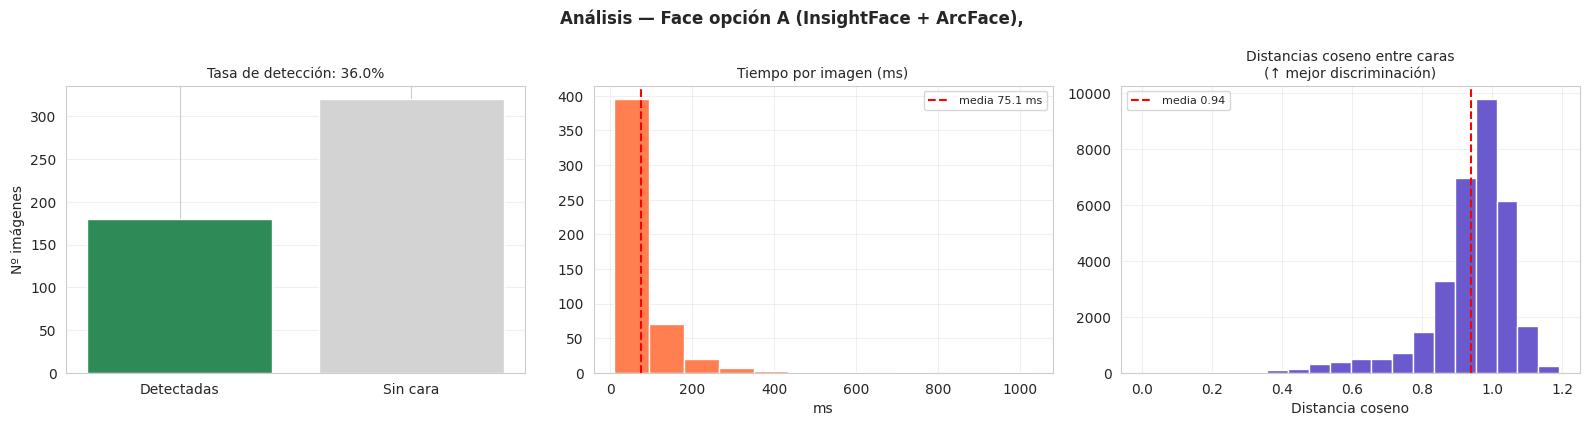

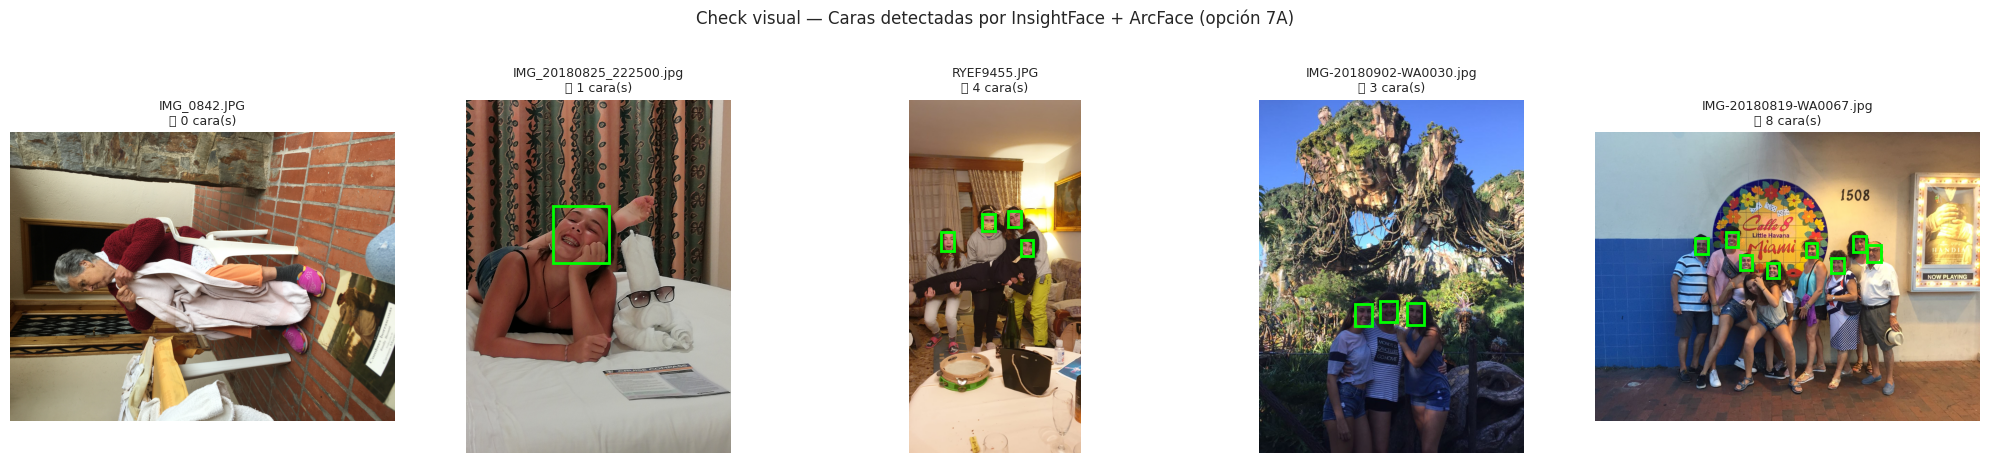

  ✅ Check visual guardado: /content/drive/MyDrive/TFM/Clustering/analysis_logs/Face Analysis/face_A_check_visual.png

📝 INTERPRETACIÓN:
   ⚠️  Detección media (36%): evalúa si compensa el coste computacional.
   ⏱️  Coste razonable (75 ms/img) para CPU.
   ✅ Los embeddings discriminan personas (d̄=0.94), típico de modelos ArcFace-like.
   💾 Resultados guardados en /content/drive/MyDrive/TFM/Clustering/analysis_logs/Face Analysis/_faceA.json


In [ ]:
# Usa face_pipeline, FACE_OK, FACE_DIM

# ── Detectar qué opción se ejecutó ─────────────────────────────────
if not FACE_OK or face_pipeline is None:
    analysis_option_7 = 'C'
    _face_class = 'Ninguno (Opción 7C)'
elif type(face_pipeline).__name__ == 'FacePipelineArcFace':
    analysis_option_7 = 'A'
    _face_class = 'InsightFace + ArcFace'
elif type(face_pipeline).__name__ == 'FacePipelineFaceNet':
    analysis_option_7 = 'B'
    _face_class = 'MediaPipe + FaceNet'
else:
    analysis_option_7 = '?'
    _face_class = type(face_pipeline).__name__ if face_pipeline else 'N/D'

print(f'🔬 Analizando pipeline facial — escena + face')
print(f' Face: {_face_class} ({analysis_option_7})')
print('─' * 70)

# ── Caso especial: sin pipeline (opción 7C) ────────────────────────
if analysis_option_7 == 'C':
    print('ℹ️  El clustering se basará únicamente en embeddings de escena.')
    print('   Implicaciones:')
    print('     • No se diferenciará a personas dentro de una misma escena.')
    print('     • Máxima velocidad de procesamiento.')
    print('     • Recomendado para bibliotecas de paisajes o <100 retratos.')

    analysis_logger.save('face', f'face{analysis_option_7}', {
        'face_class'       : 'None',
        'face_dim'         : int(FACE_DIM),
        'detection_rate'   : 0.0,
        'time_per_img_ms'  : 0.0,
        'emb_norm_mean'    : None,
        'emb_norm_cv'      : None,
        'conclusions'      : [
            'Pipeline facial desactivado.',
            'Recomendado solo si la colección tiene pocas personas.',
        ],
    })
else:
    # ── Micro-benchmark sobre muestra aleatoria ────────────────────
    # Elegimos hasta METRIC_MIN_SAMPLES archivos para calcular las métricas
    _pool_files = new_files if 'new_files' in globals() and new_files else []
    _sample_n = min(CONFIG['METRIC_MIN_SAMPLES'], len(_pool_files))
    if _sample_n < CONFIG['METRIC_MIN_SAMPLES']:
        print(f'⚠️  Muestra demasiado pequeña para benchmark facial '
              f'({_sample_n} < {CONFIG["METRIC_MIN_SAMPLES"]}). Omitido.')
    else:
        random.seed(50)
        _sample_paths = random.sample(_pool_files, _sample_n)

        # ── Fijar las imágenes del check visual ───────────────────
        _rng_vis = np.random.default_rng(seed=50)
        _vis_idx  = _rng_vis.choice(len(_pool_files), size=min(5, len(_pool_files)), replace=False)
        _vis_paths = [_pool_files[int(i)] for i in sorted(_vis_idx)]
        analysis_face_embs  = []
        analysis_facetimes = []
        _n_detected = 0
        _sample_paths_with_face = []

        for _p in _sample_paths:
            _img = load_image(_p)
            if _img is None:
                continue
            _t0 = time.perf_counter()
            _emb = face_pipeline.get_face_embedding(_img)
            _t1 = time.perf_counter()
            analysis_facetimes.append((_t1 - _t0) * 1000.0)
            if _emb is not None:
                _n_detected += 1
                analysis_face_embs.append(np.asarray(_emb, dtype=np.float32))
                _sample_paths_with_face.append(_p)

        analysis_detection_rate = _n_detected / _sample_n
        analysis_facetime_ms    = float(np.mean(analysis_facetimes)) if analysis_facetimes else float('nan')
        analysis_facetime_std   = float(np.std (analysis_facetimes)) if analysis_facetimes else float('nan')

        print(f'🔎 Muestra                       : {_sample_n} imágenes')
        print(f'👤 Caras detectadas              : {_n_detected} '
              f'({100*analysis_detection_rate:.1f}%)')
        print(f'⏱️ Tiempo por imagen             : {analysis_facetime_ms:6.1f} ms '
              f'(σ={analysis_facetime_std:.1f})')

        # ── Estadísticas de embeddings faciales ──────────────────────
        if len(analysis_face_embs) >= 2:
            analysis_face_arr   = np.stack(analysis_face_embs)
            analysis_face_norms = np.linalg.norm(analysis_face_arr, axis=1)
            analysis_face_norm_cv = float(analysis_face_norms.std() / (analysis_face_norms.mean() + 1e-9))
            print(f'📐 Norma embedding (media)       : {analysis_face_norms.mean():.3f} '
                  f'(CV={analysis_face_norm_cv:.3f})')

            _fn = normalize(analysis_face_arr, norm='l2')
            _sim_mat = _fn @ _fn.T
            _mask    = ~np.eye(len(_fn), dtype=bool)
            analysis_face_dist_mean = float(1.0 - _sim_mat[_mask].mean())
            analysis_face_dist_std  = float(_sim_mat[_mask].std())
            print(f'🔀 Distancia coseno inter-caras  : {analysis_face_dist_mean:.3f} '
                  f'(↑ mejor separación entre personas)')
        else:
            analysis_face_norms      = np.array([])
            analysis_face_norm_cv    = float('nan')
            analysis_face_dist_mean  = float('nan')
            analysis_face_dist_std   = float('nan')

        # ── Gráficos diagnósticos ────────────────────────────────────
        _fig, _axes = plt.subplots(1, 3, figsize=(16, 4.3))
        _fig.suptitle(
            f'Análisis — Face opción {analysis_option_7} ({_face_class}), ',
            fontsize=12, fontweight='bold',
        )

        # (a) Tasa de detección
        _axes[0].bar(['Detectadas', 'Sin cara'],
                     [_n_detected, _sample_n - _n_detected],
                     color=['seagreen', 'lightgray'])
        _axes[0].set_title(f'Tasa de detección: {100*analysis_detection_rate:.1f}%',
                           fontsize=10)
        _axes[0].set_ylabel('Nº imágenes'); _axes[0].grid(alpha=0.3, axis='y')

        # (b) Tiempo por imagen
        if analysis_facetimes:
            _axes[1].hist(analysis_facetimes, bins=12, color='coral', edgecolor='white')
            _axes[1].axvline(analysis_facetime_ms, color='red', linestyle='--',
                             label=f'media {analysis_facetime_ms:.1f} ms')
            _axes[1].set_title('Tiempo por imagen (ms)', fontsize=10)
            _axes[1].set_xlabel('ms'); _axes[1].legend(fontsize=8)
            _axes[1].grid(alpha=0.3)

        # (c) Distribución de distancias coseno entre caras detectadas
        if len(analysis_face_embs) >= 2:
            _dist_vals = 1.0 - _sim_mat[_mask]
            _axes[2].hist(_dist_vals, bins=20, color='slateblue', edgecolor='white')
            _axes[2].axvline(analysis_face_dist_mean, color='red', linestyle='--',
                             label=f'media {analysis_face_dist_mean:.2f}')
            _axes[2].set_title('Distancias coseno entre caras\n(↑ mejor discriminación)',
                               fontsize=10)
            _axes[2].set_xlabel('Distancia coseno'); _axes[2].legend(fontsize=8)
            _axes[2].grid(alpha=0.3)

        plt.tight_layout()
        _facial_plot_path = os.path.join(analysis_logger._section_folder('face'), f'face_{analysis_option_7}_diag.png')
        plt.savefig(_facial_plot_path, dpi=120, bbox_inches='tight')
        plt.show()

        # ── Check visual: imágenes con bounding boxes ────────────────
        import matplotlib.patches as _patches

        _fig_bb, _axes_bb = plt.subplots(1, len(_vis_paths), figsize=(4 * len(_vis_paths), 4.5))
        if len(_vis_paths) == 1:
            _axes_bb = [_axes_bb]

        _fig_bb.suptitle(
            f'Check visual — Caras detectadas por {_face_class} '
            f'(opción 7{analysis_option_7})',
            fontsize=12, y=1.02,
        )

        for _ax_bb, _vp in zip(_axes_bb, _vis_paths):
            _vimg = load_image(_vp)
            if _vimg is None:
                _ax_bb.text(0.5, 0.5, 'Error\nde carga',
                            ha='center', va='center',
                            transform=_ax_bb.transAxes)
                _ax_bb.axis('off')
                continue

            _ax_bb.imshow(_vimg)
            _vboxes = []

            # ── Extraer bounding boxes según el pipeline activo ──
            try:
                if hasattr(face_pipeline, 'get_face_boxes'):
                    _vboxes = face_pipeline.get_face_boxes(_vimg)
                elif hasattr(face_pipeline, 'recognizer') and face_pipeline.recognizer is not None:
                    _vimg_bgr = cv2.cvtColor(np.array(_vimg), cv2.COLOR_RGB2BGR)
                    _vfaces = face_pipeline.recognizer.get(_vimg_bgr)
                    for _vf in _vfaces:
                        x1, y1, x2, y2 = _vf.bbox[:4].astype(int)
                        if x2 - x1 > 0 and y2 - y1 > 0:
                            _vboxes.append((x1, y1, x2 - x1, y2 - y1))
                elif hasattr(face_pipeline, 'detect_faces'):
                    _vdets = face_pipeline.detect_faces(_vimg)
                    for _vd in _vdets:
                        if isinstance(_vd, dict) and 'box' in _vd:
                            _vboxes.append(tuple(_vd['box']))
                        elif isinstance(_vd, dict) and 'bbox' in _vd:
                            x1, y1, x2, y2 = _vd['bbox'][:4]
                            _vboxes.append((int(x1), int(y1),
                                            int(x2 - x1), int(y2 - y1)))
                        elif hasattr(_vd, 'bbox'):
                            x1, y1, x2, y2 = _vd.bbox[:4]
                            _vboxes.append((int(x1), int(y1),
                                            int(x2 - x1), int(y2 - y1)))
                else:
                    for _aname in ('detector', 'face_detector', 'mtcnn'):
                        _det = getattr(face_pipeline, _aname, None)
                        if _det is not None and hasattr(_det, 'detect_faces'):
                            for _vd in _det.detect_faces(_vimg):
                                if isinstance(_vd, dict) and 'box' in _vd:
                                    _vboxes.append(tuple(_vd['box']))
                            break
            except Exception as _e_bb:
                print(f'  ⚠️  Bbox fallida en {Path(_vp).name}: {_e_bb}')

            for (bx, by, bw, bh) in _vboxes:
                _rect = _patches.Rectangle(
                    (bx, by), bw, bh,
                    linewidth=2, edgecolor='lime', facecolor='none')
                _ax_bb.add_patch(_rect)

            # Si el pipeline no detectó cara en esta foto, el título lo indica
            _n_caras = len(_vboxes) if _vboxes else 0
            _ax_bb.set_title(
                f'{Path(_vp).name[:25]}\n'
                f'{"✅" if _n_caras > 0 else "❌"} {_n_caras} cara(s)',
                fontsize=9)
            _ax_bb.axis('off')

        plt.tight_layout()

        _bb_plot_path = os.path.join(
            analysis_logger._section_folder('face'),
            f'face_{analysis_option_7}_check_visual.png')
        _fig_bb.savefig(_bb_plot_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'  ✅ Check visual guardado: {_bb_plot_path}')

        # ── Conclusiones ────────────────────────────────────────────
        print('\n📝 INTERPRETACIÓN:')
        _conclusions_7 = []
        if analysis_detection_rate > 0.5:
            _conclusions_7.append(f'✅ Detección alta ({100*analysis_detection_rate:.0f}%): colección rica en retratos — el pipeline facial aportará valor al clustering.')
        elif analysis_detection_rate > 0.2:
            _conclusions_7.append(f'⚠️  Detección media ({100*analysis_detection_rate:.0f}%): evalúa si compensa el coste computacional.')
        else:
            _conclusions_7.append(f'ℹ️  Detección baja ({100*analysis_detection_rate:.0f}%): colección mayoritariamente no-retratos; podrías ejecutar 7C para ahorrar tiempo.')

        if analysis_facetime_ms > 200:
            _conclusions_7.append(f'⏱️  Coste elevado ({analysis_facetime_ms:.0f} ms/img). Para N>1000 imágenes considerar 7B o 7C.')
        elif analysis_facetime_ms > 0:
            _conclusions_7.append(f'⏱️  Coste razonable ({analysis_facetime_ms:.0f} ms/img) para CPU.')

        if not np.isnan(analysis_face_dist_mean):
            if analysis_face_dist_mean > 0.6:
                _conclusions_7.append(f'✅ Los embeddings discriminan personas (d̄={analysis_face_dist_mean:.2f}), típico de modelos ArcFace-like.')
            elif analysis_face_dist_mean > 0.3:
                _conclusions_7.append(f'⚠️  Discriminación moderada (d̄={analysis_face_dist_mean:.2f}): suficiente para colecciones pequeñas.')
            else:
                _conclusions_7.append(f'❌ Baja discriminación (d̄={analysis_face_dist_mean:.2f}): verificar normalización.')

        for _c in _conclusions_7:
            print(f'   {_c}')

        # ── Persistencia ─────────────────────────────────────────────
        analysis_logger.save('face', f'_face{analysis_option_7}', {
            'pipeline_class'     : _face_class,
            'face_dim'           : int(FACE_DIM),
            'sample_size'        : int(_sample_n),
            'detection_rate'     : float(analysis_detection_rate),
            'time_per_img_ms'    : float(analysis_facetime_ms),
            'time_per_img_std'   : float(analysis_facetime_std),
            'emb_norm_mean'      : float(analysis_face_norms.mean()) if len(analysis_face_norms) else None,
            'emb_norm_cv'        : float(analysis_face_norm_cv) if not np.isnan(analysis_face_norm_cv) else None,
            'inter_face_cosine'  : float(analysis_face_dist_mean) if not np.isnan(analysis_face_dist_mean) else None,
            'plot_path'          : _facial_plot_path,
            'conclusions'        : _conclusions_7,
        })

---
## Celda 8 — Extractor de escenas

> **Tres bloques: 8A, 8B o 8C.**
> Para definir las variables globales: `scene_model`, `EMBED_DIM`, `transform`.

| Bloque | Modelo | Dims | Velocidad CPU | Precisión |
|--------|--------|------|---------------|----------|
| **8A** | MobileNetV3-Large | 960 | ★★★★ | ★★★ |
| **8B** | EfficientNet-B0 | 1280 | ★★★ | ★★★★ |
| **8C** ✅ | CLIP ViT-B/32 | 512 | ★★ (GPU) | ★★★★★ |

### Objetivo
Convertir cada imagen en un vector denso (*embedding*) que codifique su contenido
semántico. Tres alternativas con distinto compromiso velocidad/calidad.

### Contexto
Las redes preentrenadas en ImageNet como MobileNetV3 y EfficientNet aprenden en sus capas finales una representación abstracta de la escena. Eliminando la capa de clasificación se obtiene un *feature vector* aprovechable para clustering. CLIP va más allá entrenando con pares imagen-texto, lo que produce un espacio semántico mucho más rico — útil para una biblioteca personal donde "boda", "playa" y "cumpleaños" son conceptos visualmente complejos.

La función `transforms()` de los pesos de torchvision incluye exactamente la normalización con la que se entrenó cada arquitectura (medias y desviaciones de ImageNet).

### Pros y contras de cada opción
- **8A — MobileNetV3-Large**: la más rápida en CPU, con cuantización dinámica int8. Embeddings compactos (960 dims). Limitación: capacidad expresiva menor que arquitecturas modernas; en colecciones muy variadas puede fundir conceptos similares.
- **8B — EfficientNet-B0**: equilibrio entre 8A y 8C (1280 dims). Algo más lenta y con mayor consumo de RAM, pero embeddings más expresivos. Buena opción intermedia.
- **8C — CLIP ViT-B/32**: embeddings semánticos muy potentes (512 dims). Pensada para GPU; en CPU es viable pero lenta. Es la opción seleccionada por defecto cuando hay GPU disponible, pues la calidad del clustering aguas abajo lo justifica.

### 8A — Modelo de escenas: MobileNetV3-Large con cuantización

Carga el modelo MobileNetV3-Large preentrenado en ImageNet. Se eliminan las capas de clasificación final para que la red devuelva embeddings de 960 dimensiones en lugar de probabilidades sobre 1000 clases.

Cuantización dinámica (`QUANTIZE_MODEL=True`): convierte los pesos de float32 a int8, reduciendo el tamaño del modelo y acelerando la inferencia en CPU. Solo se aplica en CPU porque las GPUs no se benefician de este tipo de cuantización.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 8A — MobileNetV3-Large con cuantización dinámica
# ════════════════════════════════════════════════════════════════════════════

print('📦 [8A] Cargando MobileNetV3-Large...')

# IMAGENET1K_V2 son los pesos más recientes y precisos disponibles en torchvision
# para esta arquitectura. Se entrenaron con técnicas de regularización modernas.
weights_8a  = MobileNet_V3_Large_Weights.IMAGENET1K_V2
scene_model = mobilenet_v3_large(weights=weights_8a)

# Extraemos la dimensión del embedding ANTES de modificar el clasificador.
# `classifier[0]` es la primera capa (Linear) cuyo `in_features` corresponde
# al tamaño del vector de características.
EMBED_DIM = scene_model.classifier[0].in_features

# Sustituimos el clasificador por la identidad. El modelo ahora devuelve el
# vector de características de 960 dims en lugar de 1000 logits sobre clases
# de ImageNet.
scene_model.classifier = torch.nn.Identity()
scene_model.eval()      # Modo evaluación: desactiva dropout y batchnorm dinámico
scene_model.to(DEVICE)

# Cuantización dinámica float32 a int8: las capas Linear se evalúan con enteros
# de 8 bits en lugar de floats. Acelera en CPU sin pérdida apreciable de
# precisión en tareas de extracción de features. Solo aplica en CPU porque las
# GPUs ya son eficientes en float.
if CONFIG['QUANTIZE_MODEL'] and DEVICE == 'cpu':
    scene_model = torch.quantization.quantize_dynamic(
        scene_model,
        {torch.nn.Linear},   # Solo cuantizamos capas lineales
        dtype=torch.qint8,
    )
    print('   Cuantización int8 aplicada (capas Linear)')

# Cada modelo preentrenado está entrenado con un preprocesamiento
# (resize, crop, mean/std de normalización).
transform = weights_8a.transforms()

analysis_option_6 = ['A', 'MobileNetV3-Large']
print(f'✅ [8A] MobileNetV3-Large listo en {DEVICE.upper()} | Embedding: {EMBED_DIM} dims')
_pipeline_options['scene_extractor'] = '8A'

### 8B — EfficientNet-B0 (mayor precisión, algo más lento)

Mejor equilibrio precisión/eficiencia que MobileNetV3. Embedding de 1280 dims que hace que sea ligeramente más lento (más memoria).

Cuantización dinámica (`QUANTIZE_MODEL=True`): se aplica `torch.quantization.quantize_dynamic` sobre las capas `Linear` cuando se ejecuta en CPU. En EfficientNet-B0 el grueso del cómputo está en convoluciones (que `quantize_dynamic` no soporta), por lo que la ganancia es más modesta que en MobileNetV3, pero sigue siendo segura y reduce el coste de las capas finales sin pérdida apreciable de precisión.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 8B — EfficientNet-B0 con cuantización dinámica
# ════════════════════════════════════════════════════════════════════════════


print('📦 [8B] Cargando EfficientNet-B0...')

# Intentamos primero la implementación oficial de torchvision
# Si la API cambia o falta, hacemos fallback al paquete dedicado
# `efficientnet_pytorch`.
try:
    weights_8b  = EfficientNet_B0_Weights.IMAGENET1K_V1
    scene_model = efficientnet_b0(weights=weights_8b)

    # En torchvision, classifier es Sequential: [Dropout, Linear].
    # La capa Linear es la [1] y su in_features da la dimensión del embedding.
    EMBED_DIM = scene_model.classifier[1].in_features

    scene_model.classifier = torch.nn.Identity()
    use_torchvision_transforms = True

    analysis_option_6 = ['B', 'EfficientNet_B0']
    print('   Cargado desde torchvision')

except (ImportError, AttributeError):
    # Fallback: paquete dedicado efficientnet_pytorch
    from efficientnet_pytorch import EfficientNet
    scene_model = EfficientNet.from_pretrained('efficientnet-b0')

    # En este paquete la capa final se llama _fc
    EMBED_DIM = scene_model._fc.in_features
    scene_model._fc = torch.nn.Identity()
    use_torchvision_transforms = False

    analysis_option_6 = ['B', 'EfficientNet_pytorch']
    print('   Cargado desde efficientnet_pytorch (fallback)')

scene_model.eval()
scene_model.to(DEVICE)

# Cuantización dinámica float32 a int8 sobre las capas Linear.
# Solo aplica en CPU porque las GPUs ya son eficientes en float.
if CONFIG['QUANTIZE_MODEL'] and DEVICE == 'cpu':
    scene_model = torch.quantization.quantize_dynamic(
        scene_model,
        {torch.nn.Linear},   # Solo cuantizamos capas lineales
        dtype=torch.qint8,
    )
    print('   Cuantización int8 aplicada (capas Linear)')

if use_torchvision_transforms:
    transform = weights_8b.transforms()
else:
    transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],   # Medias de ImageNet
                    std =[0.229, 0.224, 0.225]),  # Desviaciones de ImageNet
    ])

print(f'✅ [8B] EfficientNet-B0 listo en {DEVICE.upper()} | Embedding: {EMBED_DIM} dims')

_pipeline_options['scene_extractor'] = '8B'

### 8C — CLIP ViT-B/32 (máxima comprensión semántica, GPU recomendada)

Modelo multimodal entrenado con 400 M de pares imagen-texto. Captura conceptos abstractos ("playa", "boda") sin haber sido entrenado explícitamente para esas
categorías. El modelo es grande, lento en CPU. Recomendado con GPU.

A diferencia de las CNN tradicionales (como MobileNet o EfficientNet), el ViT no aplica convoluciones. En su lugar, divide la imagen en parches y los procesa como si fueran palabras en una frase usando mecanismos de auto-atención (self-attention).

Cuantización dinámica (`QUANTIZE_MODEL=True`): el ViT está formado casi íntegramente por capas `Linear` (proyecciones Q/K/V de atención, FFN, proyección final), por lo que `torch.quantization.quantize_dynamic` ofrece aquí la mayor ganancia relativa de los tres extractores cuando se ejecuta en CPU. Solo se aplica en CPU; en GPU no aporta beneficio y CLIP ya trabaja en float16 nativamente.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 8C — CLIP ViT-B/32
# ════════════════════════════════════════════════════════════════════════════

print('📦 [8C] Cargando CLIP ViT-B/32...')

# CLIP no se distribuye por PyPI; se instala on-demand desde el repo oficial de
# OpenAI.
try:
    import clip
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'git+https://github.com/openai/CLIP.git',
    ])
    import clip

# CLIP devuelve dos componentes: el modelo (con encoders de imagen y texto)
# y un PREPROCESADOR ya construido con la normalización exacta del entrenamiento.
# Usamos solo el encoder visual.
_clip_model, _clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
_clip_model.eval()

# Para ViT-B/32 esto es 512. Lo extraemos del atributo en lugar de hardcodearlo
# para que el código siga funcionando si se cambia de variante (B/16, L/14...).
EMBED_DIM = _clip_model.visual.output_dim

# Cuantización dinámica float32 a int8 sobre las capas Linear.
# El Vision Transformer está formado casi íntegramente por capas Linear
# este es el modelo donde más gana la cuantización
# Solo aplica en CPU: en GPU CLIP ya trabaja en float16 nativamente.
if CONFIG['QUANTIZE_MODEL'] and DEVICE == 'cpu':
    # Aseguramos float32 antes de cuantizar (clip.load deja float32 en CPU,
    # pero esto blinda el código frente a rutas alternativas de carga).
    _clip_model = _clip_model.float()
    _clip_model = torch.quantization.quantize_dynamic(
        _clip_model,
        {torch.nn.Linear},   # Solo cuantizamos capas lineales (la mayoría del ViT)
        dtype=torch.qint8,
    )
    print('   Cuantización aplicada (capas Linear)')


class CLIPSceneModel(torch.nn.Module):
    """
    Adapta el encoder visual de CLIP a  aplicar forward(x) y embeddings
    que espera la función extract_embeddings_for_files.

    CLIP devuelve float16 (incompatible con sklearn). Convertimos a float32.
    """
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model

    def forward(self, x):
        # Desabilitamos que calcula gradientes porque queremos hacer inferencia
        with torch.no_grad():
            features = self.clip_model.encode_image(x).float()
        return features


scene_model = CLIPSceneModel(_clip_model)
transform = _clip_preprocess

analysis_option_6 = ['C', 'CLIP ViT-B/32']
print(f'✅ [8C] CLIP ViT-B/32 listo en {DEVICE.upper()} | Embedding: {EMBED_DIM} dims')
if DEVICE == 'cpu':
    print('⚠️  CLIP en CPU puede ser lento. Considera la opción 8A si la velocidad es prioritaria.')

_pipeline_options['scene_extractor'] = '8C'

📦 [8C] Cargando CLIP ViT-B/32...


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 102MiB/s]


   Cuantización aplicada (capas Linear)
✅ [8C] CLIP ViT-B/32 listo en CPU | Embedding: 512 dims
⚠️  CLIP en CPU puede ser lento. Considera la opción 8A si la velocidad es prioritaria.


---
## Celda 9 — Extracción de embeddings

### Objetivo
Producir, para cada archivo nuevo, un vector único que combine la información de escena y
la facial (cuando hay cara). Este vector es la entrada al pipeline de clustering.

### Contexto
La función `extract_embeddings_for_files` ejecuta tres fases:

1. **Embeddings de escena**: en lotes (`DataLoader`) por eficiencia. Imágenes corruptas se
   excluyen sin romper el orden.
2. **Embeddings faciales**: si el pipeline facial está activo (8A/8B), recorre cada imagen
   válida; si no, deja un vector de ceros.
3. **Fusión**: ambos embeddings se L2-normalizan y se concatenan ponderadamente
   (`FACE_WEIGHT`). Las imágenes sin cara conservan solo la parte de escena al peso 1.0.

### Información extra
- El vector resultante puede ser muy ancho (1280 + 512 = 1792 dim para EfficientNet+ArcFace). De ahí la importancia de la reducción dimensional posterior.
- L2-normalizar antes de concatenar es crucial: los embeddings de escena y los faciales pueden tener escalas de magnitud distintas.

In [ ]:
import matplotlib.patches as patches

# ═══════════════════════════════════════════════════════════════════════════════
# Adaptador de bounding boxes para distintos pipelines faciales
# ═══════════════════════════════════════════════════════════════════════════════

def get_face_boxes(img):
    """
    Devuelve las bounding boxes de las caras detectadas en una imagen.
    Compatible con distintos extractores faciales (MediaPipe, MTCNN, InsightFace).
    """
    # Si la detección facial está desactivada o no hay pipeline cargado, devuelve lista vacía
    if not FACE_OK or face_pipeline is None:
        return []

    try:
        # ── Opción 1: El pipeline ya tiene un método propio get_face_boxes ──
        if hasattr(face_pipeline, 'get_face_boxes'):
            return face_pipeline.get_face_boxes(img)

        # ── Opción 2: El pipeline tiene detect_faces (MTCNN o InsightFace) ──
        if hasattr(face_pipeline, 'detect_faces'):
            detections = face_pipeline.detect_faces(img)
            boxes = []  # Lista para acumular las cajas en formato (x, y, w, h)

            for d in detections:
                if isinstance(d, dict) and 'box' in d:
                    # Formato MTCNN: devuelve dict con clave 'box'. Formato (x, y, w, h)
                    boxes.append(tuple(d['box']))

                elif isinstance(d, dict) and 'bbox' in d:
                    # Formato InsightFace: devuelve dict con clave 'bbox'. Formato (x1, y1, x2, y2)
                    x1, y1, x2, y2 = d['bbox'][:4]
                    # Convertimos a (x, y, w, h)
                    boxes.append((int(x1), int(y1), int(x2-x1), int(y2-y1)))

                elif hasattr(d, 'bbox'):
                    # Formato InsightFace (objeto): el atributo bbox es (x1, y1, x2, y2)
                    x1, y1, x2, y2 = d.bbox[:4]
                    # Convertimos a (x, y, w, h)
                    boxes.append((int(x1), int(y1), int(x2-x1), int(y2-y1)))

            return boxes  # Devuelve todas las cajas encontradas en esta imagen

        # ── Opción 3: El detector está anidado dentro del pipeline ──
        # Algunos wrappers guardan el detector real en un atributo interno
        for attr_name in ('detector', 'face_detector', 'mtcnn'):
            det = getattr(face_pipeline, attr_name, None)  # Busca el atributo por nombre
            if det is not None and hasattr(det, 'detect_faces'):
                detections = det.detect_faces(img)  # Llama al detector anidado
                boxes = []
                for d in detections:
                    if isinstance(d, dict) and 'box' in d:
                        boxes.append(tuple(d['box']))  # Solo maneja formato MTCNN aquí
                return boxes

        # ── Opción 4: InsightFace — accede a recognizer.get() directamente ──
        if hasattr(face_pipeline, 'recognizer') and face_pipeline.recognizer is not None:
            try:
                img_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
                faces = face_pipeline.recognizer.get(img_bgr)
                boxes = []
                for face in faces:
                    x1, y1, x2, y2 = face.bbox[:4].astype(int)
                    w_box = x2 - x1
                    h_box = y2 - y1
                    if w_box > 0 and h_box > 0:
                        boxes.append((x1, y1, w_box, h_box))  # formato (x, y, w, h)
                return boxes
            except Exception as e:
                print(f'  ⚠️  InsightFace bbox fallida: {e}')
                return []

    except Exception as e:
        print(f'  ⚠️  No se pudieron extraer bounding boxes: {e}')
        return []

    return []


# ═══════════════════════════════════════════════════════════════════════════════
# Extracción y fusión de embeddings de escena + faciales
# ═══════════════════════════════════════════════════════════════════════════════

def extract_embeddings_for_files(file_list: list):
    """
    Extrae embeddings de escena y faciales para todos los archivos de file_list.

    Devuelve:
        fused                : ndarray (N, EMBED_DIM + FACE_DIM) embeddings fusionados
        valid_files          : lista de archivos procesados correctamente
        has_face             : array booleano, True si se detectó cara
        failed               : lista de archivos que no pudieron cargarse
        face_boxes_per_file  : dict {idx_en_valid_files: [(x,y,w,h), ...]}
    """
    # Si la lista esta vacía devuelve la estructura vacía
    if not file_list:
        return np.empty((0, EMBED_DIM + FACE_DIM)), [], np.empty(0, dtype=bool), [], {}


    # ════════════════════════════════════════════════════════════════════════
    # FASE 1: Embeddings de ESCENA mediante MobileNetV3 + DataLoader
    # ════════════════════════════════════════════════════════════════════════

    # Crea el Dataset leyendo las imagenes
    dataset = PhotoDataset(file_list, transform)

    # Crea el DataLoader que agrupa imágenes en batches y las preprocesa en paralelo
    loader  = DataLoader(
        dataset,
        batch_size=CONFIG['BATCH_SIZE'],    # Número de imágenes procesadas a la vez
        num_workers=CONFIG['NUM_WORKERS'],  # Procesos paralelos de carga (CPU multi-núcleo)
        shuffle=False,                       # Mantiene el orden original para trazar índices
        pin_memory=(DEVICE == 'cuda'),       # Optimización de transferencia RAM y GPU si hay CUDA
    )

    # Reserva espacio para todos los embeddings de escena (uno por archivo)
    raw_scene  = np.zeros((len(file_list), EMBED_DIM), dtype=np.float32)
    # Máscara booleana: True si el archivo se cargó y procesó correctamente
    valid_mask = np.zeros(len(file_list), dtype=bool)

    scene_model.eval()  # Desactiva dropout/batchnorm para estar en modo inferencia

    with torch.no_grad():  # Desactiva el cálculo de gradientes para ahorrar memoria y acelerar procesamiento
        for tensors, indices, ok_flags in tqdm(loader, desc='  Embeddings de escena'):
            # tensors   : batch de imágenes como tensores normalizados (B, C, H, W)
            # indices   : posición original de cada imagen en file_list
            # ok_flags  : 1 si la imagen se cargó bien, 0 si hubo error

            # Pasa el batch por MobileNetV3 y obtiene embeddings de escena
            feats = scene_model(tensors.to(DEVICE)).cpu().numpy()

            # Si el batch tiene una sola imagen, reshape para que siempre sea 2D
            if feats.ndim == 1:
                feats = feats.reshape(1, -1)

            # Guarda cada embedding en su posición original dentro de raw_scene
            for i, (idx, ok) in enumerate(zip(indices.tolist(), ok_flags.tolist())):
                if ok:  # Solo guarda si la imagen se cargó correctamente
                    raw_scene[idx]  = feats[i]   # Embedding en su posición global
                    valid_mask[idx] = True         # Marca como válida

    # Índices de los archivos que SÍ se procesaron correctamente
    valid_idx = np.where(valid_mask)[0]
    # Lista de rutas de archivos válidos (en el mismo orden que sus embeddings)
    valid_files = [file_list[i] for i in valid_idx]
    # Solo los embeddings de archivos válidos (descarta los que fallaron)
    scene_embs  = raw_scene[valid_idx]
    # Lista de archivos que NO pudieron cargarse
    failed = [file_list[i] for i in np.where(~valid_mask)[0]]


    # ════════════════════════════════════════════════════════════════════════
    # FASE 2: Embeddings FACIALES mediante el pipeline facial (ArcFace/MTCNN/MediaPipe)
    # ════════════════════════════════════════════════════════════════════════

    # Reserva espacio para embeddings faciales
    face_embs = np.zeros((len(valid_files), FACE_DIM), dtype=np.float32)
    # Máscara booleana: True si el archivo se cargó y procesó correctamente
    has_face  = np.zeros(len(valid_files), dtype=bool)
    # Diccionario para guardar las bounding boxes
    face_boxes_per_file = {}

    # Solo ejecuta si el pipeline facial está disponible y cargado
    if FACE_OK and face_pipeline is not None:
        for i, path in enumerate(tqdm(valid_files, desc='  Embeddings faciales')):
            img = load_image(path)   # Carga la imagen en formato numpy RGB
            if img is None:
                continue  # Si no se puede cargar, salta a la siguiente

            # Pide al pipeline facial el embedding de la cara más prominente
            # Devuelve un vector numpy o None si no hay cara detectada
            emb = face_pipeline.get_face_embedding(img)

            if emb is not None:  # Si se detectó una cara
                # Crea un vector de ceros del tamaño estándar FACE_DIM
                emb_padded = np.zeros(FACE_DIM, dtype=np.float32)
                # Copia el embedding real (puede ser más corto que FACE_DIM)
                emb_len = min(len(emb), FACE_DIM)
                emb_padded[:emb_len] = emb[:emb_len]  # Rellena con el embedding real
                face_embs[i] = emb_padded  # Guarda el embedding facial alineado
                has_face[i]  = True         # Marca que esta imagen tiene cara

                # Obtiene las bounding boxes para poder dibujarlas luego
                boxes = get_face_boxes(img)
                if boxes:
                    face_boxes_per_file[i] = boxes  # Guarda solo si hay cajas reales

        # Muestra resumen de cuántas imágenes tuvieron cara detectada
        n_faces = has_face.sum()
        print(f'  👤 Imágenes con al menos una cara detectada: '
              f'{n_faces} ({100*n_faces/max(1,len(valid_files)):.1f}%)')


    # ════════════════════════════════════════════════════════════════════════
    # FASE 3: NORMALIZACIÓN y FUSIÓN ponderada escena + facial
    # ════════════════════════════════════════════════════════════════════════

    # Peso del componente facial en la fusión (0.0 = solo escena, 1.0 = solo cara)
    # Si FACE_OK=False, el peso facial es 0 → solo se usa escena
    w = CONFIG['FACE_WEIGHT'] if FACE_OK else 0.0

    # ── NORMALIZACIÓN ──
    # Normaliza cada embedding de escena a norma L2 = 1
    s_norm = normalize(scene_embs, norm='l2')
    # Normaliza cada embedding facial a norma L2 = 1
    f_norm = normalize(face_embs,  norm='l2')

    # ── PONDERACIÓN ──
    s_part = s_norm.copy()  # Copia del embedding de escena normalizado

    # Para imágenes CON cara: reduce el peso de escena a (1 - w)
    # Así la suma de pesos escena + cara = (1-w) + w = 1
    s_part[has_face] = s_norm[has_face] * (1 - w)

    # Aplica el peso facial a todos los embeddings faciales
    f_part = f_norm * w

    # Para imágenes sin cara el bloque facial queda a ceros
    f_part[~has_face] = 0.0

    # ── concatenación (EMBED_DIM + FACE_DIM) ──
    fused = np.concatenate([s_part, f_part], axis=1)

    # Devuelve los 5 productos que necesitan las celdas posteriores
    return fused, valid_files, has_face, failed, face_boxes_per_file


# ═══════════════════════════════════════════════════════════════════════════════
# Visualización de caras detectadas con sus bounding boxes
# ═══════════════════════════════════════════════════════════════════════════════

def visualize_face_detections(valid_files, has_face, face_boxes_per_file, n_samples=5):
    """
    Muestra n_samples imágenes con los recuadros de las caras detectadas.
    """
    # Si la detección facial está desactivada, avisa y sale
    if not FACE_OK:
        print('⚠️  Detección facial desactivada (FACE_OK=False). Nada que visualizar.')
        return

    # Filtra solo los índices de imágenes donde se detectó al menos una cara
    idx_with_face = [i for i in range(len(valid_files)) if has_face[i]]

    # Si no hubo ninguna cara en todo el dataset, avisa y sale
    if not idx_with_face:
        print('⚠️  No se detectó ninguna cara en el conjunto procesado.')
        return

    # Fija la semilla aleatoria para que la selección sea reproducible
    random.seed(CONFIG.get('RANDOM_SEED', 42))
    # Selecciona aleatoriamente hasta n_samples índices de imágenes con cara
    sample_idx = random.sample(idx_with_face, min(n_samples, len(idx_with_face)))

    n = len(sample_idx)  # Número real de imágenes a mostrar
    # Crea una fila de subplots, uno por imagen seleccionada
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4.5))
    if n == 1:
        axes = [axes]  # plt.subplots devuelve un objeto simple si n=1, lo envolvemos en lista

    # Título general del conjunto de imágenes diagnósticas
    fig.suptitle(
        f'Diagnóstico: caras detectadas por el pipeline facial '
        f'({n} de {len(idx_with_face)} imágenes con cara)',
        fontsize=12, y=1.02
    )

    for ax, idx in zip(axes, sample_idx):
        path  = valid_files[idx]               # Ruta del archivo
        img   = load_image(path)               # Carga la imagen en numpy RGB
        boxes = face_boxes_per_file.get(idx, [])  # Recupera sus bounding boxes (o lista vacía)

        if img is None:
            # Si la imagen no se puede cargar, muestra un mensaje de error en el subplot
            ax.text(0.5, 0.5, 'Error\nde carga', ha='center', va='center',
                    transform=ax.transAxes)
            ax.axis('off')
            continue

        ax.imshow(img)  # Muestra la imagen en el subplot

        # Dibuja un rectángulo verde lima por cada cara detectada
        for (x, y, w_box, h_box) in boxes:
            rect = patches.Rectangle(
                (x, y),          # Esquina superior izquierda de la caja
                w_box, h_box,    # Ancho y alto de la caja
                linewidth=2,
                edgecolor='lime',    # Verde lima para visibilidad
                facecolor='none'     # Sin relleno → solo el borde
            )
            ax.add_patch(rect)  # Añade el rectángulo al subplot

        # Número de caras detectadas en esta imagen (o '?' si no hay info de boxes)
        n_caras_img = len(boxes) if boxes else '?'
        ax.set_title(
            f'{Path(path).name[:25]}\n{n_caras_img} cara(s) detectada(s)',
            fontsize=9
        )
        ax.axis('off')  # Oculta los ejes (no son útiles para imágenes)

    plt.tight_layout()  # Ajusta el espaciado entre subplots automáticamente
    plt.show()          # Renderiza y muestra la figura

    # ── Resumen estadístico interpretativo ──
    # Cuenta el total de bounding boxes en todas las imágenes con cara
    total_boxes = sum(len(b) for b in face_boxes_per_file.values())
    # Número de imágenes que tienen al menos una bounding box registrada
    n_imgs_face = len(face_boxes_per_file)

    print('\n' + '─'*70)
    print('📊 INTERPRETACIÓN DEL CONTEO DE CARAS')
    print('─'*70)
    print(f'  • Imágenes con ≥1 cara detectada : {has_face.sum()}')
    if face_boxes_per_file:
        print(f'  • Total de bounding boxes        : {total_boxes} '
              f'(en {n_imgs_face} imágenes)')
        # Promedio de caras por imagen (con protección contra división por cero)
        print(f'  • Promedio caras por imagen      : '
              f'{total_boxes/max(1,n_imgs_face):.2f}')
    print(f'  • Embeddings faciales generados  : {has_face.sum()} '
          f'(uno por imagen)')
    print('─'*70)
    print('─'*70)

In [ ]:
# ── Extracción ──────────────────────────────────────────────────────
print(f'Extrayendo embeddings de {len(new_files)} archivos nuevos...')

from collections import Counter
file_type_counts = Counter(Path(f).suffix.lower() for f in new_files)

new_embeddings_raw, new_valid_files, new_has_face, new_failed, new_face_boxes = \
    extract_embeddings_for_files(new_files)

print(f'\n✅ Embeddings extraídos : {len(new_valid_files)}')
print(f'⚠️  Fallidos            : {len(new_failed)}')
if len(new_valid_files) > 0:
    print(f'   Dimensión vector    : {new_embeddings_raw.shape[1]}')

print_error_statistics(file_type_counts)

# ── Guardar visual ──────────────────────────────────────────────────
if len(new_valid_files) > 0:
    try:
        option_str = get_option_string()
        output_dir = ensure_analysis_dir('celda_9_diagnostico_visual')
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'diagnostico_embeddings_{option_str}_{timestamp}.png'
        filepath = os.path.join(output_dir, filename)

        if 'fig' in locals():
            fig.savefig(filepath, dpi=150, bbox_inches='tight')
            print(f'✓ Diagnóstico guardado: {filepath}')
    except Exception as e:
        print(f'Nota: {e}')

Extrayendo embeddings de 1874 archivos nuevos...


  Embeddings de escena:   0%|          | 0/59 [00:00<?, ?it/s]

  Embeddings faciales:   0%|          | 0/1873 [00:00<?, ?it/s]

  👤 Imágenes con al menos una cara detectada: 715 (38.2%)

✅ Embeddings extraídos : 1873
⚠️  Fallidos            : 1
   Dimensión vector    : 1024

════════════════════════════════════════════════════════════════════════════════
⚠️  REPORTE DE ERRORES POR TIPO DE ARCHIVO
════════════════════════════════════════════════════════════════════════════════

Tipo          Errores      Total     % Tipo   % Global
────────────────────────────────────────────────────────────────────────────────
.jpg                1      1,291      0.08%      0.05%
────────────────────────────────────────────────────────────────────────────────
TOTAL               1      1,874      0.05%    100.00%
════════════════════════════════════════════════════════════════════════════════

Nota: name 'get_option_string' is not defined


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# RENORMALIZACIÓN L2 DE EMBEDDINGS FUSIONADOS
# ═══════════════════════════════════════════════════════════════════════════
# Tras la fusión escena+facial, el vector concatenado pierde la norma unitaria
# esto afecta a la calidad del clustering porque dos vectores similares pueden
# quedar en direcciones muy lejanas. Por ejemplo, si una fotografia es de una
# playa y otra fotografía es de la misma playa pero con una persona tendran
# embedings en direcciones muy diferentes.
# ═══════════════════════════════════════════════════════════════════════════

def renormalize_l2(embeddings: np.ndarray, label: str = '') -> np.ndarray:
    """
    Renormaliza cada fila a norma L2 = 1, evitando división por cero.
    Imprime estadísticas antes/después para verificar el efecto.
    """
    if embeddings.size == 0:
        return embeddings

    # Estadísticas ANTES
    norms_before = np.linalg.norm(embeddings, axis=1)
    mean_b, std_b = norms_before.mean(), norms_before.std()
    cv_b = std_b / max(mean_b, 1e-12)
    print(f'  📏 Antes  {label:<25}: μ={mean_b:.3f}  σ={std_b:.3f}  CV={cv_b:.3f}')

    # Renormalización segura: filas con norma aprox 0 se dejan como están
    embeddings_norm = normalize(embeddings, norm='l2', axis=1)

    # Estadísticas DESPUÉS
    norms_after = np.linalg.norm(embeddings_norm, axis=1)
    mean_a, std_a = norms_after.mean(), norms_after.std()
    cv_a = std_a / max(mean_a, 1e-12)
    print(f'  ✅ Después {label:<25}: μ={mean_a:.3f}  σ={std_a:.3f}  CV={cv_a:.3f}')

    return embeddings_norm

# ── Aplicar renormalización ─────────────────────────────────────────────
print('🔧 Renormalizando embeddings fusionados (L2)...')
new_embeddings_raw = renormalize_l2(new_embeddings_raw, 'embeddings fusionados')

🔧 Renormalizando embeddings fusionados (L2)...
  📏 Antes  embeddings fusionados    : μ=0.894  σ=0.135  CV=0.152
  ✅ Después embeddings fusionados    : μ=1.000  σ=0.000  CV=0.000


---
## Análisis de los embeddings del extractor de escena + Pipeline Facial

### Objetivo
Medir la calidad de los embeddings producidos, antes de pasar a reducción y clustering mediante:

- **Dimensionalidad (PCA rank 95%)** — cuántas componentes principales hacen falta para explicar el 95% de la varianza. Un número bajo indica redundancia; un número muy alto puede indicar ruido.
- **Isotropía (anisotropy score)** — cociente entre el mayor y el menor valor singular del  embedding normalizado. Embeddings muy anisótropos (valores altos) concentran información en pocas direcciones y son malos para clustering por densidad como HDBSCAN.
- **Distribución de normas L2** — si antes de normalizar los vectores tienen normas muy  dispares, algunas imágenes dominan distancias y sesgan el clustering.
- **Separabilidad facial vs no-facial** —  distancia coseno media entre el grupo "con cara" y "sin cara". Un extractor bueno debe  diferenciar retratos de paisajes.
- **Tiempo de inferencia por imagen** — reportado por el propio extractor.

### Información extra
- Los valores umbral utilizados ("anisotropía < 15 = excelente") provienen de el análisis del estado del arte. No son universales pero nos sirven como  guía orientativa.

🔬 Analizando extractor de escena
    Scene: CLIP ViT-B/32 (C) | Face: InsightFace + ArcFace (A)
──────────────────────────────────────────────────────────────────────
⏱️ Tiempo inferencia por imagen : 208.06 ms
📐 Norma L2 media               :   0.936 (σ=0.082, CV=0.087)
📊 Rango PCA 95% varianza       : 259 / 512 dims (50.6%)
📊 Anisotropía escena (σ₁/σ₅₀)  : 4.83  (↓ mejor para densidad)
📊 Anisotropía vector final     : 4.63  (sobre 1024 dims fusionadas)
📊 Rango PCA 90% varianza (fusionado): 301 / 1024 dims (29.4%)
👤 Separabilidad cara/no-cara   : 0.0698 (dist. coseno, ↑ mejor)


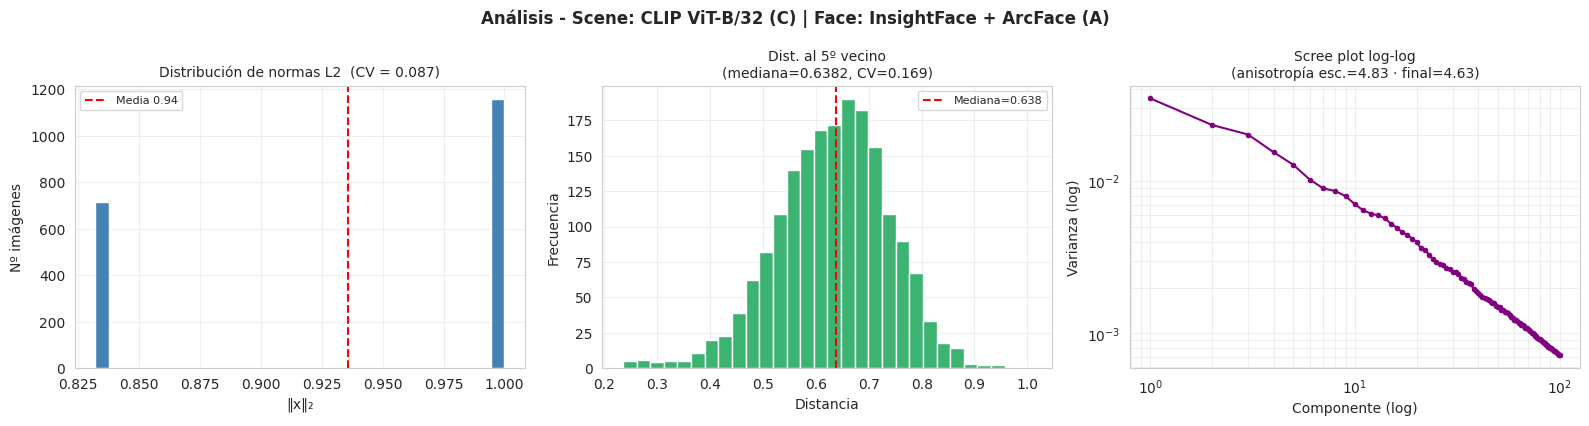


📝 INTERPRETACIÓN:
   ✅ Isotropía excelente — apto para HDBSCAN/UMAP.
   ✅ Anisotropía estable tras fusión cara+escena (4.6).
   ✅ Información bien distribuida (rank95 alto).
   ✅ Normas L2 homogéneas: no hace falta re-escalar.
   💾 Resultados guardados en /content/drive/MyDrive/TFM/Clustering/analysis_logs/Scene Analysis/sceneC_faceA.json


In [ ]:
# Análisis INDEPENDIENTE del pipeline principal
# Usa new_embeddings_raw, new_has_face, new_valid_files y EMBED_DIM

# ── Detectar qué opción se ha ejecutado ────────────────────────────
print(f'🔬 Analizando extractor de escena')
print(f'    Scene: {analysis_option_6[1]} ({analysis_option_6[0]}) | '
      f'Face: {_face_class} ({analysis_option_7})')
print('─' * 70)

# ── Tiempo de inferencia por imagen ────────────────────────────────
if len(new_valid_files) >= 16:
    _sample_files = new_valid_files[:16]
    _batch = []
    for _p in _sample_files:
        _img = load_image(_p)
        if _img is not None:
            _batch.append(transform(_img))
    if _batch:
        _batch_t = torch.stack(_batch).to(DEVICE)
        with torch.no_grad():
            _ = scene_model(_batch_t)
        _t0 = time.perf_counter()
        with torch.no_grad():
            _ = scene_model(_batch_t)
        _t1 = time.perf_counter()
        analysistime_per_img_ms = (_t1 - _t0) * 1000.0 / len(_batch)
    else:
        analysistime_per_img_ms = float('nan')
else:
    analysistime_per_img_ms = float('nan')
print(f'⏱️ Tiempo inferencia por imagen : {analysistime_per_img_ms:6.2f} ms')

# ── Solo la parte de escena del vector fusionado ───────────────────
analysis_scene_only = new_embeddings_raw[:, :EMBED_DIM].astype(np.float32)
_n_samples = analysis_scene_only.shape[0]
if _n_samples < CONFIG['METRIC_MIN_SAMPLES']:
    print(f'⚠️  Muestra reducida ({_n_samples} < {CONFIG["METRIC_MIN_SAMPLES"]}): '
          'las métricas pueden no ser representativas.')

# ── Distribución de normas L2 ──────────────────────────────────────
analysis_norms = np.linalg.norm(analysis_scene_only, axis=1)
analysis_norm_cv = float(analysis_norms.std() / (analysis_norms.mean() + 1e-9))
print(f'📐 Norma L2 media               : {analysis_norms.mean():7.3f} '
      f'(σ={analysis_norms.std():.3f}, CV={analysis_norm_cv:.3f})')

# ── Dimensionalidad efectiva vía PCA (solo escena) ─────────────────
_max_pca = min(_n_samples - 1, EMBED_DIM)
if _max_pca >= 2:
    _pca_diag = PCA(n_components=_max_pca, random_state=SEED)
    _pca_diag.fit(analysis_scene_only)
    _cum = np.cumsum(_pca_diag.explained_variance_ratio_)
    analysis_rank_95 = int(np.argmax(_cum >= 0.95)) + 1 if (_cum >= 0.95).any() else _max_pca
    _svals = np.sqrt(_pca_diag.explained_variance_[:50] + 1e-12)
    analysis_anisotropy = float(_svals[0] / (_svals[-1] + 1e-9))
else:
    analysis_rank_95 = -1
    analysis_anisotropy = float('nan')
    _cum = np.array([])
print(f'📊 Rango PCA 95% varianza       : {analysis_rank_95} / {EMBED_DIM} dims '
      f'({100*analysis_rank_95/EMBED_DIM:.1f}%)')
print(f'📊 Anisotropía escena (σ₁/σ₅₀)  : {analysis_anisotropy:.2f}  '
      '(↓ mejor para densidad)')

# ── Anisotropía del VECTOR FINAL (escena + cara fusionados) ────────
# El vector que realmente entra al clustering es new_embeddings_raw
# (EMBED_DIM + FACE_DIM). El bloque facial puede estar a cero en
# imágenes sin cara, lo que infla artificialmente la anisotropía;
# por eso es útil reportarla por separado de la de escena.
analysis_anisotropy_final = float('nan')
_final_dim_full = new_embeddings_raw.shape[1]

_max_pca_final  = min(_n_samples - 1, _final_dim_full)
if _max_pca_final >= 2:
    _pca_final   = PCA(n_components=_max_pca_final, random_state=SEED)
    _pca_final.fit(new_embeddings_raw.astype(np.float32))
    _svals_final = np.sqrt(_pca_final.explained_variance_[:50] + 1e-12)
    analysis_anisotropy_final = float(_svals_final[0] / (_svals_final[-1] + 1e-9))

    # ── Rank 90% sobre el vector fusionado (escena + cara) ────────────
    # Este valor determina cuántos componentes PCA retener antes de UMAP.
    # Se usa 90% en lugar de 95% porque el 10% residual es principalmente
    # ruido de alta frecuencia que UMAP no necesita y que puede degradar
    # la estimación de densidad de HDBSCAN.
    _cum_final = np.cumsum(_pca_final.explained_variance_ratio_)
    analysis_rank_90_fused = int(np.argmax(_cum_final >= 0.90) + 1) if (_cum_final >= 0.90).any() else _max_pca_final
print(f'📊 Anisotropía vector final     : {analysis_anisotropy_final:.2f}  '
      f'(sobre {_final_dim_full} dims fusionadas)')

if 'analysis_rank_90_fused' in dir():
    print(f'📊 Rango PCA 90% varianza (fusionado): {analysis_rank_90_fused} / {_final_dim_full} dims '
          f'({100*analysis_rank_90_fused/_final_dim_full:.1f}%)')
else:
    analysis_rank_90_fused = -1

# ── Separabilidad cara/escena ──────────────────────────────────────
analysis_scene_sep = float('nan')
if new_has_face.sum() >= 5 and (~new_has_face).sum() >= 5:
    _emb_n = normalize(analysis_scene_only, norm='l2')
    _c_face = _emb_n[new_has_face].mean(axis=0)
    _c_nof  = _emb_n[~new_has_face].mean(axis=0)
    _c_face = _c_face / (np.linalg.norm(_c_face) + 1e-9)
    _c_nof  = _c_nof  / (np.linalg.norm(_c_nof)  + 1e-9)
    analysis_scene_sep = float(1.0 - _c_face @ _c_nof)
    print(f'👤 Separabilidad cara/no-cara   : {analysis_scene_sep:.4f} '
          '(dist. coseno, ↑ mejor)')
else:
    print('👤 Separabilidad cara/no-cara   : N/D (insuficientes muestras)')

# ── Gráficos diagnósticos ──────────────────────────────────────────
_fig, _axes = plt.subplots(1, 3, figsize=(16, 4.3))
_fig.suptitle(
    f'Análisis - Scene: {analysis_option_6[1]} ({analysis_option_6[0]}) | '
    f'Face: {_face_class} ({analysis_option_7})',
    fontsize=12, fontweight='bold',
)

# (a) Histograma de normas L2
_axes[0].hist(analysis_norms, bins=30, color='steelblue', edgecolor='white')
_axes[0].axvline(analysis_norms.mean(), color='red', linestyle='--',
                 label=f'Media {analysis_norms.mean():.2f}')
_axes[0].set_title(f'Distribución de normas L2  (CV = {analysis_norm_cv:.3f})',
                   fontsize=10)
_axes[0].set_xlabel('‖x‖₂'); _axes[0].set_ylabel('Nº imágenes')
_axes[0].legend(fontsize=8); _axes[0].grid(alpha=0.3)

# (b) Distancia al kº vecino más cercano sobre escenas L2-normalizadas
_kNN = min(5, _n_samples - 1)
if _kNN >= 1:
    _emb_norm_scene = normalize(analysis_scene_only, norm='l2')
    _nn_scene = NearestNeighbors(n_neighbors=_kNN + 1).fit(_emb_norm_scene)
    _d_scene, _ = _nn_scene.kneighbors(_emb_norm_scene)
    _dist5 = _d_scene[:, -1]
    _med5  = float(np.median(_dist5))
    _cv5   = float(_dist5.std() / (_dist5.mean() + 1e-9))
else:
    _dist5 = np.zeros(_n_samples)
    _med5, _cv5 = float('nan'), float('nan')

_axes[1].hist(_dist5, bins=30, color='mediumseagreen', edgecolor='white')
_axes[1].axvline(_med5, color='red', linestyle='--',
                 linewidth=1.5, label=f'Mediana={_med5:.3f}')
_axes[1].set_title(f'Dist. al {_kNN}º vecino\n(mediana={_med5:.4f}, CV={_cv5:.3f})',
                   fontsize=10)
_axes[1].set_xlabel('Distancia'); _axes[1].set_ylabel('Frecuencia')
_axes[1].legend(fontsize=8); _axes[1].grid(alpha=0.3)

# (c) Scree plot log-log (revela isotropía visualmente)
if len(_pca_diag.explained_variance_) > 0:
    _ev = _pca_diag.explained_variance_[:min(100, len(_pca_diag.explained_variance_))]
    _axes[2].loglog(np.arange(1, len(_ev)+1), _ev, 'o-', markersize=3,
                    color='purple')
    _axes[2].set_title(f'Scree plot log-log\n(anisotropía esc.={analysis_anisotropy:.2f} · final={analysis_anisotropy_final:.2f})',
                       fontsize=10)
    _axes[2].set_xlabel('Componente (log)'); _axes[2].set_ylabel('Varianza (log)')
    _axes[2].grid(alpha=0.3, which='both')

plt.tight_layout()
_scene_plot_path = os.path.join(analysis_logger._section_folder('scene'),
                                f'scene_{analysis_option_6[0]}_diag.png')
plt.savefig(_scene_plot_path, dpi=120, bbox_inches='tight')
plt.show()

# ── Conclusión ─────────────────────────────────────────────────────
print('\n📝 INTERPRETACIÓN:')
_conclusions = []
if analysis_anisotropy < 15:
    _conclusions.append('✅ Isotropía excelente — apto para HDBSCAN/UMAP.')
elif analysis_anisotropy < 30:
    _conclusions.append('⚠️  Isotropía aceptable — normalizar L2 es esencial.')
else:
    _conclusions.append('❌ Alta anisotropía — clustering por densidad puede fallar; considerar PCA.')

if not np.isnan(analysis_anisotropy_final):
    _delta = analysis_anisotropy_final - analysis_anisotropy
    if _delta > 5:
        _conclusions.append(f'⚠️  Vector final más anisótropo que escena (+{_delta:.1f}): la fusión con cara introduce sesgo direccional.')
    else:
        _conclusions.append(f'✅ Anisotropía estable tras fusión cara+escena ({analysis_anisotropy_final:.1f}).')

if analysis_rank_95 / EMBED_DIM > 0.5:
    _conclusions.append('✅ Información bien distribuida (rank95 alto).')
else:
    _conclusions.append(f'ℹ️ Redundancia notable ({analysis_rank_95}/{EMBED_DIM} dims bastan): PCA previo con PCA_COMPONENTS = {analysis_rank_95} ayudará.')

if analysis_norm_cv < 0.15:
    _conclusions.append('✅ Normas L2 homogéneas: no hace falta re-escalar.')
else:
    _conclusions.append('⚠️ Normas L2 heterogéneas: normalizar L2 es esencial.')

if not np.isnan(analysis_scene_sep) and analysis_scene_sep > 0.15:
    _conclusions.append(f'✅ El extractor ya distingue retratos por sí solo (d={analysis_scene_sep:.3f}).')

for _c in _conclusions:
    print(f'   {_c}')

# ── Persistencia para comparativa final ────────────────────────────
analysis_logger.save('scene', f'scene{analysis_option_6[0]}_face{analysis_option_7}', {
    'scene_class'          : analysis_option_6[1],
    'face_class'           : _face_class,
    'embed_dim'            : int(EMBED_DIM),
    'n_samples'            : int(_n_samples),
    'time_per_img_ms'      : float(analysistime_per_img_ms),
    'norm_mean'            : float(analysis_norms.mean()),
    'norm_cv'              : float(analysis_norm_cv),
    'pca_rank_95pct'       : int(analysis_rank_95),
    'pca_rank_90_fused'    : int(analysis_rank_90_fused) if analysis_rank_90_fused > 0 else None,
    'pca_rank_95pct_ratio' : float(analysis_rank_95 / EMBED_DIM) if EMBED_DIM else 0.0,
    'anisotropy'           : float(analysis_anisotropy),
    'anisotropy_final'     : float(analysis_anisotropy_final) if not np.isnan(analysis_anisotropy_final) else None,
    'face_nonface_cosine'  : float(analysis_scene_sep) if not np.isnan(analysis_scene_sep) else None,
    'plot_path'            : _scene_plot_path,
    'conclusions'          : _conclusions,
})

---
## Aplicar el `PCA_COMPONENTS` sugerido

### Objetivo
Actualizar `CONFIG['PCA_COMPONENTS']` con el valor que propone el análisis anterior:
el número mínimo de componentes principales que explican el **95% de la varianza** del
dataset (variable `analysis_rank_95`).

Ejecuta esta celda solo si quieres adoptar el valor sugerido — si no la ejecutas se
mantiene el valor por defecto definido en la Celda 2.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RESOLUCIÓN DE HIPERPARÁMETROS ADAPTATIVOS
# ══════════════════════════════════════════════════════════════════════════════
# Estos parámetros se calculan a partir de los resultados del análisis
# diagnóstico (celda anterior) y del tamaño del dataset. Se inyectan en
# CONFIG para que las celdas aguas abajo los lean de forma transparente.
# ══════════════════════════════════════════════════════════════════════════════

_n = len(new_valid_files) if len(new_valid_files) > 0 else 100  # fallback

# ── PCA_COMPONENTS: rank_90 del vector fusionado ─────────────────────────
# El análisis de la celda anterior calcula cuántos componentes PCA capturan
# el 90% de la varianza del vector completo (escena + cara = 1024 dims).
# El rank_95 de escena se conserva como referencia informativa, pero la
# reducción PCA se aplica sobre el vector fusionado, así que se usa rank_90
# del fusionado para que la varianza reportada sea coherente.
if 'analysis_rank_90_fused' in globals() and isinstance(analysis_rank_90_fused, int) and analysis_rank_90_fused > 0:
    CONFIG['PCA_COMPONENTS'] = int(analysis_rank_90_fused)
    print(f'✅ PCA_COMPONENTS = {CONFIG["PCA_COMPONENTS"]}')
    print(f'   ({CONFIG["PCA_COMPONENTS"]} componentes capturan el 90% de la varianza del vector fusionado)')
    print(f'   (referencia: rank_95 solo escena = {analysis_rank_95} / {EMBED_DIM} dims)')
else:
    # Fallback conservador si el análisis no se ejecutó
    CONFIG['PCA_COMPONENTS'] = 256
    print(f'⚠️  PCA_COMPONENTS = {CONFIG["PCA_COMPONENTS"]} (fallback; ejecuta la celda de análisis)')

# ── UMAP_N_NEIGHBORS: escala con √n, acotado entre 15 y 50 ──────────────
# Más vecinos → grafo más conectado → embedding y clustering más estables.
# Con pocos datos (500) usa ~22; con muchos (20k) usa 50.
CONFIG['UMAP_N_NEIGHBORS'] = int(np.clip(np.sqrt(_n), 15, 50))

# ── HDBSCAN_MIN_SAMPLES: escala con log₂(n), acotado entre 5 y 15 ───────
# Controla la suavidad de la estimación de densidad. Valores bajos (3)
# generan fronteras ruidosas; valores altos (>15) colapsan clusters pequeños.
CONFIG['HDBSCAN_MIN_SAMPLES'] = int(np.clip(np.log2(max(_n, 2)), 5, 15))

# ── HDBSCAN_MIN_CLUSTER_SIZE: valor por defecto (el barrido lo optimiza) ─
# Si el barrido de sensibilidad (celda 48) encuentra una combinación mejor,
# sobreescribirá este valor. 20 es un default razonable para la mayoría
# de colecciones fotográficas (evita micro-clusters sin ser demasiado agresivo).
CONFIG['HDBSCAN_MIN_CLUSTER_SIZE'] = 20

print(f'\n📐 Hiperparámetros adaptativos (n={_n}):')
print(f'   UMAP_N_NEIGHBORS          = {CONFIG["UMAP_N_NEIGHBORS"]}')
print(f'   HDBSCAN_MIN_SAMPLES       = {CONFIG["HDBSCAN_MIN_SAMPLES"]}')
print(f'   HDBSCAN_MIN_CLUSTER_SIZE  = {CONFIG["HDBSCAN_MIN_CLUSTER_SIZE"]} (provisional, el barrido lo ajustará)')


✅ PCA_COMPONENTS = 301
   (301 componentes capturan el 90% de la varianza del vector fusionado)
   (referencia: rank_95 solo escena = 259 / 512 dims)

📐 Hiperparámetros adaptativos (n=1873):
   UMAP_N_NEIGHBORS          = 43
   HDBSCAN_MIN_SAMPLES       = 10
   HDBSCAN_MIN_CLUSTER_SIZE  = 20 (provisional, el barrido lo ajustará)


---
## Celda 10 — Reducción dimensional

> **Tres bloques: 10A, 10B o 10C.**
> Para definir: `new_embeddings_umap`, `new_embeddings_2d`, `pca_model`, `umap_model`.

| Bloque | Método | Velocidad | Calidad clustering |
|--------|--------|-----------|-------------------|
| **10A** ✅ | PCA → UMAP | ★★★ | ★★★★★ |
| **10B** | Solo PCA | ★★★★★ | ★★★ |
| **10C** | Solo UMAP | ★★ | ★★★★ |

### Objetivo
Comprimir los embeddings fusionados a un espacio
de menos dimensiones donde el clustering pueda ser más rápido y eficaz

### Teoría
- **PCA** — proyección lineal sobre las direcciones de máxima varianza. Determinista, rápido, captura redundancia lineal pero no relaciones no-lineales.
- **UMAP** — Preserva tanto estructura local como global.
- `min_dist=0.0` produce clusters muy compactos en el espacio reducido — ideal para HDBSCAN.
- Para visualización 2D usamos un UMAP secundario con `min_dist=0.1`.

Validación de la agrupación con métricas internas:

- **Varianza explicada acumulada** y **reconstruction error** para PCA (cuánta información se pierde al proyectar a `n_components`).
- **Trustworthiness y Continuity** para UMAP. Miden si los vecindarios se preservan al pasar al espacio reducido. Son las métricas que la propia  documentación de UMAP recomienda.

### 10A — PCA + UMAP ✅

PCA elimina ruido lineal y reduce el coste computacional; UMAP preserva tanto estructura local (puntos cercanos siguen juntos) como global
(grupos de puntos similares se mantienen agrupados). UMAP es muy sensible al ruido cuando la dimensión de entrada es alta. Preprocesar los datos con PCA permite que UMAP trabaje sobre un espacio de menor ruido, evitando que la maldición de la alta dimensión distorsione la formación de clústers.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 10A — PCA (lineal) + UMAP (no lineal)
# ════════════════════════════════════════════════════════════════════════════
# Pipeline en dos etapas:
#   1. PCA: reduce de N dimensiones eliminando ruido lineal.
#   2. UMAP: comprime a ~10 dimensiones preservando estructura local no lineal.
# ════════════════════════════════════════════════════════════════════════════

n_new = len(new_valid_files)

if n_new == 0:
    # Caso: no hay archivos nuevos que procesar
    print('Sin archivos nuevos.')
    new_embeddings_umap = np.empty((0, CONFIG['UMAP_COMPONENTS']))
    new_embeddings_2d   = np.empty((0, 2))
    pca_model           = session.pca_model
    umap_model          = session.umap_model

elif IS_FIRST_RUN:
    # ── Dimensiones del pipeline ──────────────────────────────────────────
    # Ajustamos automáticamente para datasets pequeños.
    pca_components  = min(CONFIG['PCA_COMPONENTS'],  n_new - 1, new_embeddings_raw.shape[1])
    umap_components = min(CONFIG['UMAP_COMPONENTS'], pca_components - 1)
    print(f'Pipeline: {new_embeddings_raw.shape[1]} dims → PCA({pca_components}) → UMAP({umap_components})')
    print(f'Datos para ajuste: {n_new} imágenes')

    # ── Normalización L2 ──────────────────────────────────────────────────
    # Cada vector se divide por su propia norma. Distancia euclidiana en
    # vectores L2-normalizados ≡ distancia coseno (salvo factor 2).
    embs_norm = normalize(new_embeddings_raw, norm='l2')

    # ── PCA: ajuste con TODOS los datos ───────────────────────────────────
    print('Ajustando PCA...', end=' ', flush=True)
    pca_model = PCA(n_components=pca_components, random_state=SEED)
    embs_pca  = pca_model.fit_transform(embs_norm)
    var_exp = pca_model.explained_variance_ratio_.sum() * 100
    print(f'listo. Varianza explicada: {var_exp:.1f}%')

    # ── UMAP: ajuste con TODOS los datos ──────────────────────────────────
    print('Ajustando UMAP...', end=' ', flush=True)
    umap_model = umap.UMAP(
        n_components = umap_components,
        n_neighbors  = min(CONFIG['UMAP_N_NEIGHBORS'], n_new - 1),
        min_dist     = CONFIG['UMAP_MIN_DIST'],
        metric       = 'cosine',
        random_state = SEED,
        verbose      = False,
    )
    new_embeddings_umap = umap_model.fit_transform(embs_pca)
    print('listo.')

    # ── Proyección 2D para visualización ──────────────────────────────────
    print('Proyección 2D para visualización...', end=' ', flush=True)
    umap_2d_model = umap.UMAP(
        n_components=2,
        n_neighbors=min(CONFIG['UMAP_N_NEIGHBORS'], n_new - 1),
        min_dist=0.1, metric='cosine',
        random_state=SEED, verbose=False,
    )
    new_embeddings_2d = umap_2d_model.fit_transform(embs_pca)
    print('listo.')

else:
    # ── Ejecuciones incrementales ─────────────────────────────────────────
    # Reutilizamos los modelos PCA y UMAP ajustados en la primera ejecución.
    # No se reentrena nada: la nueva tanda de fotos se proyecta sobre el
    # mismo espacio vectorial que las anteriores, lo que permite asignarlas
    # a clusters ya consolidados.
    pca_model  = session.pca_model
    umap_model = session.umap_model
    print('Proyectando en espacio de sesión anterior (modo incremental)...')
    embs_norm = normalize(new_embeddings_raw, norm='l2')
    embs_pca  = pca_model.transform(embs_norm)
    new_embeddings_umap = umap_model.transform(embs_pca)
    if umap_model.n_components == 2:
        new_embeddings_2d = new_embeddings_umap
    else:
        umap_2d_inc = umap.UMAP(
            n_components=2, n_neighbors=min(15, n_new - 1),
            min_dist=0.1, metric='cosine',
            random_state=SEED, verbose=False,
        )
        new_embeddings_2d = umap_2d_inc.fit_transform(embs_pca)

print(f'\n✅ [10A] Shape final: {new_embeddings_umap.shape}')
_pipeline_options['dim_reduction'] = '10A'

Pipeline: 1024 dims → PCA(301) → UMAP(15)
Datos para ajuste: 1873 imágenes
Ajustando PCA... listo. Varianza explicada: 89.8%
Ajustando UMAP... listo.
Proyección 2D para visualización... listo.

✅ [10A] Shape final: (1873, 15)


### 10B — Solo PCA (sin UMAP)

Elegirla cuando se prioriza velocidad y determinismo absoluto. PCA es lineal y sin componentes estocásticos, por lo que ejecuta más rápido y produce siempre exactamente el mismo resultado para la misma entrada. Útil cuando  los embeddings son ya bastante isotrópicos (CLIP). Importante tener en cuenta que HDBSCAN puede ser menos efectivo sin la separación no lineal de UMAP.



In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 10B — Solo PCA (sin UMAP)
# ════════════════════════════════════════════════════════════════════════════

n_new = len(new_valid_files)

class _PCAOnlyStub:
    """
    Stub que sustituye a `umap_model` cuando no se usa UMAP.
    Mantiene compatibilidad con session.save() y código aguas abajo que
    espera un objeto con atributo `n_components` y método `transform`.
    El método transform es la identidad (no transforma nada).
    """
    n_components = CONFIG['PCA_COMPONENTS']

    def transform(self, X):
        return X

if n_new == 0:
    new_embeddings_umap = np.empty((0, CONFIG['PCA_COMPONENTS']))
    new_embeddings_2d   = np.empty((0, 2))
    pca_model  = session.pca_model
    umap_model = session.umap_model

elif IS_FIRST_RUN:
    pca_components = min(CONFIG['PCA_COMPONENTS'], n_new - 1, new_embeddings_raw.shape[1])
    print(f'Pipeline: {new_embeddings_raw.shape[1]} dims → PCA({pca_components}) [sin UMAP]')
    print(f'Datos para ajuste: {n_new} imágenes')

    # PCA ajustado con todos los datos
    embs_norm = normalize(new_embeddings_raw, norm='l2')
    pca_model = PCA(n_components=pca_components, random_state=SEED)
    new_embeddings_umap = pca_model.fit_transform(embs_norm)
    print(f'Varianza explicada: {pca_model.explained_variance_ratio_.sum()*100:.1f}%')

    # PCA a 2D solo para visualización
    pca_2d = PCA(n_components=2, random_state=SEED)
    new_embeddings_2d = pca_2d.fit_transform(embs_norm)

    umap_model = _PCAOnlyStub()

else:
    pca_model  = session.pca_model
    umap_model = session.umap_model
    embs_norm = normalize(new_embeddings_raw, norm='l2')
    new_embeddings_umap = pca_model.transform(embs_norm)
    pca_2d = PCA(n_components=2, random_state=SEED)
    new_embeddings_2d = pca_2d.fit_transform(embs_norm)

print(f'\n✅ [10B] Shape final: {new_embeddings_umap.shape}')
_pipeline_options['dim_reduction'] = '10B'

Pipeline: 1024 dims → PCA(302) [sin UMAP]
Datos para ajuste: 1873 imágenes
Varianza explicada: 89.9%

✅ [10B] Shape final: (1873, 302)


### 10C — Solo UMAP (sin PCA previo)

Bueno en relaciones no-lineales, pero sensible al ruido de alta dimensión. Más lento. Por lo tanto, es importante aplicarlo con con embeddings ya compactos y de alta calidad.

Importante tener en cuenta que UMAP con datasets grandes de embeddings de alta dimensionalidad consume mucha memoria.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 10C — Solo UMAP (sin PCA previo)
# ════════════════════════════════════════════════════════════════════════════

n_new = len(new_valid_files)


class _NoPCAStub:
    """
    Stub que sustituye a `pca_model` cuando no se usa PCA.
    Mantiene compatibilidad con session.save() y el código aguas abajo.
    El método transform es la identidad (deja la entrada tal cual).
    """
    def transform(self, X):
        return X


if n_new == 0:
    new_embeddings_umap = np.empty((0, CONFIG['UMAP_COMPONENTS']))
    new_embeddings_2d   = np.empty((0, 2))
    pca_model  = session.pca_model
    umap_model = session.umap_model

elif IS_FIRST_RUN:
    umap_components = min(CONFIG['UMAP_COMPONENTS'], n_new - 1)
    print(f'Pipeline: {new_embeddings_raw.shape[1]} dims → UMAP({umap_components}) [sin PCA]')
    print(f'Datos para ajuste: {n_new} imágenes')

    embs_norm = normalize(new_embeddings_raw, norm='l2')
    pca_model = _NoPCAStub()

    # UMAP ajustado con TODOS los datos
    print('Ajustando UMAP...', end=' ', flush=True)
    umap_model = umap.UMAP(
        n_components = umap_components,
        n_neighbors  = min(CONFIG['UMAP_N_NEIGHBORS'], n_new - 1),
        min_dist     = CONFIG['UMAP_MIN_DIST'],
        metric       = 'cosine',
        random_state = SEED,
        verbose      = False,
    )
    new_embeddings_umap = umap_model.fit_transform(embs_norm)
    print('listo.')

    # UMAP 2D para visualización
    umap_2d_model = umap.UMAP(
        n_components=2,
        n_neighbors=min(CONFIG['UMAP_N_NEIGHBORS'], n_new - 1),
        min_dist=0.1, metric='cosine',
        random_state=SEED, verbose=False,
    )
    new_embeddings_2d = umap_2d_model.fit_transform(embs_norm)

else:
    pca_model  = session.pca_model
    umap_model = session.umap_model
    embs_norm  = normalize(new_embeddings_raw, norm='l2')
    embs_pass  = pca_model.transform(embs_norm)
    new_embeddings_umap = umap_model.transform(embs_pass)
    umap_2d_inc = umap.UMAP(
        n_components=2, n_neighbors=min(15, n_new - 1),
        min_dist=0.1, metric='cosine',
        random_state=SEED, verbose=False,
    )
    new_embeddings_2d = umap_2d_inc.fit_transform(embs_pass)

print(f'\n✅ [10C] Shape final: {new_embeddings_umap.shape}')
_pipeline_options['dim_reduction'] = '10C'

---
## Análisis de la reducción dimensional (10A / 10B / 10C)

### Objetivo
La reducción dimensional es el paso más delicado del pipeline: si comprimimos mal el espacio de embeddings, UMAP puede inventar clusters que no existen o destruir agrupaciones reales. Esta celda evalúa la calidad de la proyección con cinco métricas:

- **Trustworthiness** — para cada foto se miran sus `k` vecinos más cercanos en el espacio reducido y se comprueba si también eran cercanos en el original. Rango [0, 1]; valores bajos indican falsos clusters: el clustering agrupará fotos que no se parecen entre sí.
- **Continuity** — la inversa exacta: para cada foto se miran sus `k` vecinos en el espacio original y se comprueba si siguen siendo vecinos tras la reducción. Rango [0, 1]; valores bajos indican clusters perdidos: el clustering separará fotos del mismo momento o escena.
- **Varianza PCA explicada** — porcentaje de información original que conservan las primeras `k` componentes principales. PCA ordena las dimensiones por variabilidad y descarta las menos informativas.
- **Reconstruction error de PCA** — distancia coseno media entre los embeddings originales y su reproyección desde el espacio reducido (`pca.inverse_transform`). Mide la pérdida de información en unidades comparables a las que usa el clustering aguas abajo.
- **Densidad local (CV al 5º vecino)** — coeficiente de variación de las distancias de cada foto a su quinto vecino más cercano en el espacio reducido. CV alto: zonas densas separadas por valles a HDBSCAN encuentra fronteras. CV bajo: distribución uniforme sin estructura a HDBSCAN colapsa todo en un grupo o lo declara ruido.

### Información extra
- Trustworthiness y continuity son las métricas que la propia documentación de UMAP recomienda para validar proyecciones.
- Varianza explicada y reconstruction error solo aplican cuando hay PCA (10A y 10B); en 10C (solo UMAP) se omiten.
- Umbrales orientativos del estado del arte: Trust/Continuity > 0,90 aceptable, > 0,95 excelente; CV densidad > 0,40 indica estructura aprovechable para HDBSCAN.

🔬 Analizando reducción dimensional — OPCIÓN A
   Dim original: 1024 → Dim final: 15 (compresión 98.5%)
   Validación: métricas internas sobre el 100% de los datos (sin holdout)
──────────────────────────────────────────────────────────────────────
📊 Trustworthiness (k=10)      : 0.9514 (↑ mejor; >0.9 excelente)
📊 Continuity  (k=10)          : 0.9284 (↑ mejor; >0.9 excelente)
📊 Varianza PCA explicada       : 89.85% (sobre 301 componentes)
📊 Reconstruction error (cos)   : 0.0265 (↓ mejor; ≈0 = sin pérdida)
📊 Distancia mediana al 5º vec  : 0.1362 (CV=0.632)


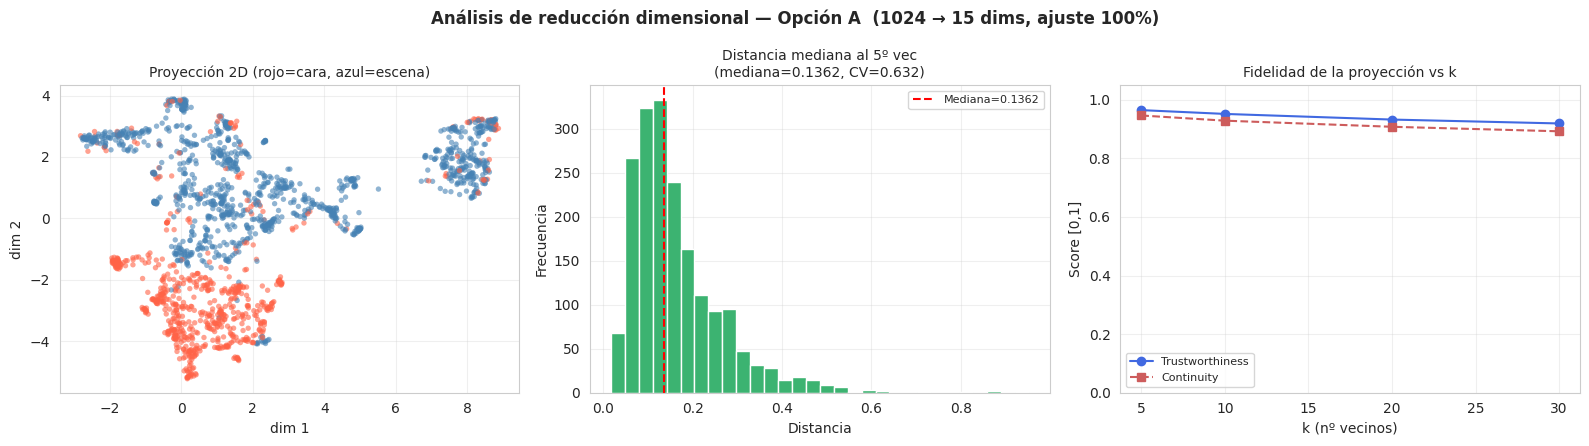


📝 INTERPRETACIÓN:
   ✅ Proyección excelente: conserva vecindarios en ambos sentidos.
   ✅ PCA captura 90% de la varianza: pipeline eficiente.
   🎯 PCA+UMAP combina denoising lineal y topología no-lineal.
   💾 Resultados guardados en /content/drive/MyDrive/TFM/Clustering/analysis_logs/Reduction Analysis/sceneC_faceA_dimredA.json


In [ ]:
# Usa new_embeddings_raw, new_embeddings_umap, new_embeddings_2d, pca_model, umap_model.

# ── Detectar la opción ejecutada ───────────────────────────────────────────
_pca_is_stub  = type(pca_model).__name__  == '_NoPCAStub'
_umap_is_stub = type(umap_model).__name__ == '_PCAOnlyStub'

if _umap_is_stub and not _pca_is_stub:
    analysis_option_9 = 'B'   # Solo PCA
    analysis_option_9_name = 'Solo PCA'
elif _pca_is_stub and not _umap_is_stub:
    analysis_option_9 = 'C'   # Solo UMAP
    analysis_option_9_name = 'Solo UMAP'
elif not _pca_is_stub and not _umap_is_stub:
    analysis_option_9 = 'A'   # PCA + UMAP
    analysis_option_9_name = 'PCA+UMAP'
else:
    analysis_option_9 = '?'
    analysis_option_9_name = '?'

print(f'🔬 Analizando reducción dimensional — OPCIÓN {analysis_option_9}')
_orig_dim  = new_embeddings_raw.shape[1]
_final_dim = new_embeddings_umap.shape[1]
print(f'   Dim original: {_orig_dim} → Dim final: {_final_dim} '
      f'(compresión {100*(1-_final_dim/_orig_dim):.1f}%)')
print('   Validación: métricas internas sobre el 100% de los datos (sin holdout)')
print('─' * 70)

# Inicializamos variables de métricas
analysis_trust = float('nan'); analysis_continuity = float('nan')
analysis_pca_var = None; analysis_recon_err = None
analysis_density_med = float('nan'); analysis_density_cv = float('nan')

# ── Trustworthiness y continuity ───────────────────────────────────────
# Para muestras grandes submuestreamos: trustworthiness se vuelve
# lento a partir de 1000 muestras.
_n = len(new_embeddings_umap)
if _n < CONFIG['METRIC_MIN_SAMPLES']:
    print(f'⚠️  Muy pocas muestras para analizar reducción dimensional '
          f'({_n} < {CONFIG["METRIC_MIN_SAMPLES"]}).')
else:
    if _n > CONFIG['TW_SAMPLE_SIZE']:
        _idx = np.random.RandomState(SEED).choice(_n, CONFIG['TW_SAMPLE_SIZE'], replace=False)
    else:
        _idx = np.arange(_n)

    # Embeddings normalizados (no cambia los vecinos; sí simplifica la métrica)
    _emb_hi = normalize(new_embeddings_raw[_idx], norm='l2')
    # Embeddings reducidos
    _emb_lo = new_embeddings_umap[_idx]

    # requisito de sklearn: n_neighbors < n_samples / 2.
    _k_tw = min(CONFIG['TW_K_NEIGHBORS'], (len(_idx) - 1) // 2)
    _k_tw = max(2, _k_tw)

    # Trustworthiness: ¿hay falsos amigos en el espacio reducido?
    analysis_trust = float(trustworthiness(_emb_hi, _emb_lo, n_neighbors=_k_tw))

    # Continuity: ¿hay amigos perdidos? (trustworthiness con espacios invertidos)
    analysis_continuity = float(trustworthiness(_emb_lo, _emb_hi, n_neighbors=_k_tw))

    print(f'📊 Trustworthiness (k={_k_tw})      : {analysis_trust:.4f} '
          '(↑ mejor; >0.9 excelente)')
    print(f'📊 Continuity  (k={_k_tw})          : {analysis_continuity:.4f} '
          '(↑ mejor; >0.9 excelente)')

    # ── Varianza PCA explicada y reconstruction error ─────────────────────
    if not _pca_is_stub and hasattr(pca_model, 'explained_variance_ratio_'):
        analysis_pca_var = float(pca_model.explained_variance_ratio_.sum())
        print(f'📊 Varianza PCA explicada       : {100*analysis_pca_var:.2f}% '
              f'(sobre {pca_model.n_components_} componentes)')

        # Reconstruction error: distancia coseno media entre el vector original
        # (L2-normalizado) y su reconstrucción tras pasar por PCA.
        try:
            _embs_norm_full  = normalize(new_embeddings_raw, norm='l2')
            _pca_proj        = pca_model.transform(_embs_norm_full)
            _pca_recon       = pca_model.inverse_transform(_pca_proj)
            # Distancia coseno = 1 - <x, x_recon>/(||x|| ||x_recon||)
            _num = (_embs_norm_full * _pca_recon).sum(axis=1)
            _den = np.linalg.norm(_embs_norm_full, axis=1) * np.linalg.norm(_pca_recon, axis=1) + 1e-12
            analysis_recon_err = float(1.0 - (_num / _den).mean())
            print(f'📊 Reconstruction error (cos)   : {analysis_recon_err:.4f} '
                  '(↓ mejor; ≈0 = sin pérdida)')
        except Exception as _e:
            analysis_recon_err = None
            print(f'📊 Reconstruction error (cos)   : N/D ({_e})')

    # ── Densidad local en el espacio reducido ─────────────────────────────
    # Distancia mediana al 5º vecino. Si es muy pequeña (~0.001), UMAP ha
    # aplastado todo; si es muy grande, no ha encontrado estructura.
    _kNN = min(5, len(new_embeddings_umap) - 1)
    _nn_obj = NearestNeighbors(n_neighbors=_kNN + 1).fit(new_embeddings_umap)
    _d, _ = _nn_obj.kneighbors(new_embeddings_umap)
    analysis_density_med = float(np.median(_d[:, -1]))
    analysis_density_cv  = float(_d[:, -1].std() / (_d[:, -1].mean() + 1e-9))
    print(f'📊 Distancia mediana al {_kNN}º vec  : {analysis_density_med:.4f} '
          f'(CV={analysis_density_cv:.3f})')

    # ── Gráficos ─────────────────────────────────────────────────────────
    _fig, _axes = plt.subplots(1, 3, figsize=(16, 4.5))
    _fig.suptitle(
        f'Análisis de reducción dimensional — Opción {analysis_option_9}  '
        f'({_orig_dim} → {_final_dim} dims, ajuste 100%)',
        fontsize=12, fontweight='bold',
    )

    # (a) Scatter 2D coloreado por presencia de cara
    if len(new_embeddings_2d) > 0:
        _colors = np.where(new_has_face, 'tomato', 'steelblue')
        _axes[0].scatter(new_embeddings_2d[:, 0], new_embeddings_2d[:, 1],
                         c=_colors, s=15, alpha=0.6, edgecolors='none')
        _axes[0].set_title('Proyección 2D (rojo=cara, azul=escena)', fontsize=10)
        _axes[0].set_xlabel('dim 1'); _axes[0].set_ylabel('dim 2')
        _axes[0].grid(alpha=0.3)

    # (b) Histograma de la distancia al kº vecino (siempre, sea cual sea la opción 10A/10B/10C)
    _axes[1].hist(_d[:, -1], bins=30, color='mediumseagreen', edgecolor='white')
    _axes[1].axvline(analysis_density_med, color='red', linestyle='--',
                     linewidth=1.5, label=f'Mediana={analysis_density_med:.4f}')
    _axes[1].set_title(f'Distancia mediana al {_kNN}º vec\n'
                       f'(mediana={analysis_density_med:.4f}, CV={analysis_density_cv:.3f})',
                       fontsize=10)
    _axes[1].set_xlabel('Distancia'); _axes[1].set_ylabel('Frecuencia')
    _axes[1].legend(fontsize=8); _axes[1].grid(alpha=0.3)

    # (c) Trustworthiness vs varios k
    _max_k = max(2, (len(_idx) - 1) // 2)
    _k_range = [5, 10, 20, min(30, _max_k)]
    _k_range = sorted(set(k for k in _k_range if 2 <= k <= _max_k))
    _tw_curve = [trustworthiness(_emb_hi, _emb_lo, n_neighbors=k) for k in _k_range]
    _cn_curve = [trustworthiness(_emb_lo, _emb_hi, n_neighbors=k) for k in _k_range]
    _axes[2].plot(_k_range, _tw_curve, 'o-', label='Trustworthiness', color='royalblue')
    _axes[2].plot(_k_range, _cn_curve, 's--', label='Continuity',    color='indianred')
    _axes[2].set_title('Fidelidad de la proyección vs k', fontsize=10)
    _axes[2].set_xlabel('k (nº vecinos)'); _axes[2].set_ylabel('Score [0,1]')
    _axes[2].set_ylim(0, 1.05); _axes[2].legend(fontsize=8); _axes[2].grid(alpha=0.3)

    plt.tight_layout()
    _dimred_plot_path = os.path.join(analysis_logger._section_folder('dimred'),
                                     f'dimred_{analysis_option_9}_diag.png')
    plt.savefig(_dimred_plot_path, dpi=120, bbox_inches='tight')
    plt.show()

    # ── Conclusiones ──────────────────────────────────────────────────────
    print('\n📝 INTERPRETACIÓN:')
    _conclusions_9 = []
    if analysis_trust > 0.9 and analysis_continuity > 0.9:
        _conclusions_9.append('✅ Proyección excelente: conserva vecindarios en ambos sentidos.')
    elif analysis_trust > 0.8 and analysis_continuity > 0.8:
        _conclusions_9.append('✅ Proyección buena: apta para clustering.')
    elif analysis_trust > 0.7:
        _conclusions_9.append('⚠️  Proyección aceptable pero con pérdidas; considerar aumentar UMAP_N_NEIGHBORS.')
    else:
        _conclusions_9.append('❌ Proyección pobre: revisar metric/min_dist o probar otra opción.')

    if analysis_pca_var is not None:
        if analysis_pca_var < 0.6:
            _conclusions_9.append(f'⚠️  PCA explica solo {100*analysis_pca_var:.0f}%: considerar subir PCA_COMPONENTS.')
        else:
            _conclusions_9.append(f'✅ PCA captura {100*analysis_pca_var:.0f}% de la varianza: pipeline eficiente.')

    if analysis_recon_err is not None and analysis_recon_err > 0.10:
        _conclusions_9.append(f'⚠️  Reconstruction error elevado ({analysis_recon_err:.3f}): la compresión está perdiendo información — subir PCA_COMPONENTS.')

    if analysis_density_cv > 2.0:
        _conclusions_9.append('ℹ️  Densidad muy heterogénea: probable estructura multi-cluster (favorable para HDBSCAN).')
    elif analysis_density_cv < 0.3:
        _conclusions_9.append('⚠️  Densidad demasiado uniforme: posible colapso; revisar min_dist.')

    if analysis_option_9 == 'A':
        _conclusions_9.append('🎯 PCA+UMAP combina denoising lineal y topología no-lineal.')
    elif analysis_option_9 == 'B':
        _conclusions_9.append('⚡ Solo PCA: más rápido y determinista, pero no captura manifolds no-lineales.')
    elif analysis_option_9 == 'C':
        _conclusions_9.append('🌀 Solo UMAP: máxima fidelidad no-lineal, pero sensible al ruido y más costoso.')

    for _c in _conclusions_9:
        print(f'   {_c}')

    # ── Persistencia ──────────────────────────────────────────────────────
    analysis_logger.save('dimred', f'scene{analysis_option_6[0]}_face{analysis_option_7}_dimred{analysis_option_9}', {
        'scene_class'         : analysis_option_6[1],
        'face_class'          : _face_class,
        'reduction_class'     : analysis_option_9_name,
        'orig_dim'            : int(_orig_dim),
        'final_dim'           : int(_final_dim),
        'compression_pct'     : float(100 * (1 - _final_dim / _orig_dim)),
        'trustworthiness'     : float(analysis_trust) if not np.isnan(analysis_trust) else None,
        'continuity'          : float(analysis_continuity) if not np.isnan(analysis_continuity) else None,
        'pca_variance'        : analysis_pca_var,
        'recon_error_cosine'  : analysis_recon_err,
        'density_median'      : float(analysis_density_med) if not np.isnan(analysis_density_med) else None,
        'density_cv'          : float(analysis_density_cv) if not np.isnan(analysis_density_cv) else None,
        'plot_path'           : _dimred_plot_path,
        'conclusions'         : _conclusions_9,
    })

---
## Celda 11 — Asignación incremental + Clustering

> **Tres bloques: 11A, 11B o 11C.**
> Para definir: `new_cluster_labels`, `auto_assigned_count`, `new_clusters_found`,
> `pool_indices`, `pool_labels`, `clusterer`.

| Bloque | Clustering | k a priori | Detecta ruido |
|--------|-----------|-----------|---------------|
| **11A** ✅ | HDBSCAN | No | Sí |
| **11B** | KMeans auto | No (codo) | No |
| **11C** | GMM (BIC) | No (BIC) | No |

### Objetivo
Agrupar las fotos nuevas en clusters con los ya existentes en sesiones anteriores, decidiendo automáticamente cuántos clusters nuevos se necesitan.

### Teoría
Las tres opciones implementan la misma estrategia en dos fases:

- **FASE 1 — Asignación incremental**: para cada foto nueva, miramos si la distancia mínima ≤ `ASSIGN_DISTANCE_THRESHOLD` del centroide de algún cluster ya consolidado en sesiones anteriores. Si lo está, se asigna automáticamente sin reclustering.

- **FASE 2 — Re-clustering del pool**: las fotos NO asignadas (o todas, si es la primera ejecución) se agrupan con el algoritmo de la opción elegida.

- Importante tener en cuenta que si el umbral `ASSIGN_DISTANCE_THRESHOLD` es demasiado permisivo, fotos nuevas se "tragan" en clusters incorrectos; si es demasiado estricto, todo va al pool y los clusters existentes nunca crecen.

---
### 11A — Selección empírica de `HDBSCAN_MIN_CLUSTER_SIZE` y `MIN_SAMPLES`


### Objetivo
Elegir la combinación `(min_cluster_size, min_samples)` que mejor equilibra **calidad**
(Silhouette Score) y **estabilidad** (ARI bootstrap) del clustering.

El barrido es **bidimensional**: para cada par de candidatos se ejecuta HDBSCAN y se
miden cuatro métricas (clusters, ruido, Silhouette, ARI). La mejor combinación se
selecciona automáticamente mediante la **media armónica** de Silhouette y ARI normalizados,
lo que penaliza configuraciones que sacrifican una métrica a costa de la otra.

### Información extra
- Solo se ejecuta en la primera ejecución (`IS_FIRST_RUN=True`). En modo incremental el
  hiperparámetro está fijado por la sesión inicial.
- El gráfico se persiste en `ANALYSIS_DIR/` para trazabilidad.


Barrido: 6 × 4 = 24 combinaciones  (ARI promediado sobre 3 semillas)


Barrido HDBSCAN:   0%|          | 0/6 [00:00<?, ?it/s]


Resultados (✗ = descartada por filtro, 🏆 = seleccionada):
   mcs  ms  k  ruido%   sil   ari
     5   3 84    16.8 0.584 0.774
     5   5 57    18.0 0.607 0.797
    10   3 39    11.4 0.620 0.895
    10   5 35    14.5 0.633 0.802
🏆   10  10 32    19.4 0.673 0.771
    15   3 30    10.0 0.608 0.853
    15   5 27    13.3 0.621 0.802
    15  10 24    16.6 0.627 0.836
    15  15 24    18.4 0.643 0.551
    20   3 21    14.6 0.598 0.855
    20   5 20    14.1 0.587 0.854
    20  10 19    18.4 0.619 0.325
    20  15 19    20.1 0.630 0.077
    30   3 18    17.3 0.591 0.819
    30   5 17    16.6 0.577 0.520
    30  10 17    21.0 0.613 0.080
✗   30  15  2     0.0 0.610 1.000
✗   50   3  2     0.0 0.610 1.000
✗   50   5  2     0.0 0.610 1.000
✗   50  10  2     0.0 0.610 1.000
✗   50  15  2     0.0 0.610 1.000

🏆 Mejor combinación:
   min_cluster_size = 10
   min_samples      = 10
   Silhouette       = 0.673
   ARI (media ×3)   = 0.771
   Clusters         = 32
   Ruido            = 19.4%


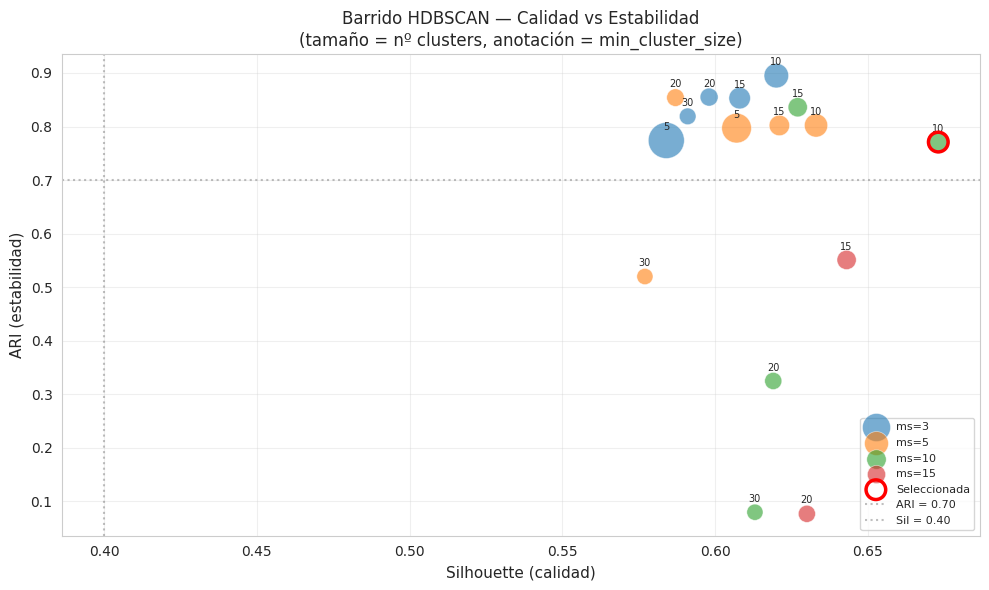

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Selección empírica de HDBSCAN_MIN_CLUSTER_SIZE y MIN_SAMPLES
# ════════════════════════════════════════════════════════════════════════════
#
# Barrido bidimensional sobre el espacio UMAP ya calculado.
# Para cada par (min_cluster_size, min_samples):
#   1. Se ejecuta HDBSCAN y se mide Silhouette (calidad) y ARI (estabilidad).
#   2. ARI se promedia sobre 3 semillas de bootstrap para reducir artefactos.
#   3. Se filtran configuraciones degeneradas (<5 clusters, >25% ruido, Sil<0.40).
#   4. Se selecciona la que maximiza un score compuesto ponderado 40% Sil + 60% ARI,
#      priorizando estabilidad sobre cohesión.
#
# ════════════════════════════════════════════════════════════════════════════

if len(new_valid_files) >= 30 and IS_FIRST_RUN:

    n_data = len(new_valid_files)

    # ── Candidatos ────────────────────────────────────────────────────────
    candidate_mcs = [s for s in [5, 10, 15, 20, 30, 50]
                     if s <= max(5, n_data // 4)]
    adaptive_ms = CONFIG.get('HDBSCAN_MIN_SAMPLES', 5)
    candidate_ms = sorted({3, 5, adaptive_ms, 10, 15}
                          & set(range(1, max(candidate_mcs) + 1)))

    # ── Semillas para bootstrap ARI (3 repeticiones) ─────────────────────
    ARI_SEEDS = [42, 123, 777]

    sensitivity_results = []
    print(f'Barrido: {len(candidate_mcs)} × {len(candidate_ms)} = '
          f'{len(candidate_mcs) * len(candidate_ms)} combinaciones  '
          f'(ARI promediado sobre {len(ARI_SEEDS)} semillas)')

    for mcs in tqdm(candidate_mcs, desc='Barrido HDBSCAN'):
        for ms in candidate_ms:
            if ms > mcs:
                continue

            # Clustering principal
            c = hdbscan.HDBSCAN(
                min_cluster_size=mcs, min_samples=ms,
                metric='euclidean', cluster_selection_method='eom',
            )
            labels = c.fit_predict(new_embeddings_umap)

            n_clusters = len(set(labels) - {-1})
            pct_noise  = 100.0 * (labels == -1).sum() / len(labels)
            valid_mask = labels != -1

            # Silhouette
            sil = np.nan
            if n_clusters >= 2 and valid_mask.sum() >= 4:
                sil = silhouette_score(
                    new_embeddings_umap[valid_mask], labels[valid_mask])

            # ARI: promedio sobre varias semillas para reducir artefactos
            ari_vals = []
            if n_clusters >= 2 and n_data >= 20:
                for seed in ARI_SEEDS:
                    rng = np.random.RandomState(seed)
                    sub = rng.choice(n_data, int(0.8 * n_data), replace=False)
                    try:
                        c2 = hdbscan.HDBSCAN(
                            min_cluster_size=mcs, min_samples=ms,
                            metric='euclidean', cluster_selection_method='eom',
                        )
                        lab2 = c2.fit_predict(new_embeddings_umap[sub])
                        ari_vals.append(adjusted_rand_score(labels[sub], lab2))
                    except Exception:
                        pass
            ari = float(np.mean(ari_vals)) if ari_vals else np.nan

            sensitivity_results.append({
                'mcs': mcs, 'ms': ms, 'k': n_clusters,
                'ruido%': round(pct_noise, 1),
                'sil': round(sil, 3) if not np.isnan(sil) else np.nan,
                'ari': round(ari, 3) if not np.isnan(ari) else np.nan,
            })

    df = pd.DataFrame(sensitivity_results)

    # ── Filtrado de candidatos viables ────────────────────────────────────
    viable = df.dropna(subset=['sil', 'ari']).copy()
    viable = viable[
        (viable['sil']    > 0.40) &  # calidad mínima aceptable
        (viable['ruido%'] < 25)   &  # máximo ruido tolerable
        (viable['k']      >= 5)      # excluir particiones degeneradas
    ]

    # ── Selección: score ponderado 40% Silhouette + 60% ARI ──────────────
    # Prioriza estabilidad (ARI) porque en un pipeline de fotos domésticas
    # importa más que los clusters se mantengan al añadir imágenes nuevas.
    if len(viable) > 0:
        _s = (viable['sil'] - viable['sil'].min()) / (viable['sil'].max() - viable['sil'].min() + 1e-9)
        _a = (viable['ari'] - viable['ari'].min()) / (viable['ari'].max() - viable['ari'].min() + 1e-9)
        viable = viable.copy()
        viable['score'] = 0.40 * _s + 0.60 * _a

        best_idx = viable['score'].idxmax()
        best = viable.loc[best_idx]

        RECOMMENDED_MCS = int(best['mcs'])
        RECOMMENDED_MS  = int(best['ms'])
    else:
        RECOMMENDED_MCS = CONFIG.get('HDBSCAN_MIN_CLUSTER_SIZE', 20)
        RECOMMENDED_MS  = CONFIG.get('HDBSCAN_MIN_SAMPLES', 5)

    # ── Tabla de resultados ───────────────────────────────────────────────
    # Marcar la fila seleccionada y las descartadas por filtro
    display_df = df.copy()
    tags = []
    for _, row in display_df.iterrows():
        is_best = (row['mcs'] == RECOMMENDED_MCS and row['ms'] == RECOMMENDED_MS)
        in_viable = (
            not np.isnan(row['sil']) and not np.isnan(row['ari']) and
            row['sil'] > 0.40 and row['ruido%'] < 25 and row['k'] >= 5
        )
        if is_best:
            tags.append('🏆')
        elif not in_viable:
            tags.append('✗')
        else:
            tags.append('')
    display_df.insert(0, '', tags)
    print('\nResultados (✗ = descartada por filtro, 🏆 = seleccionada):')
    print(display_df.to_string(index=False))

    print(f'\n🏆 Mejor combinación:')
    print(f'   min_cluster_size = {RECOMMENDED_MCS}')
    print(f'   min_samples      = {RECOMMENDED_MS}')
    print(f'   Silhouette       = {best["sil"]:.3f}')
    print(f'   ARI (media ×3)   = {best["ari"]:.3f}')
    print(f'   Clusters         = {int(best["k"])}')
    print(f'   Ruido            = {best["ruido%"]:.1f}%')

    # ── Visualización: un solo gráfico resumen ───────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))

    # Solo mostrar combinaciones viables + la seleccionada
    for ms_val in candidate_ms:
        sub = df[(df['ms'] == ms_val) & df['sil'].notna() & df['ari'].notna()
                 & (df['k'] >= 5)]
        if len(sub) == 0:
            continue
        scatter = ax.scatter(
            sub['sil'], sub['ari'],
            s=sub['k'] * 8,              # tamaño = nº clusters
            alpha=0.6, label=f'ms={ms_val}',
            edgecolors='white', linewidth=0.5,
        )
        # Anotar cada punto con mcs
        for _, row in sub.iterrows():
            ax.annotate(f'{int(row["mcs"])}',
                        (row['sil'], row['ari']),
                        fontsize=7, ha='center', va='bottom',
                        textcoords='offset points', xytext=(0, 6))

    # Marcar la seleccionada
    ax.scatter([best['sil']], [best['ari']],
               s=200, facecolors='none', edgecolors='red',
               linewidths=2.5, zorder=10, label='Seleccionada')

    # Zonas de referencia
    ax.axhline(0.70, color='gray', ls=':', alpha=0.5, label='ARI = 0.70')
    ax.axvline(0.40, color='gray', ls=':', alpha=0.5, label='Sil = 0.40')

    ax.set_xlabel('Silhouette (calidad)', fontsize=11)
    ax.set_ylabel('ARI (estabilidad)',    fontsize=11)
    ax.set_title('Barrido HDBSCAN — Calidad vs Estabilidad\n'
                 '(tamaño = nº clusters, anotación = min_cluster_size)',
                 fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()

    _sens_plot = os.path.join(analysis_logger._section_folder('clustering'),
                              'sensitivity_2d_hdbscan.png')
    plt.savefig(_sens_plot, dpi=120, bbox_inches='tight')
    plt.show()

else:
    if not IS_FIRST_RUN:
        print('Modo incremental — omitiendo análisis de sensibilidad.')
    else:
        print(f'Dataset insuficiente ({len(new_valid_files)} < 30).')


In [ ]:
# ── Aplicar la mejor combinación del barrido de sensibilidad ──────────────
# Si el barrido encontró una combinación óptima, la aplica.
# Si no (modo incremental o dataset pequeño), mantiene los valores adaptativos.

if 'RECOMMENDED_MCS' in dir() and 'RECOMMENDED_MS' in dir():
    CONFIG['HDBSCAN_MIN_CLUSTER_SIZE'] = RECOMMENDED_MCS
    CONFIG['HDBSCAN_MIN_SAMPLES']      = RECOMMENDED_MS
    print(f'✅ Parámetros HDBSCAN actualizados con la mejor combinación del barrido:')
else:
    # Sin barrido disponible: mantener los valores adaptativos de la celda de resolución
    print(f'✅ Parámetros HDBSCAN con valores adaptativos (sin barrido):')

print(f'   HDBSCAN_MIN_CLUSTER_SIZE = {CONFIG["HDBSCAN_MIN_CLUSTER_SIZE"]}')
print(f'   HDBSCAN_MIN_SAMPLES      = {CONFIG["HDBSCAN_MIN_SAMPLES"]}')


✅ Parámetros HDBSCAN actualizados con la mejor combinación del barrido:
   HDBSCAN_MIN_CLUSTER_SIZE = 10
   HDBSCAN_MIN_SAMPLES      = 10


### Asignación incremental + HDBSCAN

El algoritmo HDBSCAN:

- No requiere especificar el número de clusters de antemano.
- Detecta automáticamente puntos de ruido (etiqueta -1).
- Maneja densidades variables (algunos clusters con muchas fotos, otros con pocas).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 11A — Asignación incremental + HDBSCAN
# ════════════════════════════════════════════════════════════════════════════


def cosine_distance_to_centroids(embeddings, centroids):
    """
    Matriz de distancias coseno (N x C) entre N embeddings y C centroides.
    Distancia coseno = 1 - similitud coseno. Rango [0, 2].
    Trabajamos con vectores L2-normalizados para que el producto matricial
    devuelva directamente la similitud coseno.
    """
    emb_norm = normalize(embeddings, norm='l2')
    cen_norm = normalize(centroids,  norm='l2')
    return 1.0 - (emb_norm @ cen_norm.T)


# ── FASE 1: Asignación a clusters existentes ───────────────────────────────
new_cluster_labels  = np.full(len(new_valid_files), -1, dtype=int)
auto_assigned_count = 0
pool_indices        = []   # Índices que pasarán a la fase 2 (HDBSCAN)

if (not IS_FIRST_RUN
        and session.cluster_centroids is not None
        and len(session.cluster_centroids) > 0):
    print(f'Asignando a clusters existentes (umbral coseno: {CONFIG["ASSIGN_DISTANCE_THRESHOLD"]})...')
    distances = cosine_distance_to_centroids(new_embeddings_umap, session.cluster_centroids)
    threshold = CONFIG['ASSIGN_DISTANCE_THRESHOLD']
    for i in range(len(new_valid_files)):
        min_dist = distances[i].min()
        best_lbl = session.centroid_labels[distances[i].argmin()]
        if min_dist <= threshold:
            new_cluster_labels[i] = best_lbl
            auto_assigned_count  += 1
        else:
            pool_indices.append(i)
    print(f'✅ Asignados automáticamente : {auto_assigned_count}')
    print(f'❓ En pool para clustering   : {len(pool_indices)}')
else:
    pool_indices = list(range(len(new_valid_files)))
    print(f'Primera ejecución: {len(pool_indices)} archivos al pool.')

# ── FASE 2: HDBSCAN sobre el pool no asignado ──────────────────────────────
existing_label_ids = list(session.cluster_names.keys()) if not IS_FIRST_RUN else []
max_existing_label = max(existing_label_ids) if existing_label_ids else -1
pool_labels        = np.full(len(pool_indices), -1, dtype=int)
new_clusters_found = 0
clusterer          = None

if len(pool_indices) >= 2:
    pool_embs        = new_embeddings_umap[pool_indices]
    n_pool           = len(pool_indices)
    # min_cluster_size se ajusta automáticamente para datasets pequeños
    min_cluster_size = min(CONFIG['HDBSCAN_MIN_CLUSTER_SIZE'], max(2, n_pool // 20))
    min_samples      = min(CONFIG['HDBSCAN_MIN_SAMPLES'], min_cluster_size)
    print(f'\nHDBSCAN sobre {n_pool} archivos (min_cluster_size={min_cluster_size})')

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom',   # Excess of Mass: prefiere clusters estables
        prediction_data=True,             # Permite predict en datos nuevos después
        gen_min_span_tree=True,           # Necesario para calcular DBCV
    )
    raw_pool_labels = clusterer.fit_predict(pool_embs)

    # ── Remapeo de IDs de cluster ───────────────────────────────────────────
    # Si la sesión anterior tenía clusters [0, 1, 2], los nuevos serán 3, 4...
    # El -1 (ruido) se mantiene
    remap   = {}
    next_id = max_existing_label + 1
    for raw_id in sorted(set(raw_pool_labels)):
        if raw_id == -1:
            remap[-1] = -1
        else:
            remap[raw_id] = next_id
            next_id += 1
    pool_labels        = np.array([remap[l] for l in raw_pool_labels])
    new_clusters_found = len([l for l in remap.values() if l != -1])
    print(f'✅ Clusters nuevos: {new_clusters_found} | Ruido: {(pool_labels == -1).sum()}')

elif len(pool_indices) == 1:
    pool_labels = np.array([-1])
    print('Solo 1 archivo en el pool → marcado como ruido.')

# Volcamos las etiquetas del pool al array global
for pool_pos, orig_idx in enumerate(pool_indices):
    new_cluster_labels[orig_idx] = pool_labels[pool_pos]

# Resumen final por cluster
print('\nDistribución final:')
for lbl in sorted(set(new_cluster_labels)):
    cnt = (new_cluster_labels == lbl).sum()
    tag = 'RUIDO' if lbl == -1 else ('existente' if lbl in existing_label_ids else 'NUEVO')
    print(f'  Cluster {lbl:4d} [{tag:10s}]: {cnt} archivos')

_pipeline_options['clustering'] = '11A'

Primera ejecución: 1873 archivos al pool.

HDBSCAN sobre 1873 archivos (min_cluster_size=10)
✅ Clusters nuevos: 32 | Ruido: 363

Distribución final:
  Cluster   -1 [RUIDO     ]: 363 archivos
  Cluster    0 [NUEVO     ]: 299 archivos
  Cluster    1 [NUEVO     ]: 19 archivos
  Cluster    2 [NUEVO     ]: 66 archivos
  Cluster    3 [NUEVO     ]: 17 archivos
  Cluster    4 [NUEVO     ]: 21 archivos
  Cluster    5 [NUEVO     ]: 128 archivos
  Cluster    6 [NUEVO     ]: 13 archivos
  Cluster    7 [NUEVO     ]: 39 archivos
  Cluster    8 [NUEVO     ]: 18 archivos
  Cluster    9 [NUEVO     ]: 42 archivos
  Cluster   10 [NUEVO     ]: 17 archivos
  Cluster   11 [NUEVO     ]: 59 archivos
  Cluster   12 [NUEVO     ]: 28 archivos
  Cluster   13 [NUEVO     ]: 33 archivos
  Cluster   14 [NUEVO     ]: 63 archivos
  Cluster   15 [NUEVO     ]: 12 archivos
  Cluster   16 [NUEVO     ]: 70 archivos
  Cluster   17 [NUEVO     ]: 10 archivos
  Cluster   18 [NUEVO     ]: 45 archivos
  Cluster   19 [NUEVO     ]:

### 11B — Asignación incremental + KMeans automático

El algoritmo Kmeans:

- Busca k óptimo evaluando la curva de inercia (método del codo). Elegimos el k a partir del
cual añadir más clusters apenas reduce la inercia.

- KMeans genera centroides esféricos.
- No tiene noción de ruido.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 11B — Asignación incremental + KMeans con k automático
# ════════════════════════════════════════════════════════════════════════════

# ── FASE 1: Asignación a clusters existentes (idéntica a 11A) ───────────
new_cluster_labels  = np.full(len(new_valid_files), -1, dtype=int)
auto_assigned_count = 0
pool_indices        = []
if (not IS_FIRST_RUN and session.cluster_centroids is not None
        and len(session.cluster_centroids) > 0):
    emb_n = normalize(new_embeddings_umap, norm='l2')
    cen_n = normalize(session.cluster_centroids, norm='l2')
    distances = 1.0 - (emb_n @ cen_n.T)
    for i in range(len(new_valid_files)):
        if distances[i].min() <= CONFIG['ASSIGN_DISTANCE_THRESHOLD']:
            new_cluster_labels[i] = session.centroid_labels[distances[i].argmin()]
            auto_assigned_count  += 1
        else:
            pool_indices.append(i)
    print(f'Asignados: {auto_assigned_count} | Pool: {len(pool_indices)}')
else:
    pool_indices = list(range(len(new_valid_files)))
    print(f'Primera ejecución: {len(pool_indices)} archivos al pool.')

# ── FASE 2: KMeans con k automático (método del codo) ──────────────────────
existing_label_ids = list(session.cluster_names.keys()) if not IS_FIRST_RUN else []
max_existing_label = max(existing_label_ids) if existing_label_ids else -1
pool_labels        = np.full(len(pool_indices), -1, dtype=int)
new_clusters_found = 0
clusterer          = None

if len(pool_indices) >= 4:
    pool_embs = new_embeddings_umap[pool_indices]
    n_pool    = len(pool_indices)
    # k_max: heurística sqrt(n) acotada a 30. Probar más k es coste sin beneficio.
    k_max     = max(2, min(int(np.sqrt(n_pool)), 30))
    k_range   = range(2, k_max + 1)
    print(f'Buscando k óptimo en [2, {k_max}]...')

    # Calculamos inercia normalizada para cada k
    # Normalizar por (n_pool * k) compensa el efecto de tener más clusters
    inertias = []
    for k in k_range:
        km = KMeans(
            n_clusters=k,
            n_init=5,                # 5 inicializaciones random + nos quedamos con la mejor
            random_state=SEED,       # ← Reproducibilidad
        )
        km.fit(pool_embs)
        inertias.append(km.inertia_ / (n_pool * k))

    # Detección del codo usando diferencias de segundo orden:
    # second_diff[i] = inertia[i] - 2*inertia[i+1] + inertia[i+2]
    # el codo está donde la curva cambia más bruscamente de pendiente.
    if len(inertias) > 2:
        second_diff = np.diff(np.diff(inertias))
        best_k      = list(k_range)[np.argmax(second_diff) + 1]
    else:
        best_k = 2
    print(f'k óptimo: {best_k}')

    # Ajuste final con n_init más alto para mayor estabilidad
    clusterer       = KMeans(n_clusters=best_k, n_init=10, random_state=SEED)
    raw_pool_labels = clusterer.fit_predict(pool_embs)
    next_id         = max_existing_label + 1
    remap           = {i: next_id + i for i in range(best_k)}
    pool_labels     = np.array([remap[l] for l in raw_pool_labels])
    new_clusters_found = best_k
    print(f'✅ Clusters nuevos (KMeans): {new_clusters_found}')

elif len(pool_indices) >= 2:
    # Pool muy pequeño: agrupamos todo en un solo cluster
    pool_labels = np.full(len(pool_indices), max_existing_label + 1, dtype=int)
    new_clusters_found = 1

for pool_pos, orig_idx in enumerate(pool_indices):
    new_cluster_labels[orig_idx] = pool_labels[pool_pos]

print('\nDistribución final:')
for lbl in sorted(set(new_cluster_labels)):
    cnt = (new_cluster_labels == lbl).sum()
    tag = 'RUIDO' if lbl == -1 else ('existente' if lbl in existing_label_ids else 'NUEVO')
    print(f'  Cluster {lbl:4d} [{tag:10s}]: {cnt} archivos')

_pipeline_options['clustering'] = '11B'

Primera ejecución: 1873 archivos al pool.
Buscando k óptimo en [2, 30]...
k óptimo: 3
✅ Clusters nuevos (KMeans): 3

Distribución final:
  Cluster    0 [NUEVO     ]: 725 archivos
  Cluster    1 [NUEVO     ]: 299 archivos
  Cluster    2 [NUEVO     ]: 849 archivos


### 11C — Asignación incremental + Gaussian Mixture Model

El algoritmo de GMM:

- Modela cada cluster como distribución gaussiana multivariante. Esto le permite
capturar clusters elipsoidales (estirados en alguna dirección).

- k óptimo seleccionado por mínimo BIC (Bayesian Information Criterion), que penaliza
modelos más complejos.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 11C — Asignación incremental + Gaussian Mixture Model (GMM)
# ════════════════════════════════════════════════════════════════════════════

# ── FASE 1: Asignación a clusters existentes (idéntica a 11A) ──────────────
new_cluster_labels  = np.full(len(new_valid_files), -1, dtype=int)
auto_assigned_count = 0
pool_indices        = []
if (not IS_FIRST_RUN and session.cluster_centroids is not None
        and len(session.cluster_centroids) > 0):
    emb_n = normalize(new_embeddings_umap, norm='l2')
    cen_n = normalize(session.cluster_centroids, norm='l2')
    distances = 1.0 - (emb_n @ cen_n.T)
    for i in range(len(new_valid_files)):
        if distances[i].min() <= CONFIG['ASSIGN_DISTANCE_THRESHOLD']:
            new_cluster_labels[i] = session.centroid_labels[distances[i].argmin()]
            auto_assigned_count  += 1
        else:
            pool_indices.append(i)
    print(f'Asignados: {auto_assigned_count} | Pool: {len(pool_indices)}')
else:
    pool_indices = list(range(len(new_valid_files)))
    print(f'Primera ejecución: {len(pool_indices)} archivos al pool.')

# ── FASE 2: GMM con n_components óptimo por BIC ────────────────────────────
existing_label_ids = list(session.cluster_names.keys()) if not IS_FIRST_RUN else []
max_existing_label = max(existing_label_ids) if existing_label_ids else -1
pool_labels        = np.full(len(pool_indices), -1, dtype=int)
new_clusters_found = 0
clusterer          = None

if len(pool_indices) >= 4:
    pool_embs = new_embeddings_umap[pool_indices]
    n_pool    = len(pool_indices)
    # n_max conservador: GMM con muchos componentes en datasets pequeños
    # tiende a sobreajustar incluso con BIC.
    n_max     = max(2, min(int(np.sqrt(n_pool)), 20))
    print(f'Seleccionando n_components por BIC (rango [2, {n_max}])...')

    # Barrido de modelos GMM con distinto número de componentes
    bic_scores = []
    for n in range(2, n_max + 1):
        gmm = GaussianMixture(
            n_components=n,
            covariance_type='diag',  # Matrices diagonales: menos parámetros, menos overfitting
            n_init=3,
            random_state=SEED,
        )
        gmm.fit(pool_embs)
        bic_scores.append((n, gmm.bic(pool_embs)))

    # Elegimos el n con menor BIC
    best_n = min(bic_scores, key=lambda x: x[1])[0]
    print(f'n_components óptimo por BIC: {best_n}')

    # n_init más alto para mayor estabilidad
    clusterer = GaussianMixture(
        n_components=best_n,
        covariance_type='diag',
        n_init=5,
        random_state=SEED,
    )
    raw_pool_labels = clusterer.fit_predict(pool_embs)
    next_id         = max_existing_label + 1
    remap           = {i: next_id + i for i in range(best_n)}
    pool_labels     = np.array([remap[l] for l in raw_pool_labels])
    new_clusters_found = best_n
    print(f'✅ Clusters nuevos (GMM): {new_clusters_found}')

elif len(pool_indices) >= 2:
    pool_labels = np.full(len(pool_indices), max_existing_label + 1, dtype=int)
    new_clusters_found = 1

for pool_pos, orig_idx in enumerate(pool_indices):
    new_cluster_labels[orig_idx] = pool_labels[pool_pos]

print('\nDistribución final:')
for lbl in sorted(set(new_cluster_labels)):
    cnt = (new_cluster_labels == lbl).sum()
    tag = 'RUIDO' if lbl == -1 else ('existente' if lbl in existing_label_ids else 'NUEVO')
    print(f'  Cluster {lbl:4d} [{tag:10s}]: {cnt} archivos')

_pipeline_options['clustering'] = '11C'

Primera ejecución: 1873 archivos al pool.
Seleccionando n_components por BIC (rango [2, 20])...
n_components óptimo por BIC: 20
✅ Clusters nuevos (GMM): 20

Distribución final:
  Cluster    0 [NUEVO     ]: 89 archivos
  Cluster    1 [NUEVO     ]: 101 archivos
  Cluster    2 [NUEVO     ]: 194 archivos
  Cluster    3 [NUEVO     ]: 86 archivos
  Cluster    4 [NUEVO     ]: 98 archivos
  Cluster    5 [NUEVO     ]: 33 archivos
  Cluster    6 [NUEVO     ]: 69 archivos
  Cluster    7 [NUEVO     ]: 128 archivos
  Cluster    8 [NUEVO     ]: 133 archivos
  Cluster    9 [NUEVO     ]: 57 archivos
  Cluster   10 [NUEVO     ]: 128 archivos
  Cluster   11 [NUEVO     ]: 95 archivos
  Cluster   12 [NUEVO     ]: 73 archivos
  Cluster   13 [NUEVO     ]: 105 archivos
  Cluster   14 [NUEVO     ]: 109 archivos
  Cluster   15 [NUEVO     ]: 178 archivos
  Cluster   16 [NUEVO     ]: 67 archivos
  Cluster   17 [NUEVO     ]: 35 archivos
  Cluster   18 [NUEVO     ]: 76 archivos
  Cluster   19 [NUEVO     ]: 19 arch

---
## Celda 12 — Evaluación y análisis del clustering

### Objetivo
Cuantificar la calidad del clustering producido por la opción ejecutada (11A/B/C) con
todas las métricas relevantes — internas y de estabilidad.

#### Métricas internas

- **Silhouette Score** — rango [-1, 1]. Cohesión intra-cluster vs
  separación inter-cluster. >0.5 indica clustering claro; >0.25 aceptable.
- **Davies-Bouldin Index** — relación dispersión/distancia. Menor es mejor.
- **Calinski-Harabasz Score** — varianza inter/intra. Mayor es mejor; sin cota superior.
- **DBCV** — *Density-Based Clustering Validation*. Métrica
  específica para HDBSCAN: penaliza ruido y recompensa densidad relativa.

#### Diagnósticos adicionales

- **Distribución de tamaños de cluster** y su asimetría — clusters muy desbalanceados
  (uno con el 80% y muchos diminutos) suelen indicar mala separación.
- **Porcentaje de ruido** — solo HDBSCAN. >40% sugiere mal ajuste.
- **Estabilidad por bootstrap (ARI)** — re-clusterizamos un 80% aleatorio y medimos el
  *Adjusted Rand Index* contra la asignación original. >0.7 indica clustering robusto:
  añadir o quitar fotos no reorganiza las carpetas. **Crítico para uso incremental.**
- **Separación inter-cluster** — distancia coseno media entre centroides.

Importante tener en cuenta que el bootstrap re-ejecuta el algoritmo de clustering, lo que puede tardar en
colecciones grandes. Para datasets <500 muestras se omite por evitar warnings de HDBSCAN.

🔬 Evaluación + análisis del clustering — OPCIÓN A (HDBSCAN)
──────────────────────────────────────────────────────────────────────
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   📊 MÉTRICAS DE CALIDAD DEL CLUSTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 Silhouette Score           : +0.6726  (↑ mejor, máx=1.0)
   → ✅ Clustering de alta calidad
📉 Davies-Bouldin Index       : 0.4389  (↓ mejor)
📊 Calinski-Harabasz Score    : 3644.02  (↑ mejor)
🎯 DBCV (HDBSCAN)             : +0.3361  (↑ mejor)

📦 Tamaños clusters (max/min) : 299 / 10 (desbalance=29.9×)
    Tamaño promedio           : 47.2 fotos
🗑 Ruido (% del pool)         : 19.4% (363 archivos)
🔁 Estabilidad ARI (bootstrap): +0.7779 (↑ mejor; >0.7 excelente)
🔀 Separación inter-cluster   : 0.0128 (dist. coseno ↑ mejor)


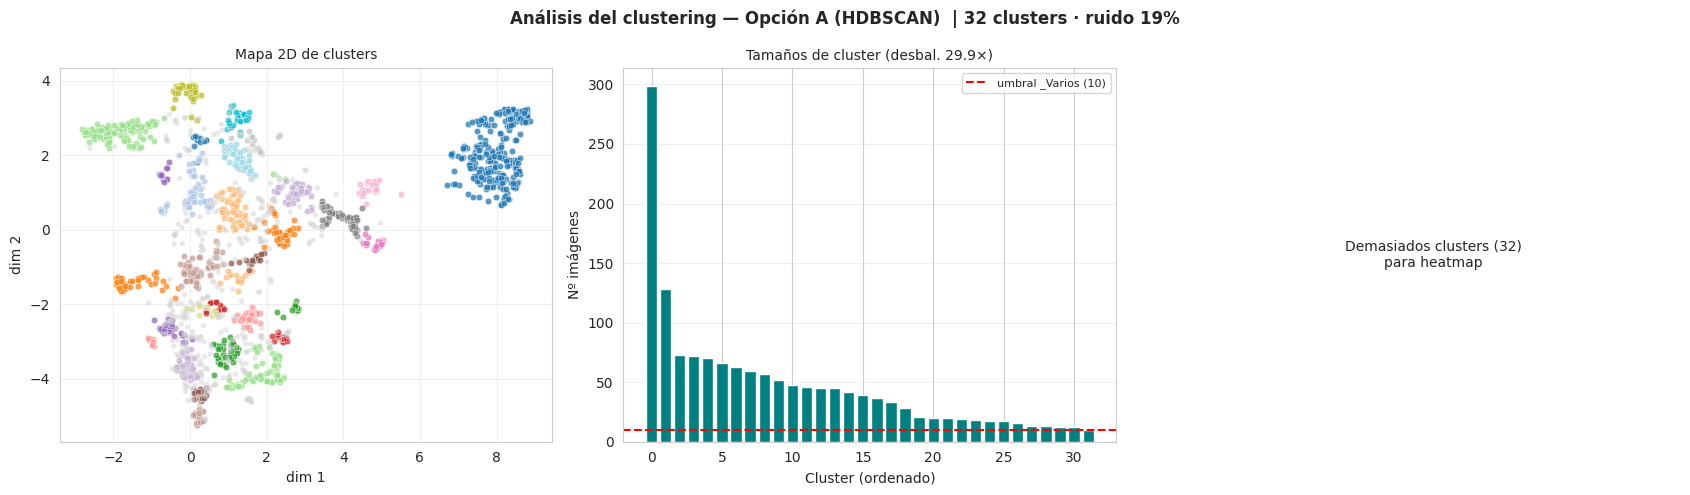


📝 INTERPRETACIÓN:
   ✅ Silhouette excelente (0.67): clusters bien separados.
   ✅ Nivel de ruido saludable (19%): HDBSCAN filtra outliers correctamente.
   ✅ Clustering estable (ARI=0.78): apto para uso incremental.
   ⚠️  Gran desbalance (×30): probable cluster "basura" con muchos outliers.
   🎯 HDBSCAN: detecta k automáticamente y etiqueta ruido — mejor fit para fotografía doméstica.
   💾 Resultados guardados en /content/drive/MyDrive/TFM/Clustering/analysis_logs/Cluster Analysis/sceneC_faceA_dimredA_clusterA.json


In [ ]:
# Usa: clusterer, new_cluster_labels, pool_indices, pool_labels,
#      new_embeddings_umap, new_embeddings_2d, new_clusters_found.

# ── Detectar la opción ejecutada ────────────────────────────────────
if clusterer is None:
    analysis_option_11 = '?'
    _cluster_cls = 'Sin clusterer'
else:
    _name = type(clusterer).__name__
    if 'HDBSCAN' in _name:
        analysis_option_11 = 'A'
        _cluster_cls = 'HDBSCAN'
    elif 'KMeans' in _name:
        analysis_option_11 = 'B'
        _cluster_cls = 'KMeans'
    elif 'Gaussian' in _name:
        analysis_option_11 = 'C'
        _cluster_cls = 'GaussianMixture'
    else:
        analysis_option_11 = '?'
        _cluster_cls = _name

print(f'🔬 Evaluación + análisis del clustering — OPCIÓN {analysis_option_11} ({_cluster_cls})')
print('─' * 70)

if len(pool_indices) >= CONFIG['METRIC_MIN_SAMPLES'] and new_clusters_found >= 2:
    _pool_embs = new_embeddings_umap[pool_indices]
    _pool_lbls = np.asarray(pool_labels)
    _valid_m   = _pool_lbls != -1

    # ── Métricas internas clásicas ─────────────────────────────────────
    analysis_sil = float('nan')
    analysis_dbi_val = float('nan')
    analysis_ch  = float('nan')
    analysis_dbcv = None

    if _valid_m.sum() >= 4:
        # Sub-muestreo si hay demasiados puntos. Silhouette consume memoria;
        # limitamos a EVAL_SAMPLE_SIZE para evitar problemas con datasets grandes.
        _sample_n = min(CONFIG['EVAL_SAMPLE_SIZE'], int(_valid_m.sum()))
        _smp = np.random.RandomState(SEED).choice(
            np.where(_valid_m)[0], _sample_n, replace=False,
        )
        _ve = _pool_embs[_smp]
        _vl = _pool_lbls[_smp]

        analysis_sil     = float(silhouette_score(_ve, _vl))
        analysis_dbi_val = float(davies_bouldin_score(_ve, _vl))
        analysis_ch      = float(calinski_harabasz_score(_ve, _vl))

        print('━' * 64)
        print('   📊 MÉTRICAS DE CALIDAD DEL CLUSTERING')
        print('━' * 64)
        print(f'{"📈 Silhouette Score":<29}: {analysis_sil:+.4f}  (↑ mejor, máx=1.0)')
        if   analysis_sil > 0.5: _interp = '✅ Clustering de alta calidad'
        elif analysis_sil > 0.2: _interp = '⚠️  Clustering aceptable'
        else:                    _interp = '❌ Clustering débil'
        print(f'   → {_interp}')
        print(f'{"📉 Davies-Bouldin Index":<29}: {analysis_dbi_val:.4f}  (↓ mejor)')
        print(f'{"📊 Calinski-Harabasz Score":<29}: {analysis_ch:.2f}  (↑ mejor)')

        # DBCV: solo si el clusterer es HDBSCAN
        if hasattr(clusterer, 'relative_validity_'):
            analysis_dbcv = float(clusterer.relative_validity_)
            print(f'{"🎯 DBCV (HDBSCAN)":<29}: {analysis_dbcv:+.4f}  (↑ mejor)')

    # ── Distribución de tamaños de cluster ─────────────────────────────
    _uniq, _cnts = np.unique(_pool_lbls[_pool_lbls != -1], return_counts=True)
    if len(_cnts) > 0:
        analysis_size_max  = int(_cnts.max())
        analysis_size_min  = int(_cnts.min())
        analysis_size_mean = float(_cnts.mean())
        analysis_size_imbalance = float(_cnts.max() / _cnts.min()) if _cnts.min() > 0 else float('inf')
        print(f'\n{"📦 Tamaños clusters (max/min)":<29}: {analysis_size_max} / {analysis_size_min} '
              f'(desbalance={analysis_size_imbalance:.1f}×)')
        print(f'{"    Tamaño promedio":<30}: {analysis_size_mean:.1f} fotos')
    else:
        analysis_size_max = analysis_size_min = 0
        analysis_size_mean = 0.0
        analysis_size_imbalance = float('nan')

    # ── Porcentaje de ruido (relevante para HDBSCAN) ───────────────────
    analysis_noise_pct = float((_pool_lbls == -1).sum() / len(_pool_lbls))
    print(f'{"🗑 Ruido (% del pool)":<29}: {100*analysis_noise_pct:.1f}% '
          f'({(_pool_lbls == -1).sum()} archivos)')

    # ── Estabilidad por bootstrap (ARI sobre subsample 80%) ────────────
    # Si el clustering no es estable, añadir nuevas fotos podría reorganizar
    # las carpetas — es el diagnóstico CORRECTO de "generalización" para
    # clustering no supervisado.
    analysis_stability_ari = float('nan')
    if len(_pool_embs) >= 20:
        _rng = np.random.RandomState(123)
        _sub = _rng.choice(len(_pool_embs), int(0.8 * len(_pool_embs)), replace=False)
        try:
            if analysis_option_11 == 'A':
                _c2 = hdbscan.HDBSCAN(
                    min_cluster_size=clusterer.min_cluster_size,
                    min_samples=clusterer.min_samples,
                    metric='euclidean',
                ).fit(_pool_embs[_sub])
                _lbl2 = _c2.labels_
            elif analysis_option_11 == 'B':
                _c2 = KMeans(n_clusters=clusterer.n_clusters,
                             n_init=5, random_state=123).fit(_pool_embs[_sub])
                _lbl2 = _c2.labels_
            elif analysis_option_11 == 'C':
                _c2 = GaussianMixture(n_components=clusterer.n_components,
                                      covariance_type='diag',
                                      random_state=123).fit(_pool_embs[_sub])
                _lbl2 = _c2.predict(_pool_embs[_sub])
            else:
                _lbl2 = None

            if _lbl2 is not None:
                # ARI entre la etiqueta original (restringida al sub) y la nueva
                analysis_stability_ari = float(adjusted_rand_score(_pool_lbls[_sub], _lbl2))
                print(f'{"🔁 Estabilidad ARI (bootstrap)":<29}: {analysis_stability_ari:+.4f} '
                      '(↑ mejor; >0.7 excelente)')
        except Exception as _e:
            print(f'⚠️  No se pudo medir estabilidad: {_e}')

    # ── Separación inter-cluster (coseno entre centroides) ─────────────
    analysis_inter_sep = float('nan')
    _sim = None
    if len(_uniq) >= 2:
        _centroids = np.stack([
            _pool_embs[_pool_lbls == lbl].mean(axis=0) for lbl in _uniq
        ])
        _cn = normalize(_centroids, norm='l2')
        _sim = _cn @ _cn.T
        _msk = ~np.eye(len(_uniq), dtype=bool)
        analysis_inter_sep = float(1.0 - _sim[_msk].mean())
        print(f'{"🔀 Separación inter-cluster":<29}: {analysis_inter_sep:.4f} '
              '(dist. coseno ↑ mejor)')

    # ── Gráficos diagnósticos ──────────────────────────────────────────
    _fig, _axes = plt.subplots(1, 3, figsize=(17, 5))
    _fig.suptitle(
        f'Análisis del clustering — Opción {analysis_option_11} ({_cluster_cls})  '
        f'| {len(_uniq)} clusters · ruido {100*analysis_noise_pct:.0f}%',
        fontsize=12, fontweight='bold',
    )

    # (a) Mapa 2D con clusters coloreados
    _pool_2d = new_embeddings_2d[pool_indices] if len(new_embeddings_2d) else _pool_embs[:, :2]
    _cmap = plt.get_cmap('tab20')
    for i, lbl in enumerate(_uniq):
        _m = _pool_lbls == lbl
        _axes[0].scatter(_pool_2d[_m, 0], _pool_2d[_m, 1],
                         color=_cmap(i % 20), s=22, alpha=0.75,
                         edgecolors='white', linewidths=0.4,
                         label=f'C{lbl} ({_m.sum()})')
    # Ruido en gris
    _noise_m = _pool_lbls == -1
    if _noise_m.any():
        _axes[0].scatter(_pool_2d[_noise_m, 0], _pool_2d[_noise_m, 1],
                         color='lightgray', s=15, alpha=0.5,
                         edgecolors='none', label=f'Ruido ({_noise_m.sum()})')
    _axes[0].set_title('Mapa 2D de clusters', fontsize=10)
    _axes[0].set_xlabel('dim 1'); _axes[0].set_ylabel('dim 2')
    if len(_uniq) <= 10:
        _axes[0].legend(fontsize=7, loc='best', framealpha=0.9)
    _axes[0].grid(alpha=0.3)

    # (b) Distribución de tamaños
    if len(_cnts) > 0:
        _order = np.argsort(-_cnts)
        _axes[1].bar(range(len(_cnts)), _cnts[_order],
                     color='teal', edgecolor='white')
        _axes[1].axhline(CONFIG.get('MIN_ELEMENTS_PER_FOLDER', 3),
                         color='red', linestyle='--',
                         label=f'umbral _Varios ({CONFIG.get("MIN_ELEMENTS_PER_FOLDER",3)})')
        _axes[1].set_title(f'Tamaños de cluster (desbal. {analysis_size_imbalance:.1f}×)',
                           fontsize=10)
        _axes[1].set_xlabel('Cluster (ordenado)'); _axes[1].set_ylabel('Nº imágenes')
        _axes[1].legend(fontsize=8); _axes[1].grid(alpha=0.3, axis='y')

    # (c) Heatmap de distancia coseno entre centroides
    if _sim is not None and len(_uniq) >= 2 and len(_uniq) <= 30:
        _dmat = 1.0 - _sim
        _im = _axes[2].imshow(_dmat, cmap='viridis', vmin=0, vmax=_dmat.max())
        _axes[2].set_title('Distancias coseno entre centroides\n(↑ brillo = más separados)',
                           fontsize=10)
        _axes[2].set_xlabel('Cluster'); _axes[2].set_ylabel('Cluster')
        plt.colorbar(_im, ax=_axes[2], fraction=0.046)
    else:
        _axes[2].text(0.5, 0.5, f'Demasiados clusters ({len(_uniq)})\npara heatmap',
                      ha='center', va='center', transform=_axes[2].transAxes)
        _axes[2].axis('off')

    plt.tight_layout()
    _clustering_plot_path = os.path.join(analysis_logger._section_folder('clustering'), f'clustering_{analysis_option_11}_diag.png')
    plt.savefig(_clustering_plot_path, dpi=120, bbox_inches='tight')
    plt.show()

    # ── Conclusiones ──────────────────────────────────────────────────────
    print('\n📝 INTERPRETACIÓN:')
    _conclusions_11 = []
    if not np.isnan(analysis_sil):
        if analysis_sil > 0.5:
            _conclusions_11.append(f'✅ Silhouette excelente ({analysis_sil:.2f}): clusters bien separados.')
        elif analysis_sil > 0.25:
            _conclusions_11.append(f'⚠️  Silhouette aceptable ({analysis_sil:.2f}): estructura detectada pero con solapamiento.')
        else:
            _conclusions_11.append(f'❌ Silhouette bajo ({analysis_sil:.2f}): clusters mal definidos.')

    if analysis_noise_pct > 0.4:
        _conclusions_11.append(f'⚠️  Ruido muy alto ({100*analysis_noise_pct:.0f}%): bajar MIN_CLUSTER_SIZE o aumentar muestras.')
    elif 0.05 <= analysis_noise_pct <= 0.3:
        _conclusions_11.append(f'✅ Nivel de ruido saludable ({100*analysis_noise_pct:.0f}%): HDBSCAN filtra outliers correctamente.')

    if not np.isnan(analysis_stability_ari):
        if analysis_stability_ari > 0.7:
            _conclusions_11.append(f'✅ Clustering estable (ARI={analysis_stability_ari:.2f}): apto para uso incremental.')
        elif analysis_stability_ari > 0.5:
            _conclusions_11.append(f'⚠️  Estabilidad moderada (ARI={analysis_stability_ari:.2f}): ajustar parámetros antes de producción.')
        else:
            _conclusions_11.append(f'❌ Clustering inestable (ARI={analysis_stability_ari:.2f}): no recomendable en modo incremental.')

    if analysis_size_imbalance > 10 and not np.isinf(analysis_size_imbalance):
        _conclusions_11.append(f'⚠️  Gran desbalance (×{analysis_size_imbalance:.0f}): probable cluster "basura" con muchos outliers.')

    if analysis_dbcv is not None and analysis_dbcv > 0.4:
        _conclusions_11.append(f'✅ DBCV={analysis_dbcv:.2f}: validación por densidad satisfactoria.')

    if analysis_option_11 == 'A':
        _conclusions_11.append('🎯 HDBSCAN: detecta k automáticamente y etiqueta ruido — mejor fit para fotografía doméstica.')
    elif analysis_option_11 == 'B':
        _conclusions_11.append('⚡ KMeans: rápido y determinista, pero impone k y clusters esféricos.')
    elif analysis_option_11 == 'C':
        _conclusions_11.append('📐 GMM: flexibilidad gaussiana con selección BIC.')

    for _c in _conclusions_11:
        print(f'   {_c}')

    # ── Persistencia ──────────────────────────────────────────────────────
    analysis_logger.save('clustering', f'scene{analysis_option_6[0]}_face{analysis_option_7}_dimred{analysis_option_9}_cluster{analysis_option_11}', {
        'scene_class'       : analysis_option_6[1],
        'face_class'        : _face_class,
        'reduction_class'   : analysis_option_9_name,
        'algorithm'         : _cluster_cls,
        'n_clusters'        : int(len(_uniq)),
        'noise_pct'         : float(analysis_noise_pct),
        'silhouette'        : float(analysis_sil) if not np.isnan(analysis_sil) else None,
        'davies_bouldin'    : float(analysis_dbi_val) if not np.isnan(analysis_dbi_val) else None,
        'calinski_harabasz' : float(analysis_ch) if not np.isnan(analysis_ch) else None,
        'dbcv'              : analysis_dbcv,
        'stability_ari'     : float(analysis_stability_ari) if not np.isnan(analysis_stability_ari) else None,
        'size_imbalance'    : float(analysis_size_imbalance) if not np.isinf(analysis_size_imbalance) else None,
        'size_min'          : int(analysis_size_min),
        'size_max'          : int(analysis_size_max),
        'inter_cluster_sep' : float(analysis_inter_sep) if not np.isnan(analysis_inter_sep) else None,
        'plot_path'         : _clustering_plot_path,
        'conclusions'       : _conclusions_11,
    })
else:
    print('⚠️  Clustering insuficiente para análisis (pool pequeño o sin clusters).')

---
## Celda 13 — Etiquetado interactivo (solo clusters NUEVOS)


### Objetivo
Permitir al usuario asignar nombres legibles a los clusters detectados en esta ejecución. Los clusters ya etiquetados en sesiones anteriores conservan su nombre automáticamente. Los caracteres no válidos (`/ \ : * ? " < > |`) en nombres de carpeta se sustituyen automáticamente por un espacio.


### Asignar nombres de clústers con ipywidgets

Para cada cluster nuevo muestra imágenes de muestra y un campo de texto.
Pulsa **"✅ Confirmar todos los nombres"** cuando hayas revisado todos.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELDA 13 — Asignar nombres de clústers (ipywidgets)
# ════════════════════════════════════════════════════════════════════════════

import re


def sanitize_folder_name(name: str) -> str:
    """
    Sustituye cada carácter no válido en nombres de carpeta por un espacio.
    Los espacios múltiples consecutivos se colapsan en uno y se eliminan
    los espacios iniciales y finales.
    """
    INVALID_CHARS = set('/\\:*?"<>|')
    sanitized = ''.join(' ' if c in INVALID_CHARS else c for c in name)
    sanitized = re.sub(r' {2,}', ' ', sanitized).strip()
    return sanitized if sanitized else 'Cluster_sin_nombre'

def show_cluster_samples(indices_in_new, label, cluster_name='', n_samples=8):
    """
    Muestra una fila de imágenes de muestra de un cluster específico.

    Parameters
    ----------
    indices_in_new : list  Índices dentro de new_valid_files para este cluster.
    label          : int   ID numérico del cluster (para el título).
    cluster_name   : str   Nombre del cluster (vacío si aún no está etiquetado).
    n_samples      : int   Número máximo de imágenes a mostrar.
    """
    sample_idx = np.random.choice(
        indices_in_new, min(n_samples, len(indices_in_new)), replace=False,
    )
    n_cols = len(sample_idx)
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3.5))
    if n_cols == 1:
        axes = [axes]
    title = f'Cluster {label}  ({len(indices_in_new)} imgs)'
    if cluster_name:
        title += f' — "{cluster_name}"'
    fig.suptitle(title, fontsize=11)
    for ax, idx in zip(axes, sample_idx):
        img = load_image(new_valid_files[idx])
        if img:
            ax.imshow(img)
        ax.set_title(new_valid_files[idx].name[:18], fontsize=6)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── Identificar clusters heredados vs. nuevos ─────────────────────────────────
known_labels   = set(session.cluster_names.keys()) if not IS_FIRST_RUN else set()
all_new_labels = [l for l in sorted(set(new_cluster_labels)) if l != -1]
new_label_ids  = [l for l in all_new_labels if l not in known_labels]

# Ordenamos por tamaño (mayores primero) y limitamos
new_label_ids = sorted(
    new_label_ids,
    key=lambda l: (new_cluster_labels == l).sum(),
    reverse=True,
)[:CONFIG['MAX_CLUSTERS_TO_LABEL']]

# Partimos del diccionario heredado
cluster_names_combined = dict(session.cluster_names)

print('=' * 60)
print('  ETIQUETADO INTERACTIVO')
if not IS_FIRST_RUN and known_labels:
    print(f'  Clusters heredados: {len(known_labels)}')
    for cid in sorted(known_labels):
        cnt   = (new_cluster_labels == cid).sum()
        cname = session.cluster_names.get(cid, f'Cluster_{cid}')
        tag   = f'+{cnt} nuevas' if cnt > 0 else 'sin cambios'
        print(f'    Cluster {cid:3d} → "{cname}" ({tag})')
print()
if new_label_ids:
    print(f'  Clusters NUEVOS a etiquetar: {len(new_label_ids)}')
else:
    print('  Sin clusters nuevos. Continúa con la celda 14.')
print('=' * 60)
print()


# ════════════════════════════════════════════════════════════════════════════
# OPCIÓN 13A — Etiquetado secuencial con ipywidgets
# ════════════════════════════════════════════════════════════════════════════
# Para cada cluster nuevo muestra imágenes de muestra y un campo de texto.
# Pulsa "✅ Confirmar todos los nombres" cuando hayas revisado todos.
# ════════════════════════════════════════════════════════════════════════════

if new_label_ids:
    text_widgets = {}
    for label in new_label_ids:
        indices_this = np.where(new_cluster_labels == label)[0].tolist()
        plt.close('all')
        show_cluster_samples(indices_this, label, n_samples=CONFIG['PREVIEW_SAMPLES'])
        txt = widgets.Text(
            value=f'Cluster_{label}',
            description=f'Cluster {label} ({(new_cluster_labels==label).sum()} imgs):',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px'),
        )
        text_widgets[label] = txt
        display(txt)

    confirm_btn_13a = widgets.Button(
        description='✅ Confirmar todos los nombres',
        button_style='success',
        layout=widgets.Layout(width='300px', margin='15px 0 0 0'),
    )
    output_area_13a = widgets.Output()

    def on_confirm_clicked_13a(b):
        """Lee widgets y asigna nombres saneados al pulsar confirmar."""
        with output_area_13a:
            clear_output()
            for label, txt in text_widgets.items():
                raw_name  = txt.value.strip() or f'Cluster_{label}'
                sanitized = sanitize_folder_name(raw_name)
                if sanitized != raw_name:
                    print(f'  ⚠️  Caracteres no válidos sustituidos en Cluster {label}:')
                    print(f'       Introducido : "{raw_name}"')
                    print(f'       Utilizado   : "{sanitized}"')
                cluster_names_combined[label] = sanitized
                print(f'  Cluster {label:3d} → "{sanitized}"')
            cluster_names_combined[-1] = '_sin_clasificar'
            print('\n✅ Nombres confirmados. Continúa con la celda 14.')

    confirm_btn_13a.on_click(on_confirm_clicked_13a)
    display(confirm_btn_13a, output_area_13a)
else:
    cluster_names_combined[-1] = '_sin_clasificar'
    print('Sin clusters nuevos. Continúa con la celda 14.')


---
## Celda 14 — Visualización: mapa de clusters

### Objetivo
Mostrar un scatter plot UMAP 2D coloreado por cluster. Los clusters nuevos se marcan con `★` y los heredados con `●`; el ruido aparece en gris semitransparente.

No muestro el output de esta celdda porque aparecen mis fotos personales. En el apartado sigueinte se puede ver la representación 2D de los clusteres generados tras asignar los nombres. En el vídeo explicativo se ve un ejemplo de asignación de nombres.

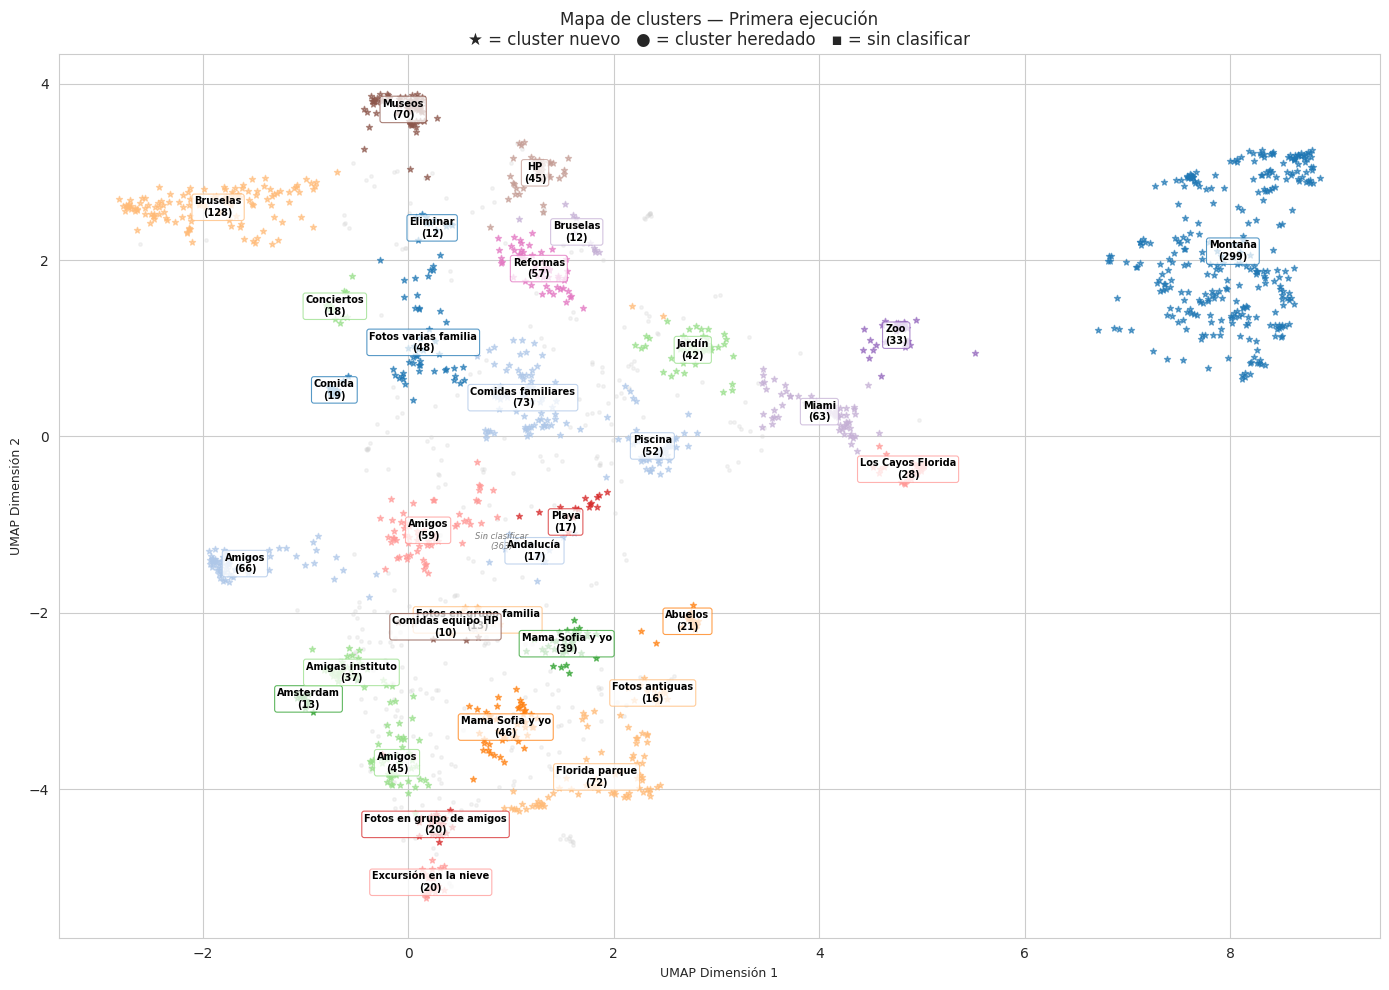

💾 Mapa guardado: /content/drive/MyDrive/TFM/Clustering/mapa_sesion_1.png


In [ ]:
if len(new_valid_files) > 0:
    fig, ax = plt.subplots(figsize=(14, 10))

    final_labels_2d  = new_cluster_labels
    unique_2d        = sorted(set(final_labels_2d))
    n_valid_clusters = len([l for l in unique_2d if l != -1])
    # plt.cm.get_cmap está deprecada en matplotlib reciente — usamos el helper actual.
    cmap             = plt.get_cmap('tab20', max(n_valid_clusters, 1))

    # ── Ruido: puntos grises semitransparentes ──────────────────────────────
    noise_mask = final_labels_2d == -1
    if noise_mask.any():
        ax.scatter(
            new_embeddings_2d[noise_mask, 0],
            new_embeddings_2d[noise_mask, 1],
            c='lightgray', s=6, alpha=0.25, zorder=1,
        )

    # ── Un color por cluster ────────────────────────────────────────────────
    color_idx = 0
    for lbl in [l for l in unique_2d if l != -1]:
        mask   = final_labels_2d == lbl
        color  = cmap(color_idx % 20)
        color_idx += 1
        name   = cluster_names_combined.get(lbl, f'Cluster_{lbl}')
        count  = mask.sum()
        is_new = lbl not in known_labels

        # Marcador: estrella = cluster nuevo, círculo = heredado
        ax.scatter(
            new_embeddings_2d[mask, 0],
            new_embeddings_2d[mask, 1],
            c=[color], s=20, alpha=0.65,
            marker='*' if is_new else 'o',
            zorder=2,
        )

        # ── ETIQUETA EN EL CENTROIDE ────────────────────────────────────────
        # Calculamos el centroide geométrico del cluster en 2D
        cx = new_embeddings_2d[mask, 0].mean()
        cy = new_embeddings_2d[mask, 1].mean()

        label_text = f'{name}\n({count})'
        ax.text(
            cx, cy, label_text,
            fontsize=7,
            color='black',
            ha='center', va='center',
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                alpha=0.75,
                edgecolor=color,
                linewidth=0.8,
            ),
            zorder=3,    # Por encima de los puntos
        )

    # ── Anotación de ruido  ─────────────────────────────────────────────────
    if noise_mask.any():
        cx_noise = new_embeddings_2d[noise_mask, 0].mean()
        cy_noise = new_embeddings_2d[noise_mask, 1].mean()
        ax.text(
            cx_noise, cy_noise,
            f'Sin clasificar\n({noise_mask.sum()})',
            fontsize=6, color='gray',
            ha='center', va='center',
            style='italic',
        )

    # ── Título y ejes ───────────────────────────────────────────────────────
    run_label = 'Primera ejecución' if IS_FIRST_RUN else f'Ejecución nº {session.run_count + 1}'
    ax.set_title(
        f'Mapa de clusters — {run_label}\n'
        f'★ = cluster nuevo   ● = cluster heredado   ▪ = sin clasificar',
        fontsize=12,
    )
    ax.set_xlabel('UMAP Dimensión 1', fontsize=9)
    ax.set_ylabel('UMAP Dimensión 2', fontsize=9)

    plt.tight_layout()
    map_path = os.path.join(CONFIG['OUTPUT_DIR'], f'mapa_sesion_{session.run_count + 1}.png')
    plt.savefig(map_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Mapa guardado: {map_path}')

---
## Celda 15 — Exportar CSV y actualizar ChromaDB

### Objetivo
Persistir los resultados en dos formatos:

- **CSV acumulado** — registro tabular con la información de cada archivo procesado (ruta, nombre, cluster, coordenadas UMAP...). Si ya existe un CSV de sesiones anteriores, añade las filas nuevas y elimina duplicados por ruta.
- **ChromaDB** — base de datos vectorial local. Inserta los embeddings UMAP de los archivos nuevos. Permite buscar fotos similares en milisegundos sin recalcular embeddings. Los embeddings y metadatos quedan persistidos en disco.

El CSV es legible y editable por el usuario; ChromaDB habilita búsqueda semántica futura ("encuentra fotos parecidas a esta") sin consumir mucho espacio.

In [ ]:
if len(new_valid_files) > 0:
    # ── DataFrame de los archivos procesados en esta sesión ──────────────────
    results_new = pd.DataFrame({
        'file_path'    : [str(p) for p in new_valid_files],
        'file_name'    : [p.name for p in new_valid_files],
        'extension'    : [p.suffix.lower() for p in new_valid_files],
        'cluster_id'   : new_cluster_labels,
        'cluster_name' : [cluster_names_combined.get(l, f'Cluster_{l}')
                          for l in new_cluster_labels],
        'has_face'     : new_has_face.tolist(),
        'umap_x'       : new_embeddings_2d[:, 0],
        'umap_y'       : new_embeddings_2d[:, 1],
        'session_run'  : session.run_count + 1,
        'auto_assigned': [int(l) in [int(k) for k in known_labels]
                          for l in new_cluster_labels],
    })

    # ── CSV acumulado incremental (elimina duplicados por ruta) ──────────────
    csv_path = os.path.join(CONFIG['OUTPUT_DIR'], 'clustering_resultados_completo.csv')
    if os.path.exists(csv_path):
        existing_df = pd.read_csv(csv_path, encoding='utf-8-sig')
        combined_df = pd.concat([existing_df, results_new], ignore_index=True)
        # Conservamos la versión más reciente de cada ruta (keep='last')
        combined_df.drop_duplicates(subset=['file_path'], keep='last', inplace=True)
        combined_df.reset_index(drop=True, inplace=True)
    else:
        combined_df = results_new

    combined_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f'💾 CSV actualizado: {len(combined_df)} filas totales → {csv_path}')

    # ── ChromaDB: base de datos vectorial local ──────────────────────────────
    try:
        chroma_client = chromadb.PersistentClient(path=CONFIG['CHROMA_DIR'])
        try:
            collection      = chroma_client.get_collection('photo_embeddings')
            existing_chroma = True
        except Exception:
            collection = chroma_client.create_collection(
                name='photo_embeddings',
                metadata={'hnsw:space': 'cosine'},
            )
            existing_chroma = False

        current_count = collection.count()

        # Insertamos en lotes de 500 para no saturar la memoria
        BATCH = 500
        for start in range(0, len(new_valid_files), BATCH):
            end        = min(start + BATCH, len(new_valid_files))
            batch_embs = new_embeddings_umap[start:end].tolist()
            batch_meta = [
                {
                    'file_path'   : str(new_valid_files[i]),
                    'file_name'   : new_valid_files[i].name,
                    'cluster_id'  : int(new_cluster_labels[i]),
                    'cluster_name': cluster_names_combined.get(int(new_cluster_labels[i]), '?'),
                    'session_run' : session.run_count + 1,
                }
                for i in range(start, end)
            ]
            batch_ids = [f'img_{current_count + start + j}' for j in range(end - start)]
            collection.add(embeddings=batch_embs, metadatas=batch_meta, ids=batch_ids)

        accion = 'actualizada' if existing_chroma else 'creada'
        print(f'💾 ChromaDB {accion}: {collection.count()} embeddings totales')
    except Exception as e:
        print(f'⚠️  ChromaDB no disponible: {e}')

    # ── Resumen por cluster ──────────────────────────────────────────────────
    print()
    summary = (
        results_new
        .groupby(['cluster_id', 'cluster_name'])
        .agg(total=('file_name', 'count'), con_cara=('has_face', 'sum'))
        .reset_index().sort_values('cluster_id')
    )
    summary['% caras'] = (summary['con_cara'] / summary['total'] * 100).round(1)
    print(summary[['cluster_id', 'cluster_name', 'total', '% caras']].to_string(index=False))

💾 CSV actualizado: 3746 filas totales → /content/drive/MyDrive/TFM/Clustering/clustering_resultados_completo.csv
💾 ChromaDB creada: 1873 embeddings totales

 cluster_id             cluster_name  total  % caras
         -1          _sin_clasificar    363     59.8
          0                  Montaña    299     13.4
          1                   Comida     19      0.0
          2                   Amigos     66    100.0
          3                Andalucía     17     11.8
          4                  Abuelos     21    100.0
          5                 Bruselas    128      9.4
          6   Fotos en grupo familia     13    100.0
          7          Mama Sofia y yo     39     94.9
          8               Conciertos     18     33.3
          9                   Jardín     42      0.0
         10                    Playa     17     29.4
         11                   Amigos     59      3.4
         12        Los Cayos Florida     28      3.6
         13                      Zoo     33     

---
## Celda 16 — Mover archivos nuevos a carpetas organizadas

### Objetivo
Mover las fotos nuevas a `fotos_organizadas/<nombre_sesión>/<cluster>/`,
agrupadas por cluster.

- Se pedirá un **nombre de sesión** (p. ej. `Fotos 2023`). Esto permite  ejecutar el pipeline en distintas colecciones y mantener los clusters separados aunque compartan nombres de carpeta.
- Clusters con menos de `MIN_ELEMENTS_PER_FOLDER` imágenes van a `_Varios/`.
- Si ya existe un archivo con el mismo nombre en destino, se añade el sufijo  `_runN` para evitar sobrescrituras.
- Los archivos se mueven: la carpeta original queda solo con los archivos que no han podido procesarse.


In [ ]:
if len(new_valid_files) > 0:

    # ── Nombre de la sesión (subcarpeta de organización) ──────────────────────
    # Permite separar colecciones distintas: 'Fotos 2023', 'Fotos 2024', etc.
    # Así dos sesiones pueden tener clusters con el mismo nombre sin conflicto.
    _raw_session = input(
        'Nombre de esta sesión de organización '
        '(p.ej. "Fotos 2023"). '
        'Pulsa Enter para usar el nombre automático: '
    ).strip()

    if not _raw_session:
        _session_folder = f'sesion_{session.run_count + 1}'
        print(f'ℹ️  Usando nombre automático: "{_session_folder}"')
    else:
        _session_folder = sanitize_folder_name(_raw_session)
        if _session_folder != _raw_session:
            print(f'⚠️  Caracteres no válidos sustituidos en el nombre de sesión:')
            print(f'   Introducido : "{_raw_session}"')
            print(f'   Utilizado   : "{_session_folder}"')

    COPY_DIR      = os.path.join(CONFIG['OUTPUT_DIR'], 'fotos_organizadas', _session_folder)
    MIN_ELEM      = CONFIG['MIN_ELEMENTS_PER_FOLDER']
    VARIOS_NAME   = CONFIG['VARIOS_FOLDER']
    moved_count   = 0
    skipped_count = 0
    varios_count  = 0

    # ── Pre-computamos el tamaño TOTAL de cada cluster (todas las sesiones) ──
    csv_path = os.path.join(CONFIG['OUTPUT_DIR'], 'clustering_resultados_completo.csv')
    if os.path.exists(csv_path):
        full_df       = pd.read_csv(csv_path, encoding='utf-8-sig')
        cluster_sizes = full_df.groupby('cluster_id')['file_path'].count().to_dict()
    else:
        cluster_sizes = Counter(new_cluster_labels.tolist())

    print(f'Moviendo {len(new_valid_files)} archivos NUEVOS...')
    print(f'Destino  : fotos_organizadas/{_session_folder}/')
    print(f'Umbral mínimo por carpeta: {MIN_ELEM} imágenes')
    print(f'Clusters pequeños → carpeta: {VARIOS_NAME}/')
    print()

    for _, row in tqdm(results_new.iterrows(), total=len(results_new), desc='Moviendo'):
        cluster_id   = row['cluster_id']
        cluster_name = row['cluster_name']

        # ── Lógica de carpeta destino ────────────────────────────────────────
        total_in_cluster = cluster_sizes.get(int(cluster_id), 0)

        if cluster_id == -1:
            # Ruido: siempre a _sin_clasificar/
            dest_folder = os.path.join(COPY_DIR, '_sin_clasificar')
        elif total_in_cluster < MIN_ELEM:
            # Cluster pequeño: centralizar en _Varios/ para evitar ruido
            dest_folder = os.path.join(COPY_DIR, VARIOS_NAME)
            varios_count += 1
        else:
            # Cluster grande: carpeta dedicada con el nombre asignado
            dest_folder = os.path.join(COPY_DIR, cluster_name)

        os.makedirs(dest_folder, exist_ok=True)

        # ── Nombre del archivo destino (evita sobreescritura) ────────────────
        dest_path = os.path.join(dest_folder, row['file_name'])
        if os.path.exists(dest_path):
            stem      = Path(row['file_name']).stem
            suffix    = Path(row['file_name']).suffix
            dest_path = os.path.join(dest_folder,
                                      f"{stem}_run{row['session_run']}{suffix}")

        # ── Mover el archivo (preserva metadatos, libera espacio en origen) ──
        # Los archivos que fallen permanecen en la carpeta original,
        # facilitando la identificación de los que no pudieron procesarse.
        try:
            shutil.move(row['file_path'], dest_path)
            moved_count += 1
        except Exception as _e:
            skipped_count += 1

    print(f'\n✅ Movidos                : {moved_count} archivos')
    print(f'📁 A {VARIOS_NAME}         : {varios_count} archivos')
    if skipped_count:
        print(f'⚠️  No movidos (error)    : {skipped_count} archivos '
              f'(permanecen en la carpeta original)')

    # ── Estado actual de todas las carpetas ──────────────────────────────────
    print()
    print(f'Carpetas creadas en fotos_organizadas/{_session_folder}/:')
    if os.path.exists(COPY_DIR):
        for folder_name in sorted(os.listdir(COPY_DIR)):
            folder_path = os.path.join(COPY_DIR, folder_name)
            if os.path.isdir(folder_path):
                n_files = len([f for f in os.listdir(folder_path)
                               if os.path.isfile(os.path.join(folder_path, f))])
                flag    = ' ← _Varios' if folder_name == VARIOS_NAME else ''
                print(f'  📁 {folder_name}/  ({n_files} archivos){flag}')


Nombre de esta sesión de organización (p.ej. "Fotos 2023"). Pulsa Enter para usar el nombre automático: Fotos Laura
Moviendo 1873 archivos NUEVOS...
Destino  : fotos_organizadas/Fotos Laura/
Umbral mínimo por carpeta: 10 imágenes
Clusters pequeños → carpeta: _Varios/



Moviendo:   0%|          | 0/1873 [00:00<?, ?it/s]


✅ Movidos                : 1873 archivos
📁 A _Varios         : 0 archivos

Carpetas creadas en fotos_organizadas/Fotos Laura/:
  📁 Abuelos/  (21 archivos)
  📁 Amigas instituto/  (37 archivos)
  📁 Amigos/  (170 archivos)
  📁 Amsterdam/  (13 archivos)
  📁 Andalucía/  (17 archivos)
  📁 Bruselas/  (140 archivos)
  📁 Comida/  (19 archivos)
  📁 Comidas equipo HP/  (10 archivos)
  📁 Comidas familiares/  (73 archivos)
  📁 Conciertos/  (18 archivos)
  📁 Eliminar/  (12 archivos)
  📁 Excursión en la nieve/  (20 archivos)
  📁 Florida parque/  (72 archivos)
  📁 Fotos antiguas/  (16 archivos)
  📁 Fotos en grupo de amigos/  (20 archivos)
  📁 Fotos en grupo familia/  (13 archivos)
  📁 Fotos varias familia/  (48 archivos)
  📁 HP/  (45 archivos)
  📁 Jardín/  (42 archivos)
  📁 Los Cayos Florida/  (28 archivos)
  📁 Mama Sofia y yo/  (85 archivos)
  📁 Miami/  (63 archivos)
  📁 Montaña/  (299 archivos)
  📁 Museos/  (70 archivos)
  📁 Piscina/  (52 archivos)
  📁 Playa/  (17 archivos)
  📁 Reformas/  (57 a

---
## Celda 17 — Guardar estado de sesión

### Objetivo
Persistir en disco el estado completo de la ejecución para que la próxima sesión pueda
continuar en modo incremental.

Persiste:

- La lista acumulada de todos los archivos procesados.
- Los nombres asignados a cada cluster.
- Los centroides recalculados con todos los datos de esta sesión.
- Los modelos PCA y UMAP ajustados.

### Información
- `session.save()` re-calcula los centroides con todas las etiquetas combinadas (heredadas + nuevas), no con un subconjunto. Esto evita derivas progresivas en clusters de larga vida.

In [ ]:
if len(new_valid_files) > 0:
    print('Guardando estado de sesión...')
    session.save(
        new_processed_files = new_valid_files,
        cluster_names       = cluster_names_combined,
        cluster_labels      = new_cluster_labels,
        embeddings_umap     = new_embeddings_umap,
        pca_model           = pca_model,
        umap_model          = umap_model,
    )
    print()
    print(f'📊 Resumen de la sesión nº {session.run_count}:')
    print(f'   Archivos procesados esta sesión : {len(new_valid_files)}')
    print(f'   Archivos totales procesados     : {len(session.processed_files)}')
    print(f'   Clusters activos                : {len([k for k in cluster_names_combined if k != -1])}')
    print()
    print('Clusters en la sesión:')
    for lbl, name in sorted(cluster_names_combined.items()):
        if lbl == -1:
            continue
        cnt = (new_cluster_labels == lbl).sum()
        tag = '[heredado]' if lbl in known_labels else '[nuevo esta sesión]'
        print(f'  Cluster {lbl:3d} → "{name}"  ({cnt} archivos nuevos)  {tag}')
else:
    print('No se procesaron archivos nuevos. El estado no necesita actualizarse.')

Guardando estado de sesión...
✅ Sesión guardada (1873 archivos procesados en total)

📊 Resumen de la sesión nº 1:
   Archivos procesados esta sesión : 1873
   Archivos totales procesados     : 1873
   Clusters activos                : 32

Clusters en la sesión:
  Cluster   0 → "Montaña"  (299 archivos nuevos)  [nuevo esta sesión]
  Cluster   1 → "Comida"  (19 archivos nuevos)  [nuevo esta sesión]
  Cluster   2 → "Amigos"  (66 archivos nuevos)  [nuevo esta sesión]
  Cluster   3 → "Andalucía"  (17 archivos nuevos)  [nuevo esta sesión]
  Cluster   4 → "Abuelos"  (21 archivos nuevos)  [nuevo esta sesión]
  Cluster   5 → "Bruselas"  (128 archivos nuevos)  [nuevo esta sesión]
  Cluster   6 → "Fotos en grupo familia"  (13 archivos nuevos)  [nuevo esta sesión]
  Cluster   7 → "Mama Sofia y yo"  (39 archivos nuevos)  [nuevo esta sesión]
  Cluster   8 → "Conciertos"  (18 archivos nuevos)  [nuevo esta sesión]
  Cluster   9 → "Jardín"  (42 archivos nuevos)  [nuevo esta sesión]
  Cluster  10 → "Pla